# Begin

In [1]:
from pathlib import Path
import os

import sys
sys.path.append("../reqlocal")
from reqlocal.constants import C, H, K_B, M_ELEC, M_SUN, EC, EV, DAY
from reqlocal import DATA_SR_DIR, DATA_HE_DIR

import numpy as np
import numpy.typing as npt
import numpy.ma as ma
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Polygon
from matplotlib.legend_handler import HandlerTuple
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd

plt.rcParams.update({
    # フォント
    "font.size": 30,
    "xtick.labelsize": 26, 
    "ytick.labelsize": 26,

    # 軸の線
    "axes.linewidth": 2,
    "axes.labelpad": 10, 

    # 軸の向き
    "xtick.direction": "in",  
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,  

    # 主目盛り (major ticks)
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.major.size": 13,
    "ytick.major.size": 13,
    "xtick.major.pad": 7,
    "ytick.major.pad": 7,

    # 補助目盛り (minor ticks)
    "xtick.minor.width": 1,
    "ytick.minor.width": 1,
    "xtick.minor.size": 6, 
    "ytick.minor.size": 6,
})

In [2]:
# phase: (t_expl, temp, vel_ph_c)
fitting_info_KC26 = {
    "1.43":(1.43, 4.5e+3, 0.21),
    "2.42":(2.42, 3.2e+3, 0.19),
    "3.41":(3.41, 2.8e+3, 0.17),
    "4.40":(4.40, 2.6e+3, 0.14)
}

In [3]:
def calc_tau_l_HeI(term_l: str, term_u: str, nd_l: npt.NDArray[np.float64], nd_u: npt.NDArray[np.float64], t_expl: float):
    fname_rbbt = Path(DATA_HE_DIR, "He_I_rbbt_params.csv")
    df_rbbt = pd.read_csv(fname_rbbt, comment='#')

    fname_state = Path(DATA_HE_DIR, "He_state_id.csv")
    df_state = pd.read_csv(fname_state, comment='#')

    _, _, E_ul, _, f_lu, _ = df_rbbt.query("lower==@term_l & upper==@term_u").to_numpy()[0]
    g_l = df_state.query("term == @term_l")["g"].to_numpy()[0]
    g_u = df_state.query("term == @term_u")["g"].to_numpy()[0]

    tau_l = (np.pi*EC*EC*H/M_ELEC) * f_lu * (nd_l - (g_l/g_u) * nd_u) * t_expl / (E_ul*EV)

    return tau_l

In [4]:
def calc_tau_l_SrII(idx_l: int, idx_u: int, nd_II: npt.NDArray[np.float64], t_expl: float, tem_e: float, w_geo: float=0.5):
    fname_rbbt = Path(DATA_SR_DIR, "Sr_II_lines.csv")
    df_rbbt = pd.read_csv(fname_rbbt, comment='#')

    fname_state = Path(DATA_SR_DIR, "Sr_II_state_id.csv")
    df_state = pd.read_csv(fname_state, comment='#')

    frac_exc_seq = np.empty((len(df_state)))
    g_seq = np.empty((len(df_state)))

    neb_cor_seq = np.array([1.0, 1.0, 1.0, w_geo, w_geo])

    for idx_state, _, _, g, eng_eV in df_state.itertuples():
        frac_exc_seq[idx_state] = g * np.exp(-eng_eV*EV/(K_B*tem_e))
        g_seq[idx_state] = g

    frac_exc_seq *= neb_cor_seq
    frac_exc_seq /= frac_exc_seq.sum()

    _, _, E_ul, _, f_lu, _ = df_rbbt.query("lower==@idx_l & upper==@idx_u").to_numpy()[0]
    
    nd_l = nd_II * frac_exc_seq[idx_l-1]
    nd_u = nd_II * frac_exc_seq[idx_u-1]

    tau_l = (np.pi*EC*EC*H/M_ELEC) * f_lu * (nd_l - (g_seq[idx_l-1]/g_seq[idx_u-1]) * nd_u) * t_expl / (E_ul*EV)

    return tau_l

In [ ]:
res_dir_KC26 = Path("runs/res_kn17gfo_KC26")
each_res_list_KC26_LTE = [
    f for f in os.listdir(res_dir_KC26) if f.split("_")[-1] == "Sr-LTE"
]
each_res_list_KC26_LTE.sort()
print(each_res_list_KC26_LTE)

each_res_list_KC26_NLTE = [
    f for f in os.listdir(res_dir_KC26) if f.split("_")[-1] == "Sr-NLTE"
]
each_res_list_KC26_NLTE.sort()
print(each_res_list_KC26_NLTE)


['1.43d_4.50e+03K_4.50e+03K_5.18e-15gpcc_1.00drr_1.00_0.50_Sr-LTE', '2.42d_3.20e+03K_3.20e+03K_1.44e-15gpcc_1.00drr_1.00_0.50_Sr-LTE', '3.41d_2.80e+03K_2.80e+03K_7.21e-16gpcc_1.00drr_1.00_0.50_Sr-LTE', '4.40d_2.60e+03K_2.60e+03K_6.01e-16gpcc_1.00drr_1.00_0.50_Sr-LTE']
['1.43d_4.50e+03K_4.50e+03K_5.18e-15gpcc_1.00drr_1.00_0.50_Sr-NLTE', '2.42d_3.20e+03K_3.20e+03K_1.44e-15gpcc_1.00drr_1.00_0.50_Sr-NLTE', '3.41d_2.80e+03K_2.80e+03K_7.21e-16gpcc_1.00drr_1.00_0.50_Sr-NLTE', '4.40d_2.60e+03K_2.60e+03K_6.01e-16gpcc_1.00drr_1.00_0.50_Sr-NLTE']


# plot tau

## Sr LTE

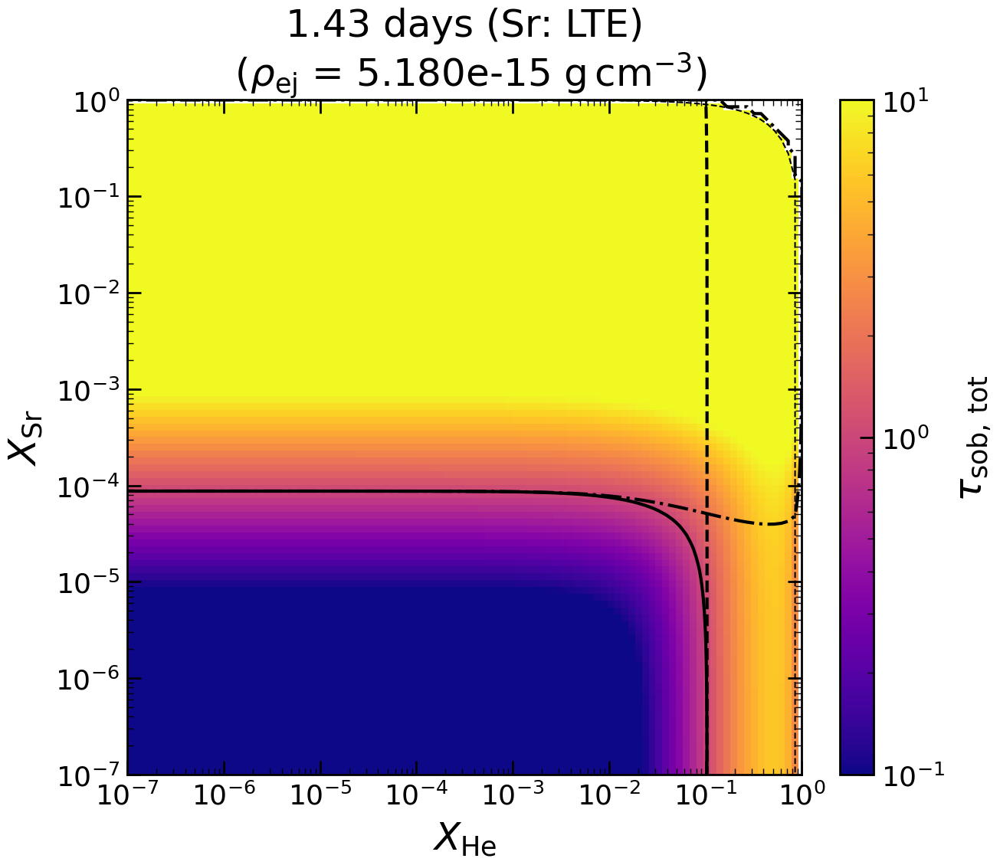

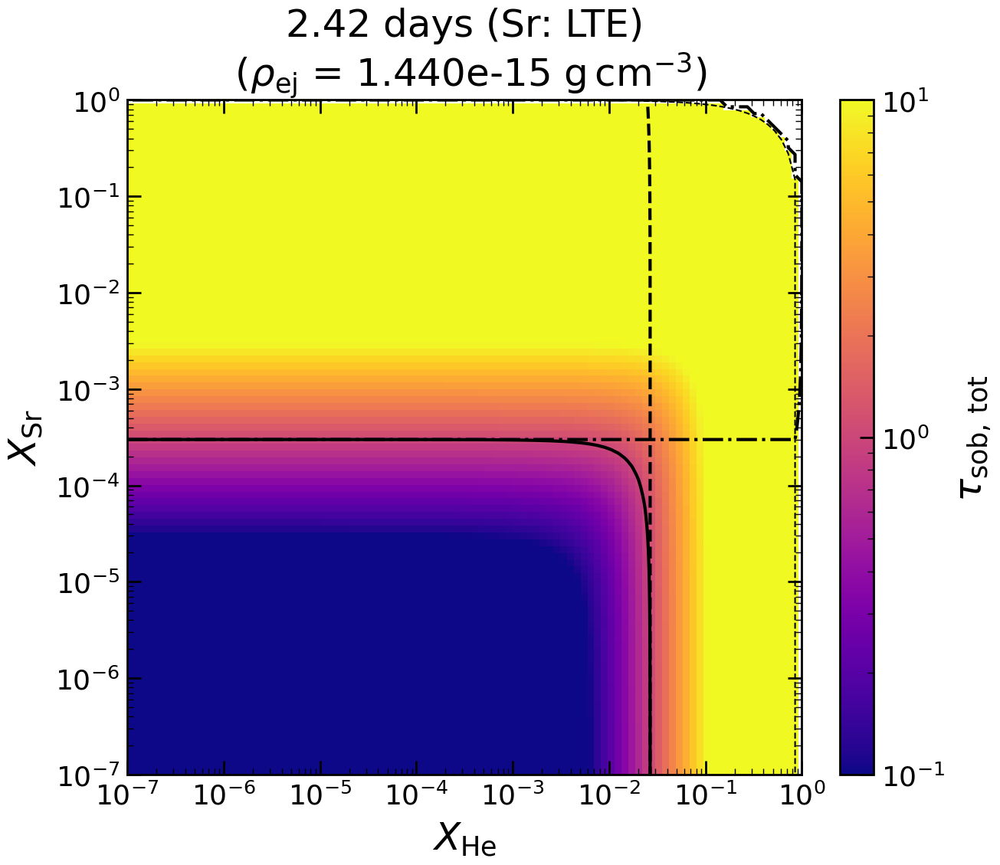

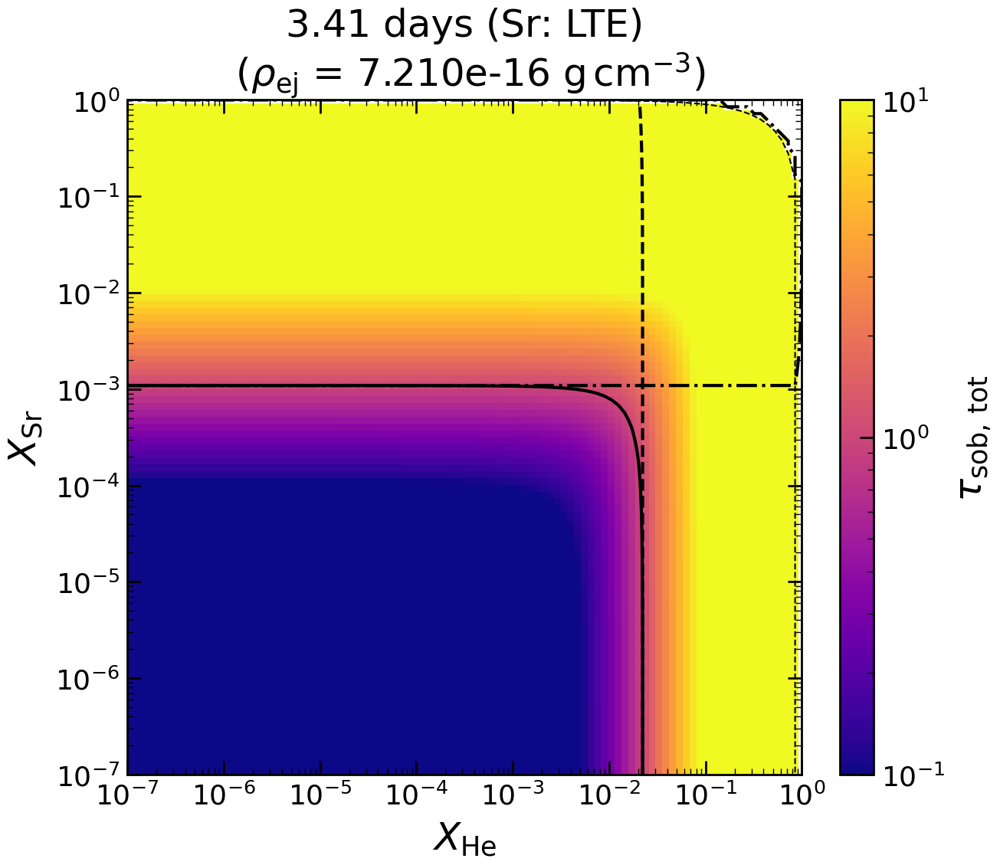

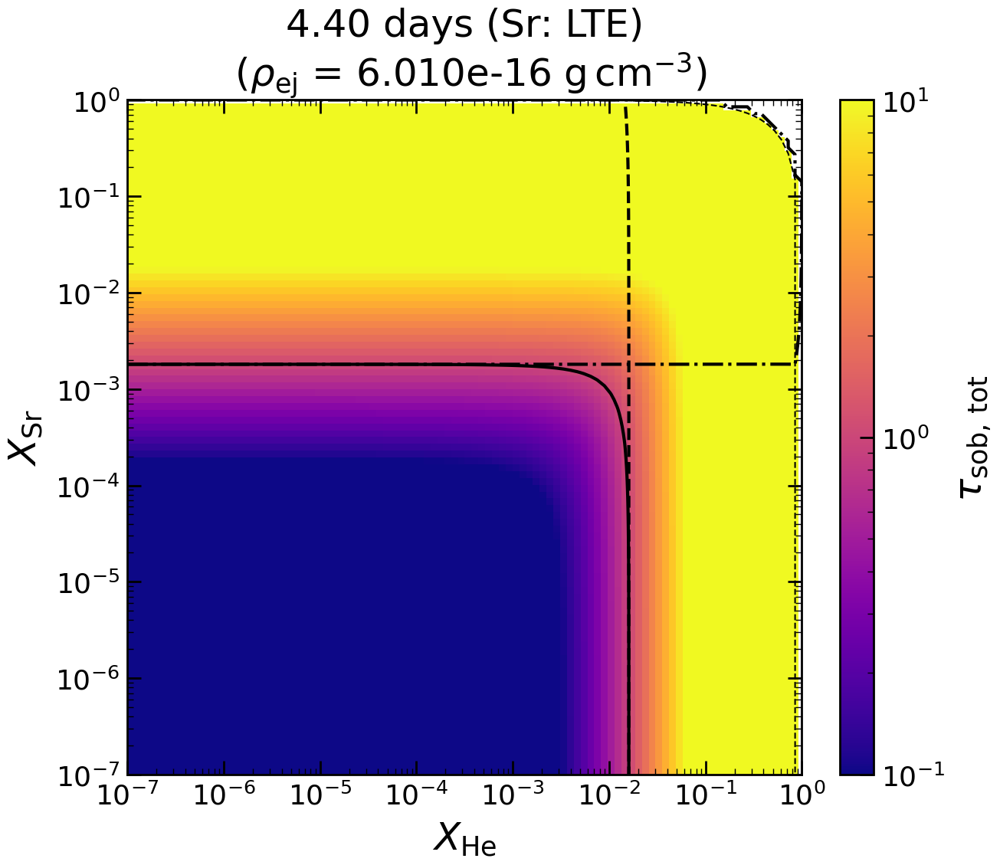

In [6]:
line_list_SrII = [
    ("4D3_2", "5P3_2", 2, 5, "10037"),
    ("4D5_2", "5P3_2", 3, 5, "10327"),
    ("4D3_2", "5P1_2", 2, 4, "10915")
    ]

g_SrII_ground = 2
A_Sr = 88.0

for each_res in each_res_list_KC26_LTE:
    term_l, term_u, idx_nd_l, idx_nd_u, wl_str = ("23S", "23P", 1, 3, "10830")
    
    npz_dir = Path(res_dir_KC26, each_res)
    fpath_nd = Path(npz_dir, f"nd_{each_res}.npz")
    npz_nd = np.load(fpath_nd)

    X_He_seq: npt.NDArray[np.float64] = npz_nd["X_He_seq"]
    X_Sr_seq: npt.NDArray[np.float64] = npz_nd["X_Sr_seq"]
    t_expl_str = each_res.split('_')[0][:-1]
    t_expl = float(t_expl_str)*DAY
    rho_ej = float(each_res.split('_')[3][:-4])
    tem_e = float(each_res.split('_')[1][:-1])

    # for He
    nd_res_He_pop = ma.array(npz_nd["nd_res_He_pop"]["_data"], mask=npz_nd["nd_res_He_pop"]["_mask"])
    nd_e_array = nd_res_He_pop[0]
    nd_res_He_levels = nd_res_He_pop[1:]

    tau_He_array = calc_tau_l_HeI(term_l, term_u, nd_res_He_levels[idx_nd_l], nd_res_He_levels[idx_nd_u], t_expl)

    # for Sr
    nd_res_Sr_pop = ma.array(npz_nd["nd_res_Sr_pop"]["_data"], mask=npz_nd["nd_res_Sr_pop"]["_mask"])

    tau_SrII_tot_array = np.zeros((X_Sr_seq.size, X_He_seq.size))
    for term_l, term_u, idx_nd_l, idx_nd_u, wl_str in line_list_SrII:
        tau_SrII_tot_array += calc_tau_l_SrII(idx_nd_l, idx_nd_u, nd_res_Sr_pop[1], t_expl, tem_e)

    tau_mix_array = tau_He_array + tau_SrII_tot_array

    fig, ax = plt.subplots(figsize=(14,12))

    ax.plot(X_He_seq, 1.0-X_He_seq, '--', c='k')

    mesh = ax.pcolormesh(X_He_seq, X_Sr_seq, tau_mix_array, cmap='plasma', norm=LogNorm(vmin=0.1, vmax=10), rasterized=True)
    ax.contour(X_He_seq, X_Sr_seq, tau_mix_array, [1.0], colors='k', linewidths=3)
    ax.contour(X_He_seq, X_Sr_seq, tau_He_array, [1.0], colors='k', linestyles='--', linewidths=3)
    ax.contour(X_He_seq, X_Sr_seq, tau_SrII_tot_array, [1.0], colors='k', linestyles='-.', linewidths=3)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"$X_\mathrm{He}$", fontsize="large")
    ax.set_ylabel(r"$X_\mathrm{Sr}$", fontsize="large")
    ax.set_title(f"{t_expl_str} days (Sr: LTE)\n" + rf" ($\rho_\mathrm{{ej}}$ = {rho_ej:.3e} $\mathrm{{g\, cm^{{-3}}}}$)")

    ax.set_xlim(1e-7, 1)
    ax.set_ylim(1e-7, 1)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.5)

    cbar = fig.colorbar(mesh, cax=cax)
    cbar.set_label(r"$\tau_\mathrm{sob,\, tot}$", fontsize="large")

    ax.set_aspect("equal")

    fig.tight_layout()
    plt.show()


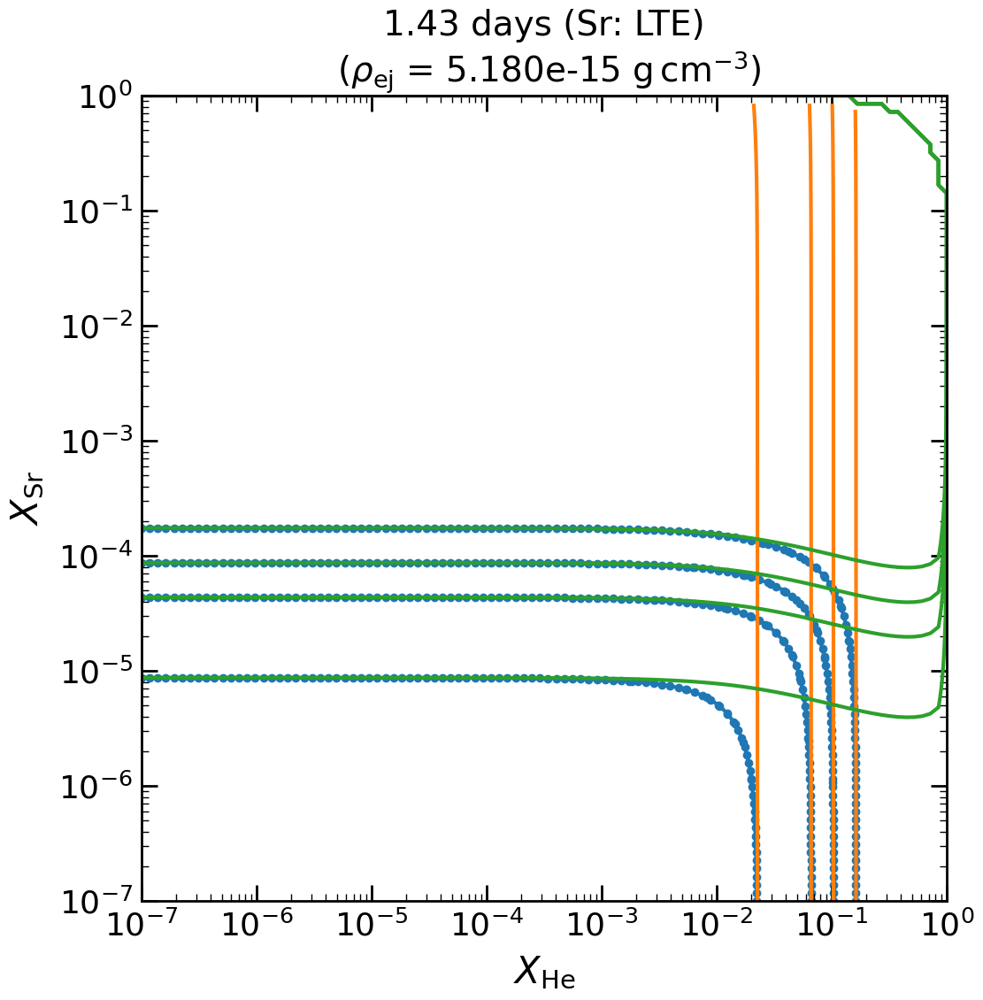

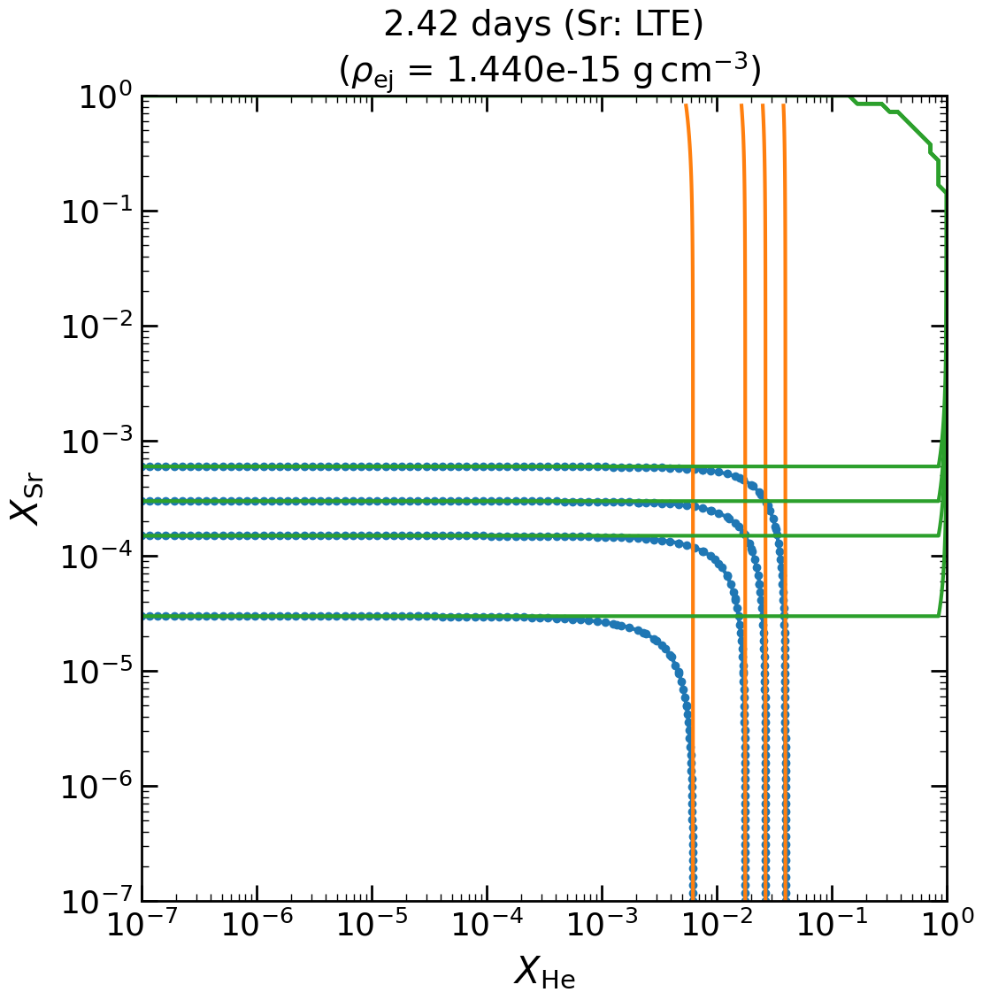

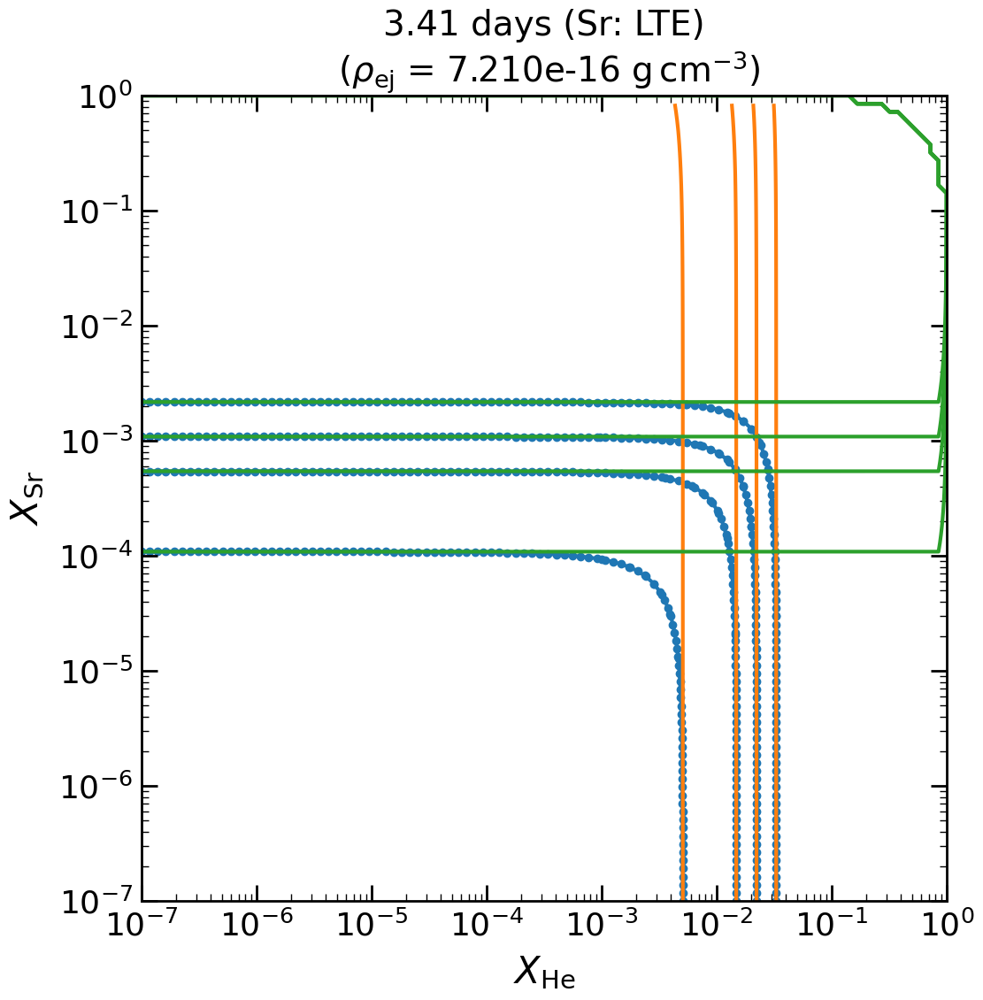

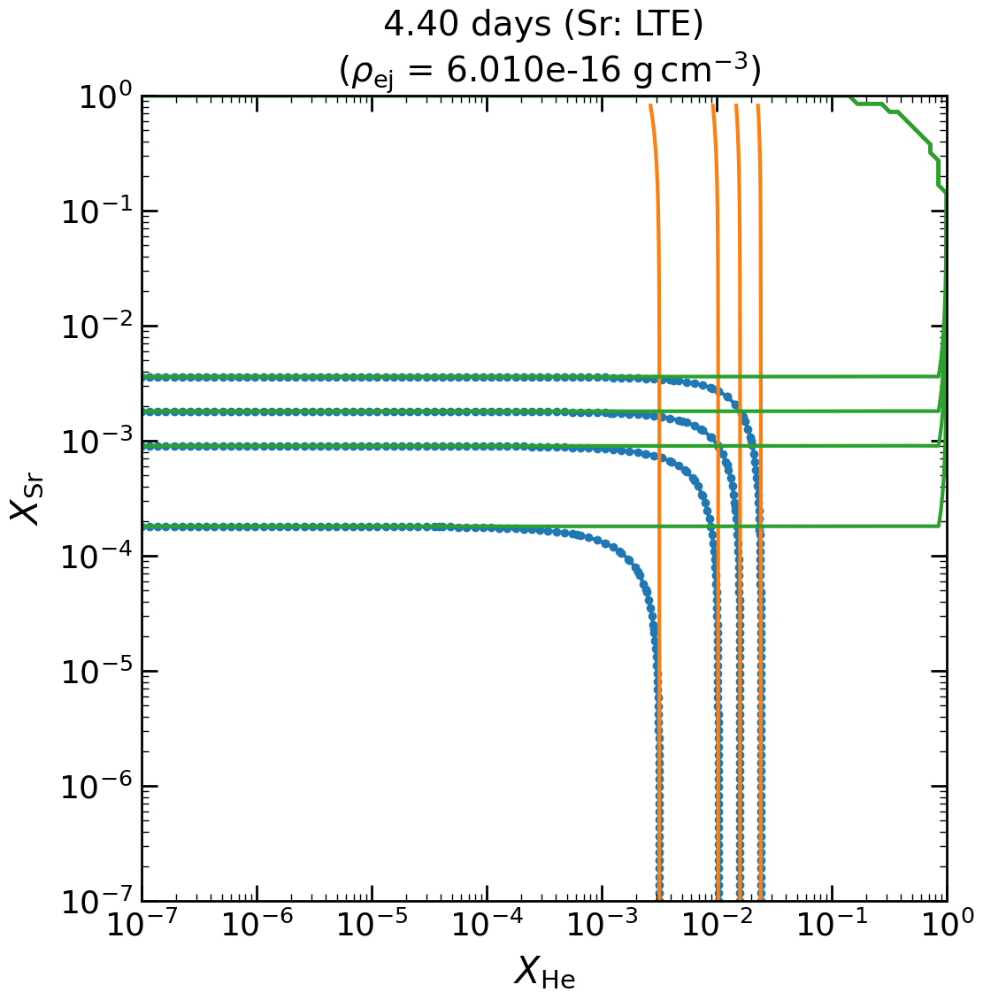

In [7]:
line_list_SrII = [
    ("4D3_2", "5P3_2", 2, 5, "10037"),
    ("4D5_2", "5P3_2", 3, 5, "10327"),
    ("4D3_2", "5P1_2", 2, 4, "10915")
    ]

g_SrII_ground = 2
A_Sr = 88.0

for each_res in each_res_list_KC26_LTE:
    fig, ax = plt.subplots(figsize=(12,12))

    term_l, term_u, idx_nd_l, idx_nd_u, wl_str = ("23S", "23P", 1, 3, "10830")
    
    npz_dir = Path(res_dir_KC26, each_res)
    fpath_nd = Path(npz_dir, f"nd_{each_res}.npz")
    npz_nd = np.load(fpath_nd)

    X_He_seq: npt.NDArray[np.float64] = npz_nd["X_He_seq"]
    X_Sr_seq: npt.NDArray[np.float64] = npz_nd["X_Sr_seq"]
    t_expl_str = each_res.split('_')[0][:-1]
    t_expl = float(t_expl_str)*DAY
    rho_ej = float(each_res.split('_')[3][:-4])
    tem_e = float(each_res.split('_')[1][:-1])

    # for He
    nd_res_He_pop = ma.array(npz_nd["nd_res_He_pop"]["_data"], mask=npz_nd["nd_res_He_pop"]["_mask"])
    nd_e_array = nd_res_He_pop[0]
    nd_res_He_levels = nd_res_He_pop[1:]

    tau_He_array = calc_tau_l_HeI(term_l, term_u, nd_res_He_levels[idx_nd_l], nd_res_He_levels[idx_nd_u], t_expl)

    # for Sr
    nd_res_Sr_pop = ma.array(npz_nd["nd_res_Sr_pop"]["_data"], mask=npz_nd["nd_res_Sr_pop"]["_mask"])

    tau_SrII_tot_array = np.zeros((X_Sr_seq.size, X_He_seq.size))
    for term_l, term_u, idx_nd_l, idx_nd_u, wl_str in line_list_SrII:
        tau_SrII_tot_array += calc_tau_l_SrII(idx_nd_l, idx_nd_u, nd_res_Sr_pop[1], t_expl, tem_e)

    tau_mix_array = tau_He_array + tau_SrII_tot_array

    contour = ax.contour(X_He_seq, X_Sr_seq, tau_mix_array, [0.1, 0.5, 1.0, 2.0], colors=f'C0', linewidths=3)
    ax.contour(X_He_seq, X_Sr_seq, tau_He_array, [0.1, 0.5, 1.0, 2.0], colors=f'C1', linewidths=3)
    ax.contour(X_He_seq, X_Sr_seq, tau_SrII_tot_array, [0.1, 0.5, 1.0, 2.0], colors=f'C2', linewidths=3)

    path_lowest = contour.get_paths()[0]
    path_lower = contour.get_paths()[1]
    path_center = contour.get_paths()[2]
    path_upper = contour.get_paths()[3]
    
    vertices_lowest = path_lowest.vertices.T
    vertices_lower = path_lower.vertices.T
    vertices_center = path_center.vertices.T
    vertices_upper = path_upper.vertices.T
    
    X_He_coords_lowest = vertices_lowest[0]
    X_Sr_coords_lowest = vertices_lowest[1]
    X_He_coords_lower = vertices_lower[0]
    X_Sr_coords_lower = vertices_lower[1]
    X_He_coords_center = vertices_center[0]
    X_Sr_coords_center = vertices_center[1]
    X_He_coords_upper = vertices_upper[0]
    X_Sr_coords_upper = vertices_upper[1]
    
    clip_condition_for_lowest = X_He_coords_lowest < 0.5
    clip_condition_for_lower = X_He_coords_lower < 0.5
    clip_condition_for_center = X_He_coords_center < 0.5
    clip_condition_for_upper = X_He_coords_upper < 0.5
    X_He_coords_lowest_clipped = X_He_coords_lowest[clip_condition_for_lowest]
    X_Sr_coords_lowest_clipped = X_Sr_coords_lowest[clip_condition_for_lowest]
    X_He_coords_lower_clipped = X_He_coords_lower[clip_condition_for_lower]
    X_Sr_coords_lower_clipped = X_Sr_coords_lower[clip_condition_for_lower]
    X_He_coords_center_clipped = X_He_coords_center[clip_condition_for_center]
    X_Sr_coords_center_clipped = X_Sr_coords_center[clip_condition_for_center]
    X_He_coords_upper_clipped = X_He_coords_upper[clip_condition_for_upper]
    X_Sr_coords_upper_clipped = X_Sr_coords_upper[clip_condition_for_upper]

    sort_idx_X_He_coords_lowest_clipped = X_He_coords_lowest_clipped.argsort()
    sort_idx_X_He_coords_lower_clipped = X_He_coords_lower_clipped.argsort()
    sort_idx_X_He_coords_center_clipped = X_He_coords_center_clipped.argsort()
    sort_idx_X_He_coords_upper_clipped = X_He_coords_upper_clipped.argsort()
    X_He_coords_lowest_clipped = X_He_coords_lowest_clipped[sort_idx_X_He_coords_lowest_clipped]
    X_Sr_coords_lowest_clipped = X_Sr_coords_lowest_clipped[sort_idx_X_He_coords_lowest_clipped]
    X_He_coords_lower_clipped = X_He_coords_lower_clipped[sort_idx_X_He_coords_lower_clipped]
    X_Sr_coords_lower_clipped = X_Sr_coords_lower_clipped[sort_idx_X_He_coords_lower_clipped]
    X_He_coords_center_clipped = X_He_coords_center_clipped[sort_idx_X_He_coords_center_clipped]
    X_Sr_coords_center_clipped = X_Sr_coords_center_clipped[sort_idx_X_He_coords_center_clipped]
    X_He_coords_upper_clipped = X_He_coords_upper_clipped[sort_idx_X_He_coords_upper_clipped]
    X_Sr_coords_upper_clipped = X_Sr_coords_upper_clipped[sort_idx_X_He_coords_upper_clipped]
    
    ax.scatter(X_He_coords_lowest_clipped, X_Sr_coords_lowest_clipped, c=f'C0')
    ax.scatter(X_He_coords_lower_clipped, X_Sr_coords_lower_clipped, c=f'C0')
    ax.scatter(X_He_coords_center_clipped, X_Sr_coords_center_clipped, c=f'C0')
    ax.scatter(X_He_coords_upper_clipped, X_Sr_coords_upper_clipped, c=f'C0')

    # fpath = Path("coords-He_vs_Sr", "LTE", f"coords-tau_tot-w_lu-clipped-{t_expl_str}d.npz")
    # np.savez(fpath, X_He_coords_lowest=X_He_coords_lowest_clipped, X_Sr_coords_lowest=X_Sr_coords_lowest_clipped,
    #          X_He_coords_lower=X_He_coords_lower_clipped, X_Sr_coords_lower=X_Sr_coords_lower_clipped,
    #          X_He_coords_center=X_He_coords_center_clipped, X_Sr_coords_center=X_Sr_coords_center_clipped,
    #          X_He_coords_upper=X_He_coords_upper_clipped, X_Sr_coords_upper=X_Sr_coords_upper_clipped)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"$X_\mathrm{He}$")
    ax.set_ylabel(r"$X_\mathrm{Sr}$")
    ax.set_title(f"{t_expl_str} days (Sr: LTE)\n" + rf" ($\rho_\mathrm{{ej}}$ = {rho_ej:.3e} $\mathrm{{g\, cm^{{-3}}}}$)", fontsize=28)

    ax.set_aspect("equal")    
    fig.tight_layout()
    plt.show()

## Sr NLTE

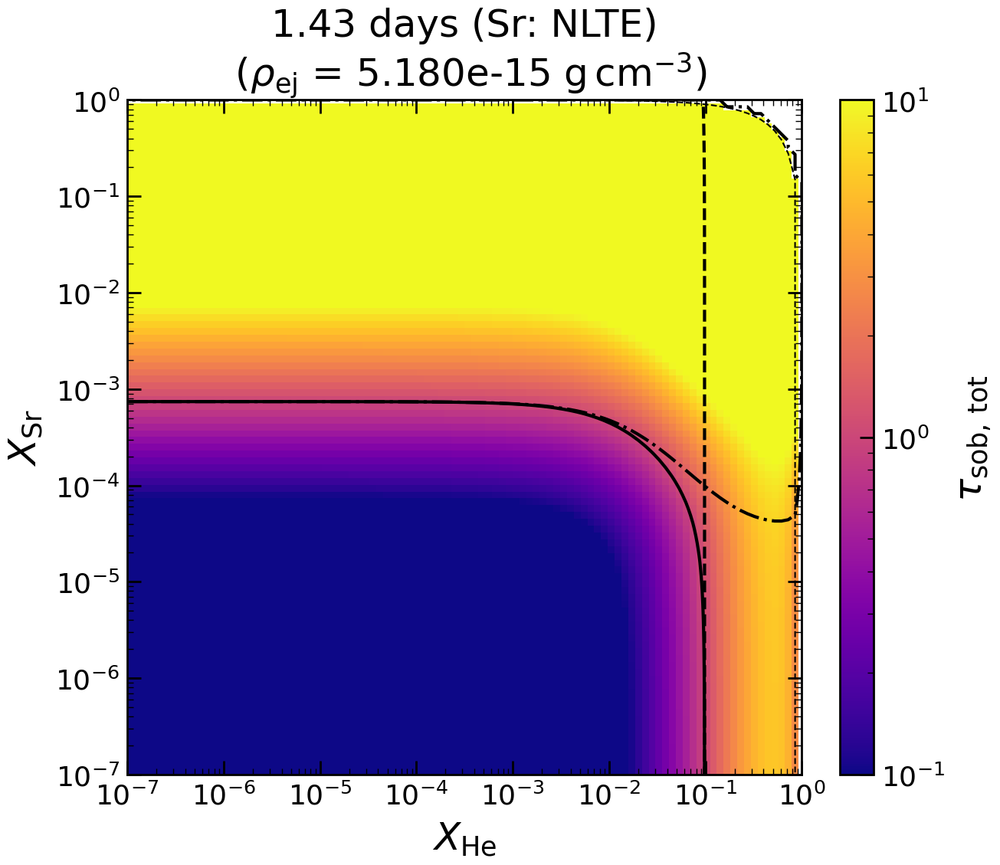

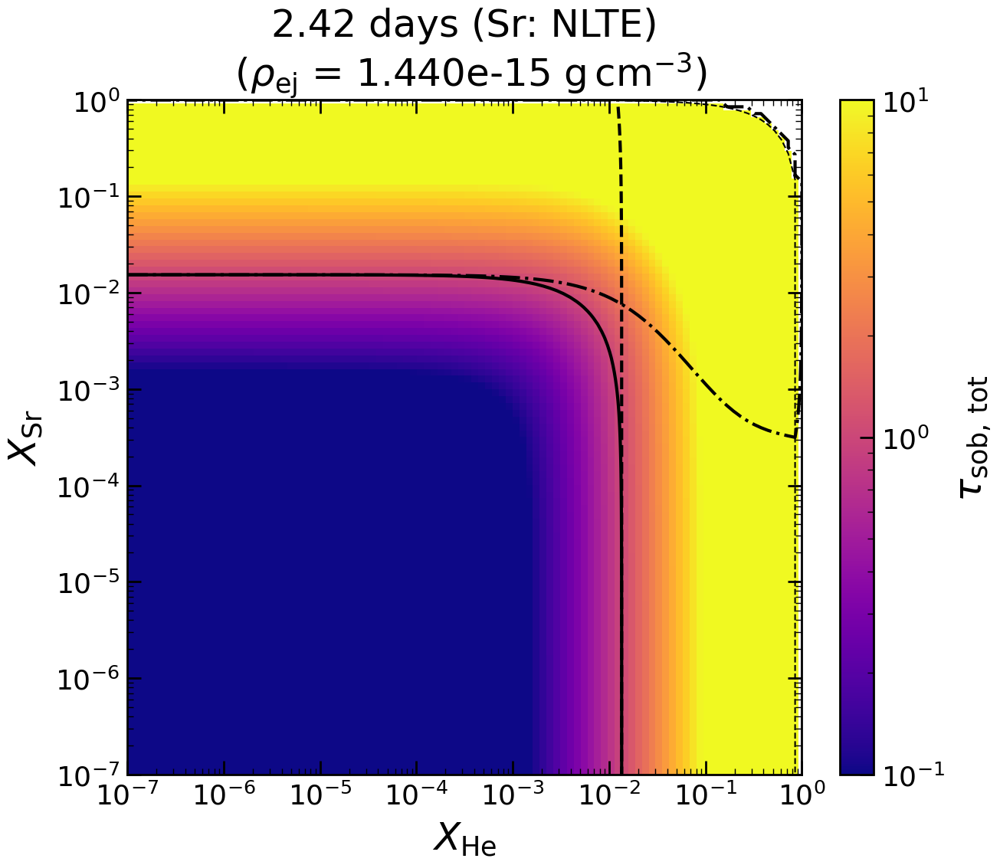

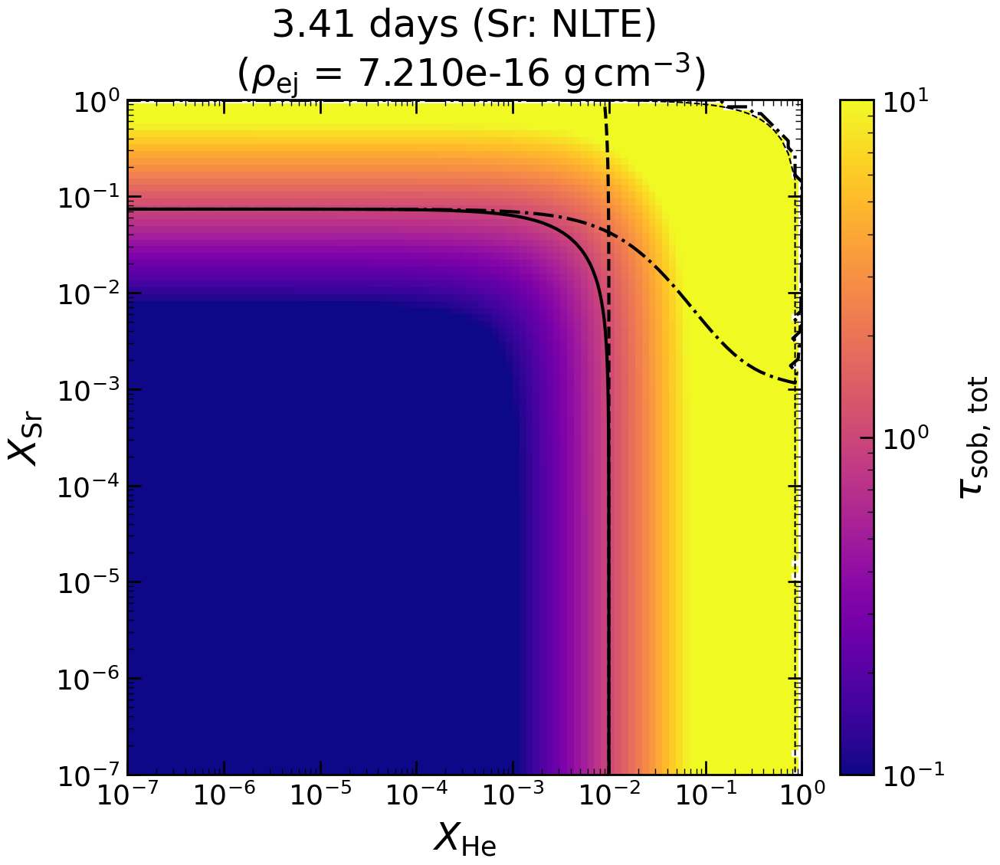

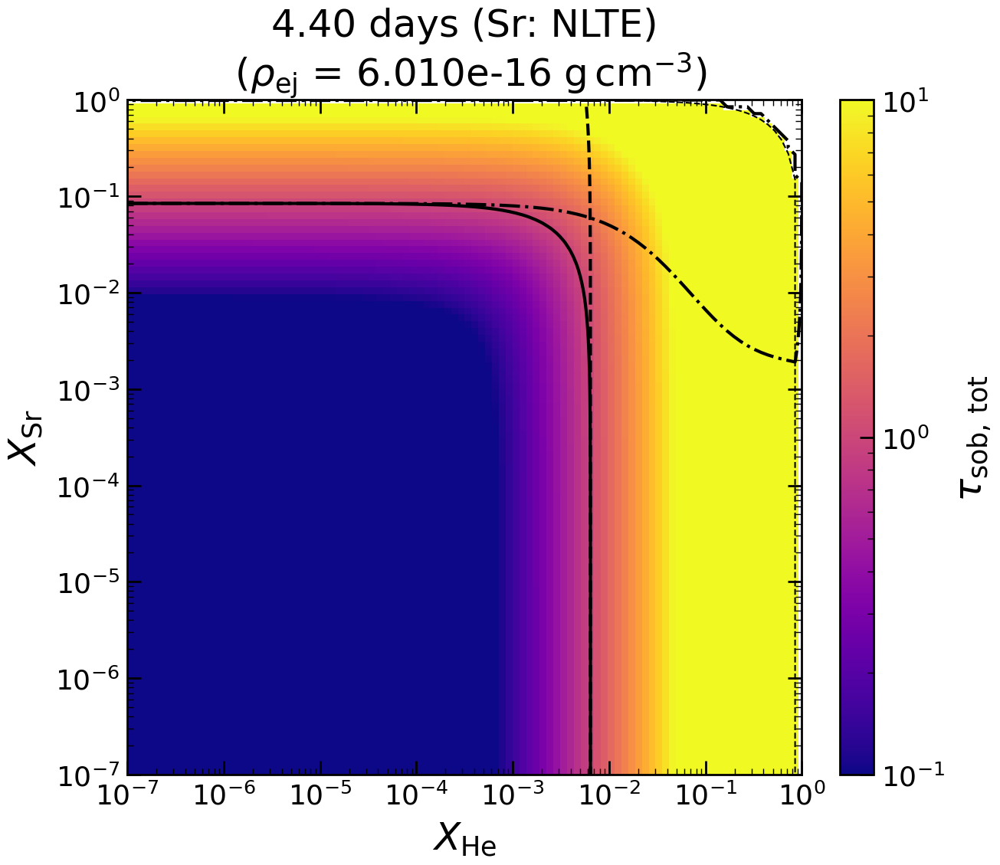

In [9]:
line_list_SrII = [
    ("4D3_2", "5P3_2", 2, 5, "10037"),
    ("4D5_2", "5P3_2", 3, 5, "10327"),
    ("4D3_2", "5P1_2", 2, 4, "10915")
    ]

g_SrII_ground = 2
A_Sr = 88.0

for each_res in each_res_list_KC26_NLTE:
    term_l, term_u, idx_nd_l, idx_nd_u, wl_str = ("23S", "23P", 1, 3, "10830")
    
    npz_dir = Path(res_dir_KC26, each_res)
    fpath_nd = Path(npz_dir, f"nd_{each_res}.npz")
    npz_nd = np.load(fpath_nd)

    X_He_seq: npt.NDArray[np.float64] = npz_nd["X_He_seq"]
    X_Sr_seq: npt.NDArray[np.float64] = npz_nd["X_Sr_seq"]
    t_expl_str = each_res.split('_')[0][:-1]
    t_expl = float(t_expl_str)*DAY
    rho_ej = float(each_res.split('_')[3][:-4])
    tem_e = float(each_res.split('_')[1][:-1])

    # for He
    nd_res_He_pop = ma.array(npz_nd["nd_res_He_pop"]["_data"], mask=npz_nd["nd_res_He_pop"]["_mask"])
    nd_e_array = nd_res_He_pop[0]
    nd_res_He_levels = nd_res_He_pop[1:]

    tau_He_array = calc_tau_l_HeI(term_l, term_u, nd_res_He_levels[idx_nd_l], nd_res_He_levels[idx_nd_u], t_expl)

    # for Sr
    nd_res_Sr_pop = ma.array(npz_nd["nd_res_Sr_pop"]["_data"], mask=npz_nd["nd_res_Sr_pop"]["_mask"])

    tau_SrII_tot_array = np.zeros((X_Sr_seq.size, X_He_seq.size))
    for term_l, term_u, idx_nd_l, idx_nd_u, wl_str in line_list_SrII:
        tau_SrII_tot_array += calc_tau_l_SrII(idx_nd_l, idx_nd_u, nd_res_Sr_pop[1], t_expl, tem_e)

    tau_mix_array = tau_He_array + tau_SrII_tot_array

    fig, ax = plt.subplots(figsize=(14,12))

    ax.plot(X_He_seq, 1.0-X_He_seq, '--', c='k')

    mesh = ax.pcolormesh(X_He_seq, X_Sr_seq, tau_mix_array, cmap='plasma', norm=LogNorm(vmin=0.1, vmax=10), rasterized=True)
    ax.contour(X_He_seq, X_Sr_seq, tau_mix_array, [1.0], colors='k', linewidths=3)
    ax.contour(X_He_seq, X_Sr_seq, tau_He_array, [1.0], colors='k', linestyles='--', linewidths=3)
    ax.contour(X_He_seq, X_Sr_seq, tau_SrII_tot_array, [1.0], colors='k', linestyles='-.', linewidths=3)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"$X_\mathrm{He}$", fontsize="large")
    ax.set_ylabel(r"$X_\mathrm{Sr}$", fontsize="large")
    ax.set_title(f"{t_expl_str} days (Sr: NLTE)\n" + rf" ($\rho_\mathrm{{ej}}$ = {rho_ej:.3e} $\mathrm{{g\, cm^{{-3}}}}$)")

    ax.set_xlim(1e-7, 1)
    ax.set_ylim(1e-7, 1)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.5)

    cbar = fig.colorbar(mesh, cax=cax)
    cbar.set_label(r"$\tau_\mathrm{sob,\, tot}$", fontsize="large")

    ax.set_aspect("equal")

    fig.tight_layout()
    plt.show()


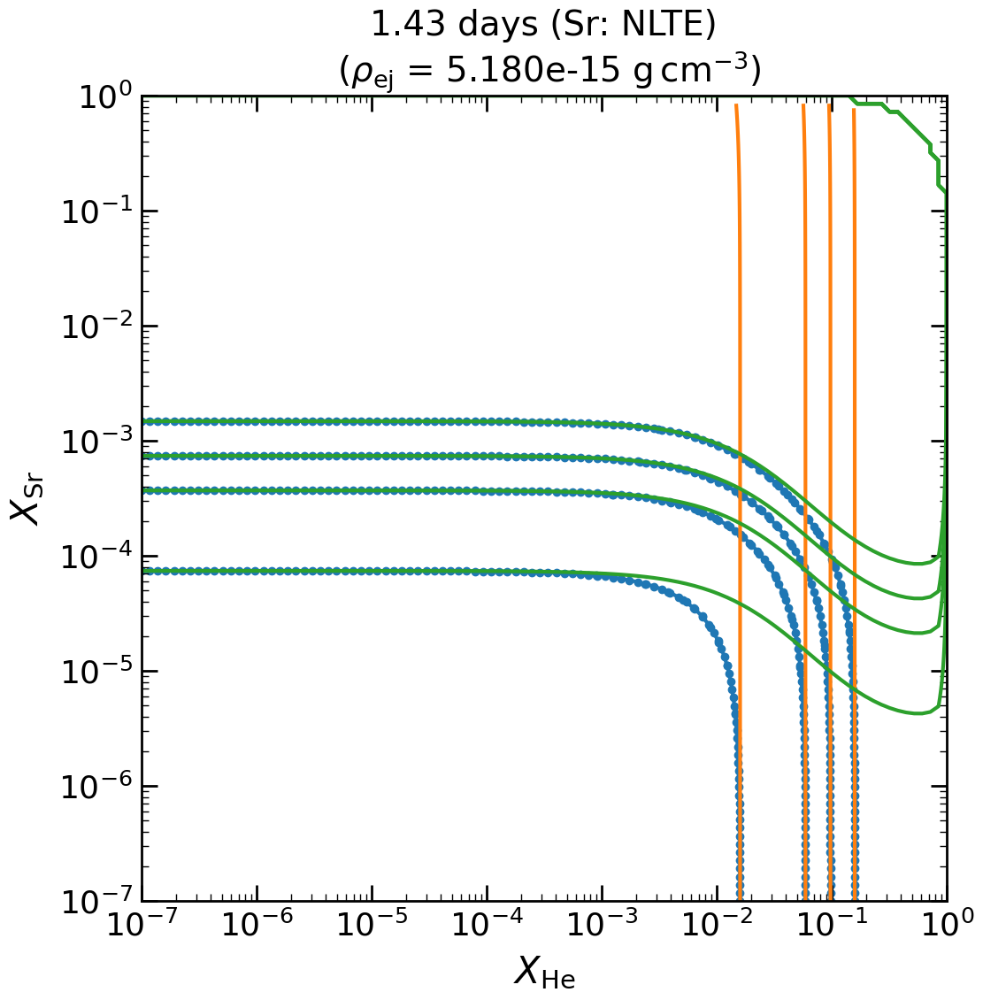

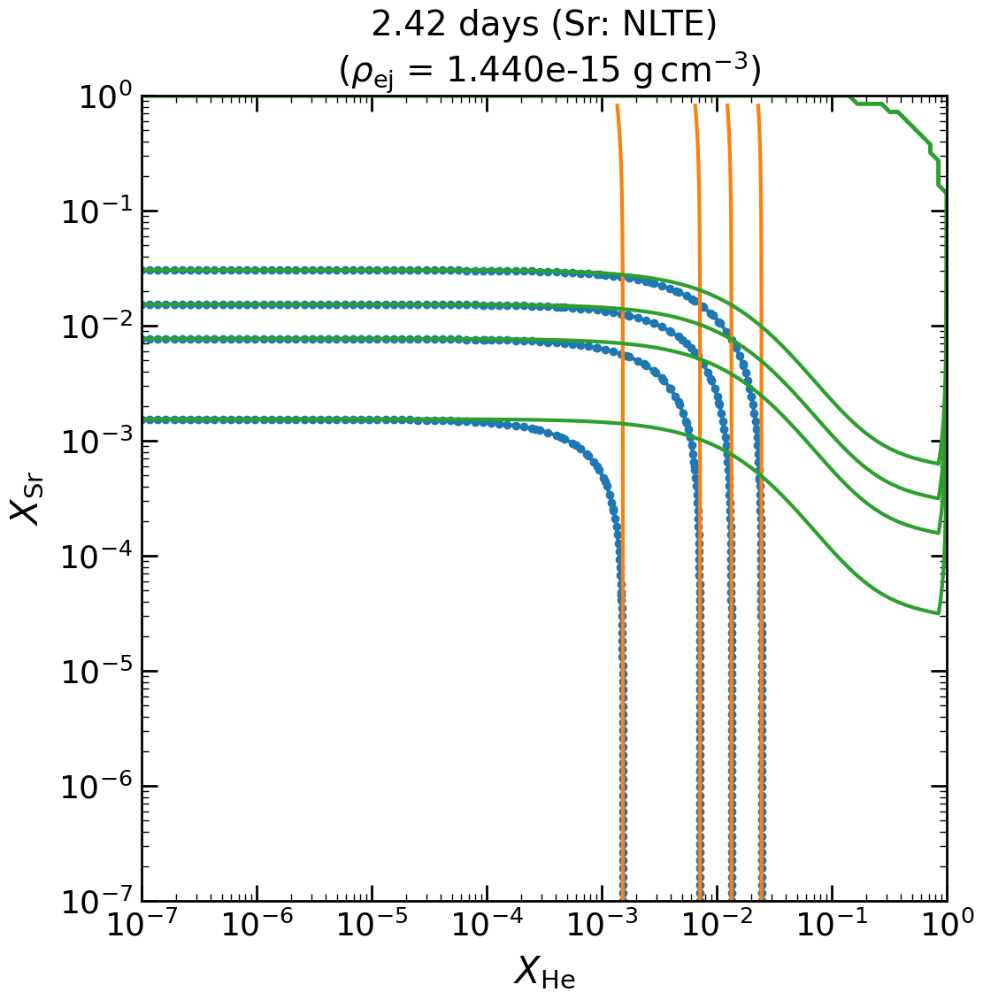

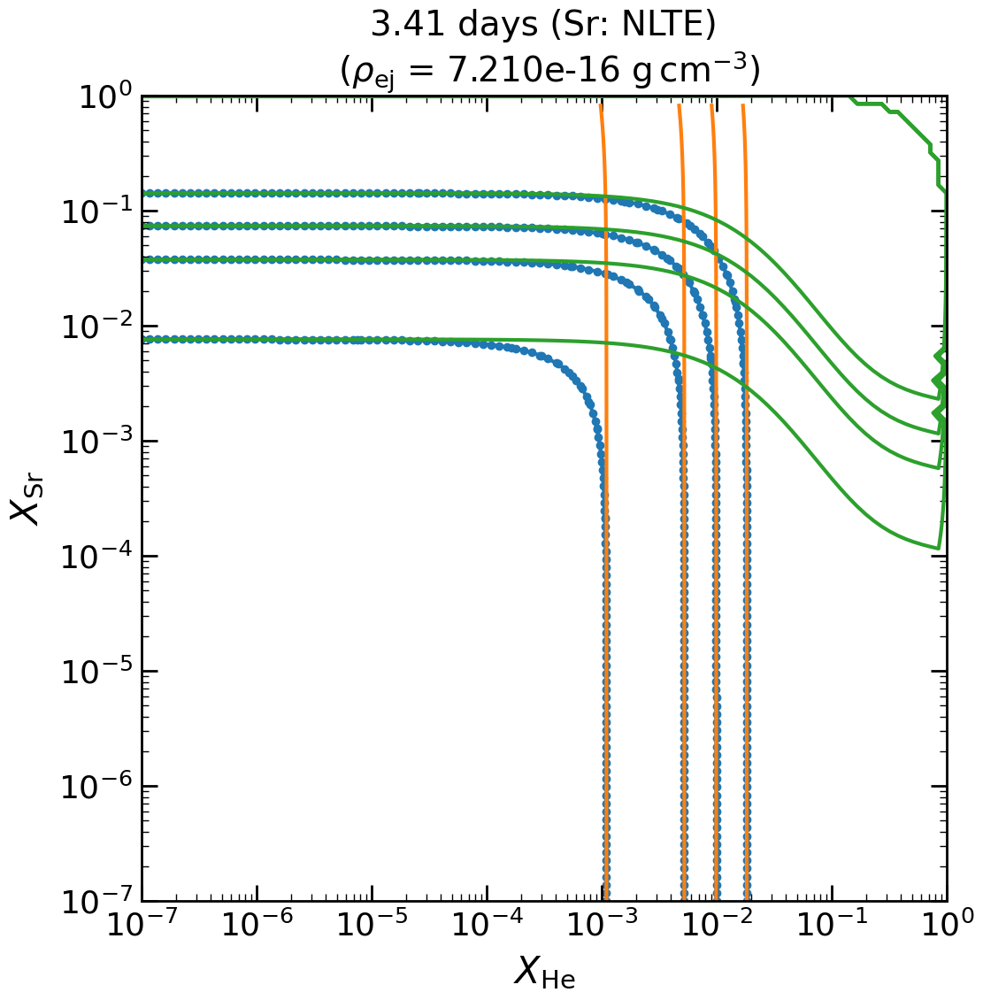

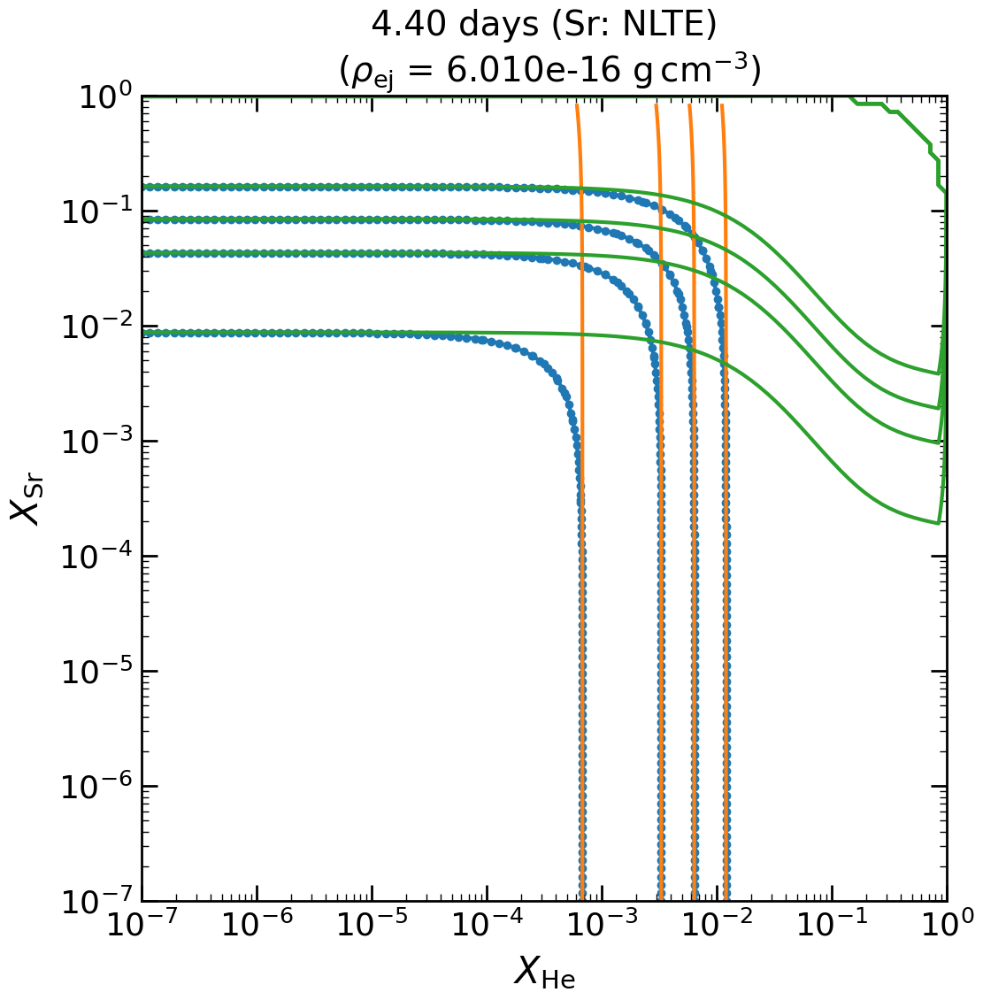

In [10]:
line_list_SrII = [
    ("4D3_2", "5P3_2", 2, 5, "10037"),
    ("4D5_2", "5P3_2", 3, 5, "10327"),
    ("4D3_2", "5P1_2", 2, 4, "10915")
    ]

g_SrII_ground = 2
A_Sr = 88.0

for each_res in each_res_list_KC26_NLTE:
    fig, ax = plt.subplots(figsize=(12,12))

    term_l, term_u, idx_nd_l, idx_nd_u, wl_str = ("23S", "23P", 1, 3, "10830")
    
    npz_dir = Path(res_dir_KC26, each_res)
    fpath_nd = Path(npz_dir, f"nd_{each_res}.npz")
    npz_nd = np.load(fpath_nd)

    X_He_seq: npt.NDArray[np.float64] = npz_nd["X_He_seq"]
    X_Sr_seq: npt.NDArray[np.float64] = npz_nd["X_Sr_seq"]
    t_expl_str = each_res.split('_')[0][:-1]
    t_expl = float(t_expl_str)*DAY
    rho_ej = float(each_res.split('_')[3][:-4])
    tem_e = float(each_res.split('_')[1][:-1])

    # for He
    nd_res_He_pop = ma.array(npz_nd["nd_res_He_pop"]["_data"], mask=npz_nd["nd_res_He_pop"]["_mask"])
    nd_e_array = nd_res_He_pop[0]
    nd_res_He_levels = nd_res_He_pop[1:]

    tau_He_array = calc_tau_l_HeI(term_l, term_u, nd_res_He_levels[idx_nd_l], nd_res_He_levels[idx_nd_u], t_expl)

    # for Sr
    nd_res_Sr_pop = ma.array(npz_nd["nd_res_Sr_pop"]["_data"], mask=npz_nd["nd_res_Sr_pop"]["_mask"])

    tau_SrII_tot_array = np.zeros((X_Sr_seq.size, X_He_seq.size))
    for term_l, term_u, idx_nd_l, idx_nd_u, wl_str in line_list_SrII:
        tau_SrII_tot_array += calc_tau_l_SrII(idx_nd_l, idx_nd_u, nd_res_Sr_pop[1], t_expl, tem_e)

    tau_mix_array = tau_He_array + tau_SrII_tot_array

    contour = ax.contour(X_He_seq, X_Sr_seq, tau_mix_array, [0.1, 0.5, 1.0, 2.0], colors=f'C0', linewidths=3)
    ax.contour(X_He_seq, X_Sr_seq, tau_He_array, [0.1, 0.5, 1.0, 2.0], colors=f'C1', linewidths=3)
    ax.contour(X_He_seq, X_Sr_seq, tau_SrII_tot_array, [0.1, 0.5, 1.0, 2.0], colors=f'C2', linewidths=3)

    path_lowest = contour.get_paths()[0]
    path_lower = contour.get_paths()[1]
    path_center = contour.get_paths()[2]
    path_upper = contour.get_paths()[3]
    
    vertices_lowest = path_lowest.vertices.T
    vertices_lower = path_lower.vertices.T
    vertices_center = path_center.vertices.T
    vertices_upper = path_upper.vertices.T
    
    X_He_coords_lowest = vertices_lowest[0]
    X_Sr_coords_lowest = vertices_lowest[1]
    X_He_coords_lower = vertices_lower[0]
    X_Sr_coords_lower = vertices_lower[1]
    X_He_coords_center = vertices_center[0]
    X_Sr_coords_center = vertices_center[1]
    X_He_coords_upper = vertices_upper[0]
    X_Sr_coords_upper = vertices_upper[1]
    
    clip_condition_for_lowest = X_He_coords_lowest < 0.5
    clip_condition_for_lower = X_He_coords_lower < 0.5
    clip_condition_for_center = X_He_coords_center < 0.5
    clip_condition_for_upper = X_He_coords_upper < 0.5
    X_He_coords_lowest_clipped = X_He_coords_lowest[clip_condition_for_lowest]
    X_Sr_coords_lowest_clipped = X_Sr_coords_lowest[clip_condition_for_lowest]
    X_He_coords_lower_clipped = X_He_coords_lower[clip_condition_for_lower]
    X_Sr_coords_lower_clipped = X_Sr_coords_lower[clip_condition_for_lower]
    X_He_coords_center_clipped = X_He_coords_center[clip_condition_for_center]
    X_Sr_coords_center_clipped = X_Sr_coords_center[clip_condition_for_center]
    X_He_coords_upper_clipped = X_He_coords_upper[clip_condition_for_upper]
    X_Sr_coords_upper_clipped = X_Sr_coords_upper[clip_condition_for_upper]

    sort_idx_X_He_coords_lowest_clipped = X_He_coords_lowest_clipped.argsort()
    sort_idx_X_He_coords_lower_clipped = X_He_coords_lower_clipped.argsort()
    sort_idx_X_He_coords_center_clipped = X_He_coords_center_clipped.argsort()
    sort_idx_X_He_coords_upper_clipped = X_He_coords_upper_clipped.argsort()
    X_He_coords_lowest_clipped = X_He_coords_lowest_clipped[sort_idx_X_He_coords_lowest_clipped]
    X_Sr_coords_lowest_clipped = X_Sr_coords_lowest_clipped[sort_idx_X_He_coords_lowest_clipped]
    X_He_coords_lower_clipped = X_He_coords_lower_clipped[sort_idx_X_He_coords_lower_clipped]
    X_Sr_coords_lower_clipped = X_Sr_coords_lower_clipped[sort_idx_X_He_coords_lower_clipped]
    X_He_coords_center_clipped = X_He_coords_center_clipped[sort_idx_X_He_coords_center_clipped]
    X_Sr_coords_center_clipped = X_Sr_coords_center_clipped[sort_idx_X_He_coords_center_clipped]
    X_He_coords_upper_clipped = X_He_coords_upper_clipped[sort_idx_X_He_coords_upper_clipped]
    X_Sr_coords_upper_clipped = X_Sr_coords_upper_clipped[sort_idx_X_He_coords_upper_clipped]
    
    ax.scatter(X_He_coords_lowest_clipped, X_Sr_coords_lowest_clipped, c=f'C0')
    ax.scatter(X_He_coords_lower_clipped, X_Sr_coords_lower_clipped, c=f'C0')
    ax.scatter(X_He_coords_center_clipped, X_Sr_coords_center_clipped, c=f'C0')
    ax.scatter(X_He_coords_upper_clipped, X_Sr_coords_upper_clipped, c=f'C0')

    # fpath = Path("coords-He_vs_Sr", "NLTE", f"coords-tau_tot-w_lu-clipped-{t_expl_str}d.npz")
    # np.savez(fpath, X_He_coords_lowest=X_He_coords_lowest_clipped, X_Sr_coords_lowest=X_Sr_coords_lowest_clipped,
    #          X_He_coords_lower=X_He_coords_lower_clipped, X_Sr_coords_lower=X_Sr_coords_lower_clipped,
    #          X_He_coords_center=X_He_coords_center_clipped, X_Sr_coords_center=X_Sr_coords_center_clipped,
    #          X_He_coords_upper=X_He_coords_upper_clipped, X_Sr_coords_upper=X_Sr_coords_upper_clipped)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"$X_\mathrm{He}$")
    ax.set_ylabel(r"$X_\mathrm{Sr}$")
    ax.set_title(f"{t_expl_str} days (Sr: NLTE)\n" + rf" ($\rho_\mathrm{{ej}}$ = {rho_ej:.3e} $\mathrm{{g\, cm^{{-3}}}}$)", fontsize=28)

    ax.set_aspect("equal")
    fig.tight_layout()
    plt.show()

## comparison

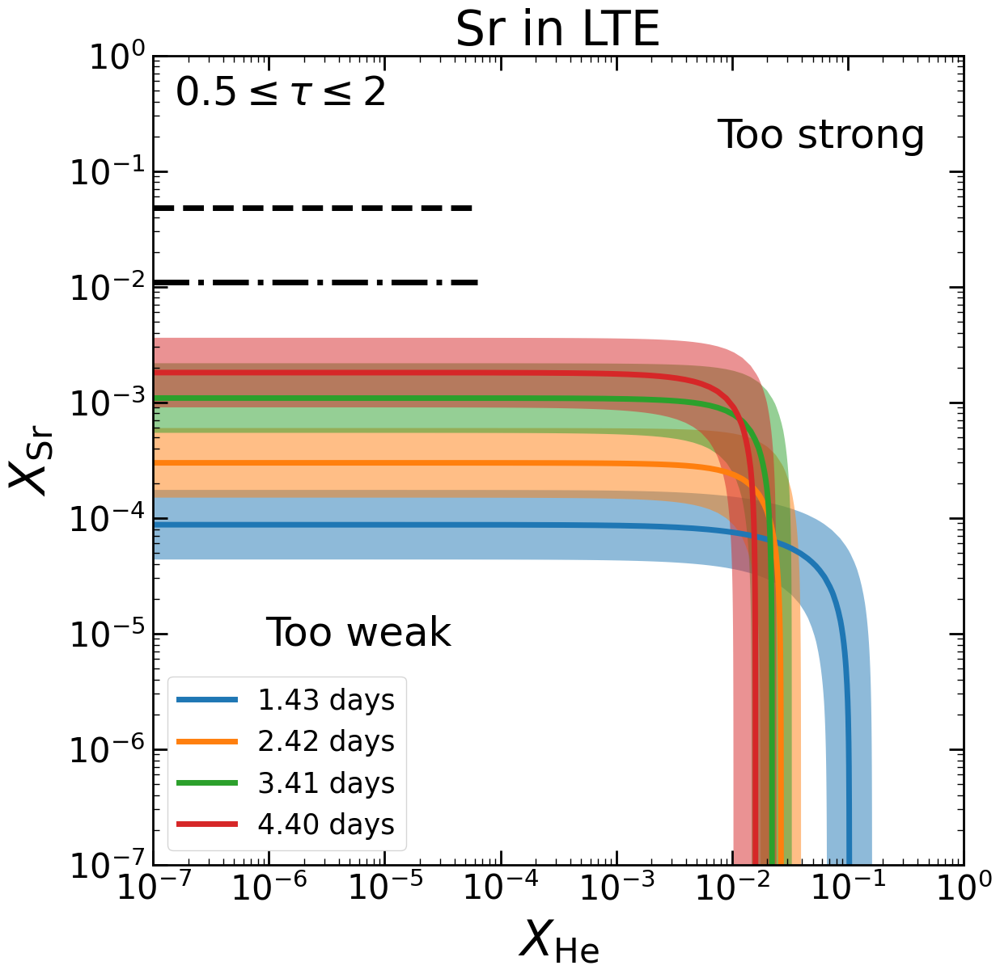

In [11]:
phase_seq = ["1.43", "2.42", "3.41", "4.40"]

fig, ax = plt.subplots(figsize=(13, 13))

for idx_phase, phase in enumerate(phase_seq):    
    # LTE ------------------------
    fpath = Path("coords-He_vs_Sr", "LTE", f"coords-tau_tot-w_lu-clipped-{phase}d.npz")
    npz = np.load(fpath)

    X_He_coords_lower = npz["X_He_coords_lower"]
    X_Sr_coords_lower = npz["X_Sr_coords_lower"]
    X_He_coords_center = npz["X_He_coords_center"]
    X_Sr_coords_center = npz["X_Sr_coords_center"]
    X_He_coords_upper = npz["X_He_coords_upper"]
    X_Sr_coords_upper = npz["X_Sr_coords_upper"]

    verts = list(zip(X_He_coords_upper, X_Sr_coords_upper)) + list(zip(X_He_coords_lower[::-1], X_Sr_coords_lower[::-1]))
    uncertain_region = Polygon(verts, fc=f"C{idx_phase}", alpha=0.5)
    ax.add_patch(uncertain_region)

    ax.plot(X_He_coords_center, X_Sr_coords_center, c=f"C{idx_phase}", lw=5, label=f"{phase} days")
    # -----------------------------

X_Sr_solar_Amin69 = 0.011
ax.axhline(X_Sr_solar_Amin69, xmax=0.4, ls='-.', lw=5, c='k')

X_Sr_solar_Amin88 = 0.048
ax.axhline(X_Sr_solar_Amin88, xmax=0.4, ls='--', lw=5, c='k')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r"$X_\mathrm{He}$", fontsize="x-large")
ax.set_ylabel(r"$X_\mathrm{Sr}$", fontsize="x-large")
ax.tick_params(labelsize="medium") 
ax.set_title("Sr in LTE", fontsize="x-large") 

ax.annotate(r"$0.5 \leq \tau \leq 2$", (1.5e-7, 0.7), ha='left', va='top', fontsize="large")

ax.annotate('Too strong', (6e-2, 2e-1), ha='center', va='center', fontsize="large")
ax.annotate('Too weak', (6e-6, 1e-5), ha='center', va='center', fontsize="large")

ax.set_xlim(1e-7, 1)
ax.set_ylim(1e-7, 1)

ax.legend(loc=3, fontsize="small")

ax.set_aspect("equal")
fig.tight_layout()

plt.show()

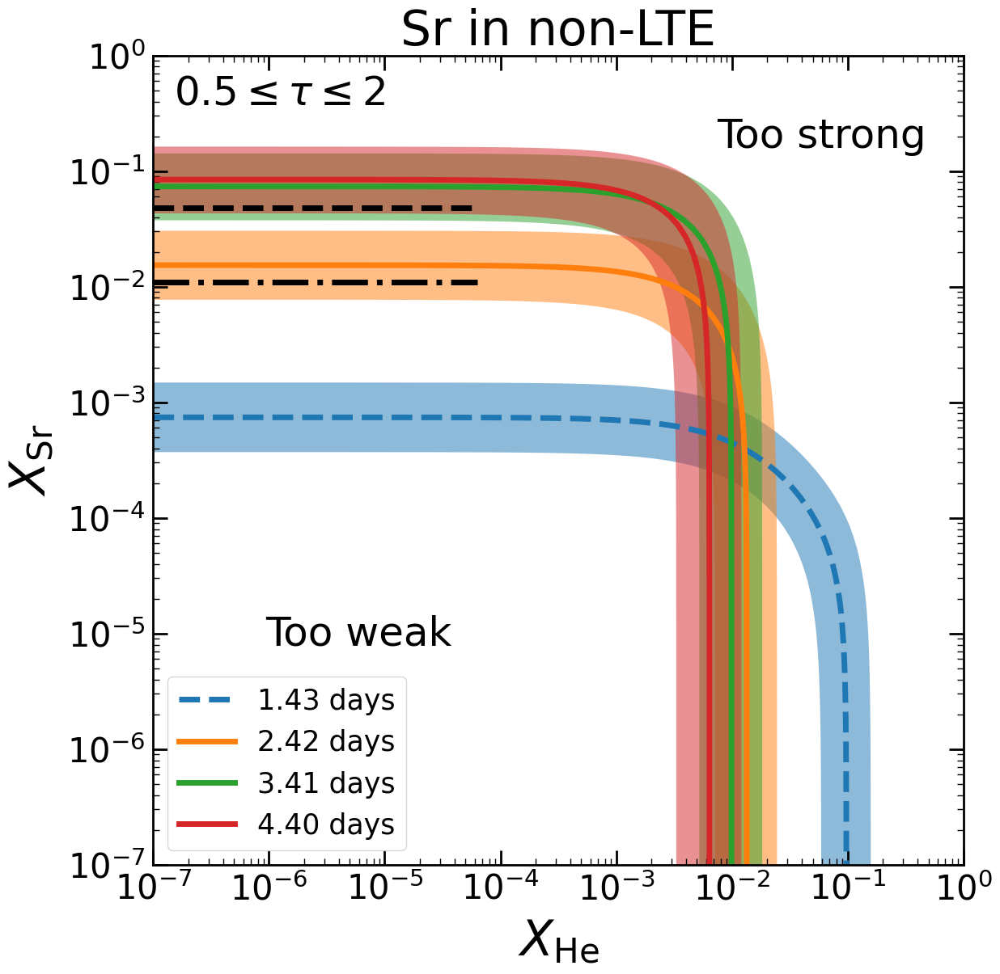

In [12]:
phase_seq = ["1.43", "2.42", "3.41", "4.40"]

fig, ax = plt.subplots(figsize=(13, 13))

for idx_phase, phase in enumerate(phase_seq):  
    
    # NLTE ------------------------
    fpath = Path("coords-He_vs_Sr", "NLTE", f"coords-tau_tot-w_lu-clipped-{phase}d.npz")
    npz = np.load(fpath)

    X_He_coords_lower = npz["X_He_coords_lower"]
    X_Sr_coords_lower = npz["X_Sr_coords_lower"]
    X_He_coords_center = npz["X_He_coords_center"]
    X_Sr_coords_center = npz["X_Sr_coords_center"]
    X_He_coords_upper = npz["X_He_coords_upper"]
    X_Sr_coords_upper = npz["X_Sr_coords_upper"]

    verts = list(zip(X_He_coords_upper, X_Sr_coords_upper)) + list(zip(X_He_coords_lower[::-1], X_Sr_coords_lower[::-1]))
    uncertain_region = Polygon(verts, fc=f"C{idx_phase}", alpha=0.5)
    ax.add_patch(uncertain_region)

    if idx_phase == 0:
        ls = '--'
    else:
        ls = '-'    
    ax.plot(X_He_coords_center, X_Sr_coords_center, ls=ls, c=f"C{idx_phase}", lw=5, label=f"{phase} days")
    # -----------------------------

X_Sr_solar_Amin69 = 0.011
ax.axhline(X_Sr_solar_Amin69, xmax=0.4, ls='-.', lw=5, c='k')

X_Sr_solar_Amin88 = 0.048
ax.axhline(X_Sr_solar_Amin88, xmax=0.4, ls='--', lw=5, c='k')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r"$X_\mathrm{He}$", fontsize="x-large")
ax.set_ylabel(r"$X_\mathrm{Sr}$", fontsize="x-large")
ax.tick_params(labelsize="medium") 
ax.set_title("Sr in non-LTE", fontsize="x-large") 


ax.annotate(r"$0.5 \leq \tau \leq 2$", (1.5e-7, 0.7), ha='left', va='top', fontsize="large")

ax.annotate('Too strong', (6e-2, 2e-1), ha='center', va='center', fontsize="large")
ax.annotate('Too weak', (6e-6, 1e-5), ha='center', va='center', fontsize="large")

ax.set_xlim(1e-7, 1)
ax.set_ylim(1e-7, 1)

ax.legend(loc=3, fontsize="small")

ax.set_aspect("equal")

fig.tight_layout()
plt.show()

# save_dir = Path("tau_tot-2D", "comparison", "w_solar_values",  "NLTE")
# save_fig(fig, save_dir, f"tau_tot-equal-1-mass_fraction-NLTE-w_solar-dashed_first_epoch.pdf")

# He I lines 

## Sr LTE

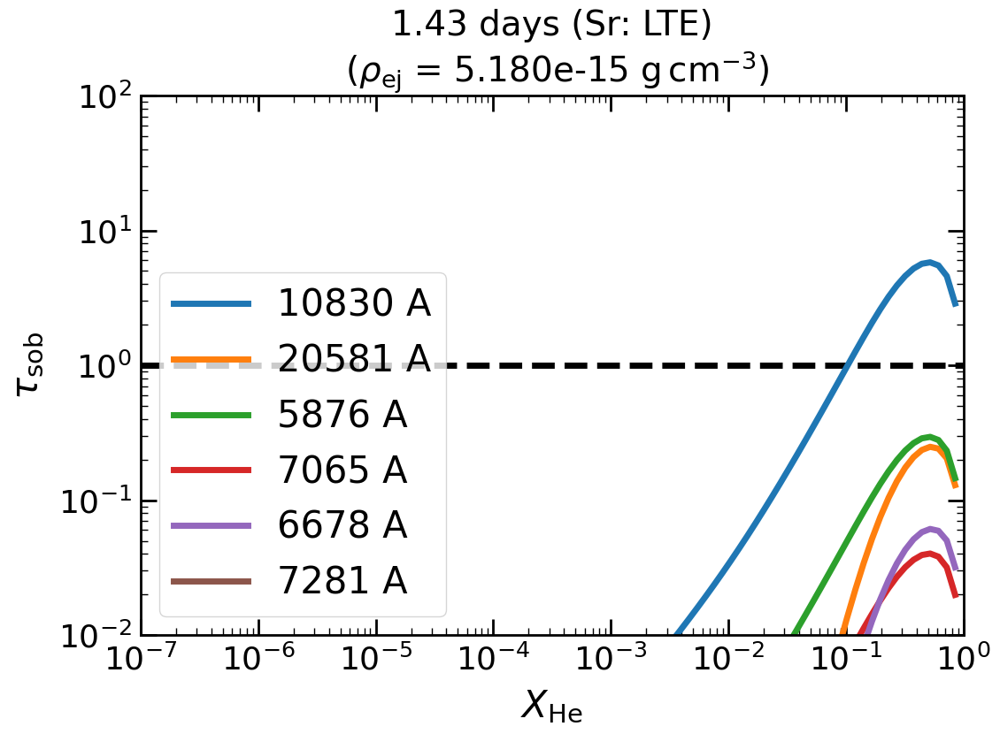

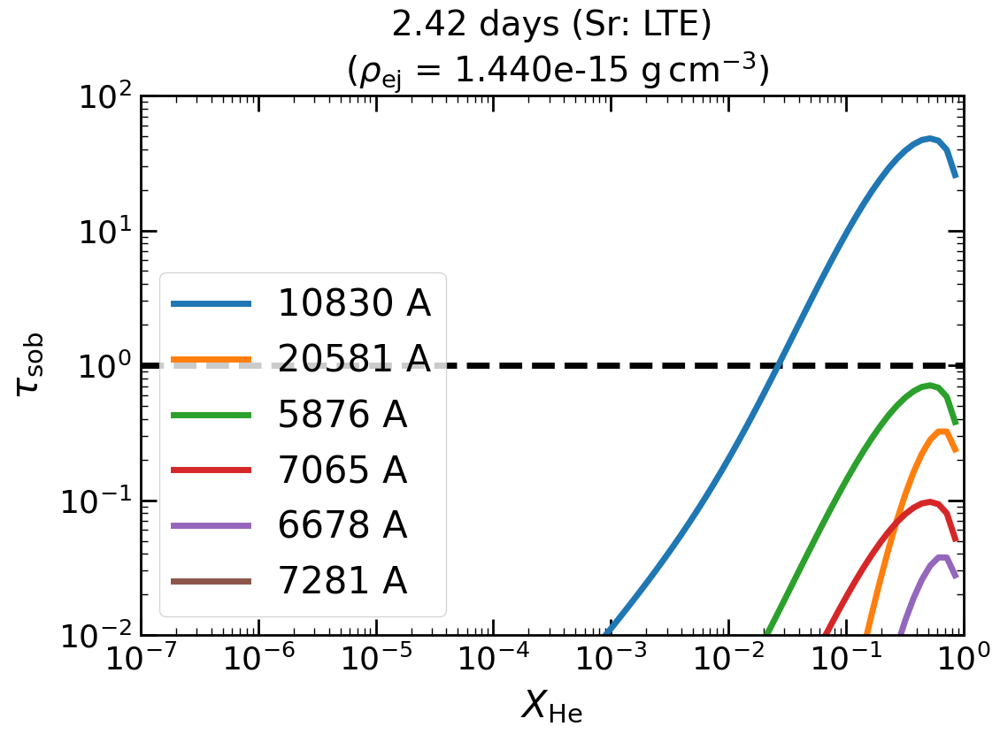

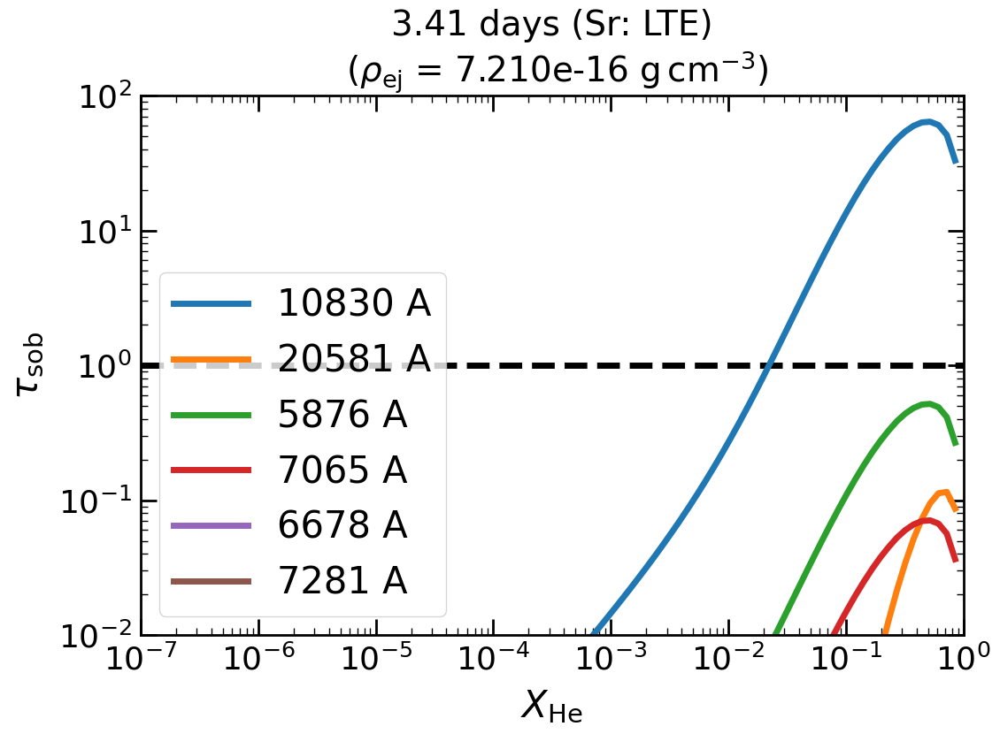

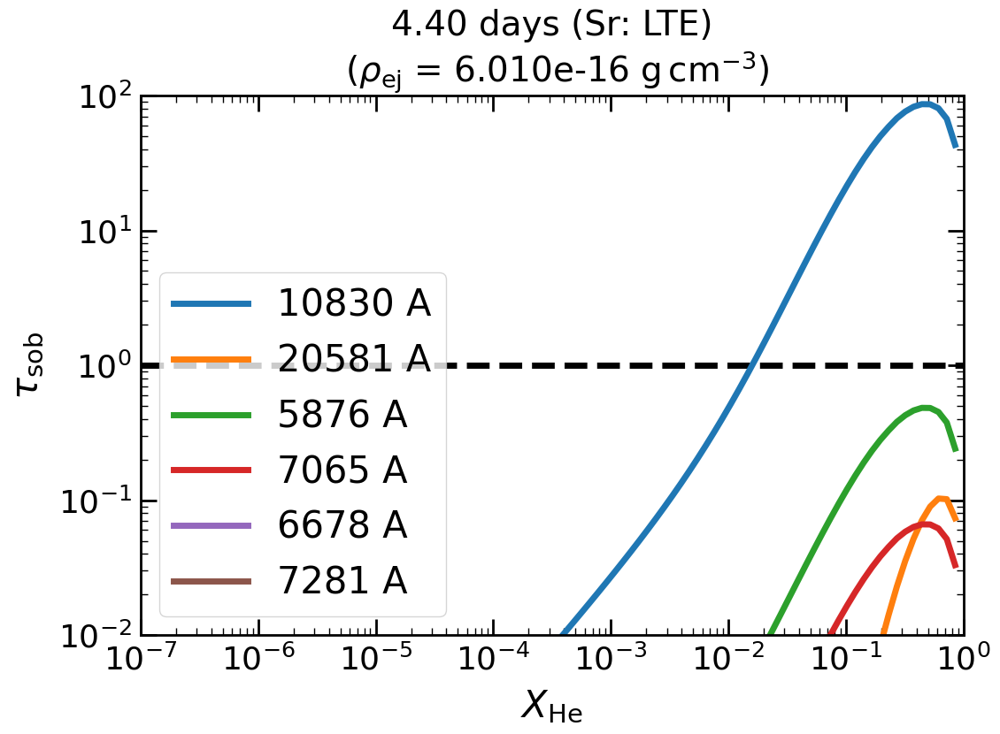

In [13]:
line_list_HeI = [
    ("23S", "23P", 1, 3, "10830"),
    ("21S", "21P", 2, 4, "20581"),
    ("23P", "33D", 3, 8, "5876"),
    ("23P", "33S", 3, 5, "7065"),
    ("21P", "31D", 4, 9, "6678"),
    ("21P", "31S", 4, 6, "7281")
    ]

for each_res in each_res_list_KC26_LTE:    
    npz_dir = Path(res_dir_KC26, each_res)
    fpath_nd = Path(npz_dir, f"nd_{each_res}.npz")
    npz_nd = np.load(fpath_nd)

    X_He_seq: npt.NDArray[np.float64] = npz_nd["X_He_seq"]
    t_expl_str = each_res.split('_')[0][:-1]
    t_expl = float(t_expl_str)*DAY
    rho_ej = float(each_res.split('_')[3][:-4])
    tem_e = float(each_res.split('_')[1][:-1])

    nd_res_He_pop = ma.array(npz_nd["nd_res_He_pop"]["_data"], mask=npz_nd["nd_res_He_pop"]["_mask"])
    nd_e_array = nd_res_He_pop[0]
    nd_res_He_levels = nd_res_He_pop[1:]

    fig, ax = plt.subplots(figsize=(12,9))

    ax.axhline(1.0, ls='--', lw=5, c='k')

    for term_l, term_u, idx_nd_l, idx_nd_u, wl_str in line_list_HeI:
        tau_He_array = calc_tau_l_HeI(term_l, term_u, nd_res_He_levels[idx_nd_l], nd_res_He_levels[idx_nd_u], t_expl)
        tau_He_seq = tau_He_array.mean(axis=0)
        ax.plot(X_He_seq, tau_He_seq, lw=5, label=f"{wl_str} A")

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(X_He_seq[0], X_He_seq[-1])
    ax.set_ylim(1e-2, 1e2)
    ax.set_xlabel(r"$X_\mathrm{He}$")
    ax.set_ylabel(r"$\tau_\mathrm{sob}$")
    ax.set_title(f"{t_expl_str} days (Sr: LTE)\n" + rf" ($\rho_\mathrm{{ej}}$ = {rho_ej:.3e} $\mathrm{{g\, cm^{{-3}}}}$)", fontsize=28)
    
    ax.legend(loc=3)

    fig.tight_layout()
    plt.show()


## Sr NLTE

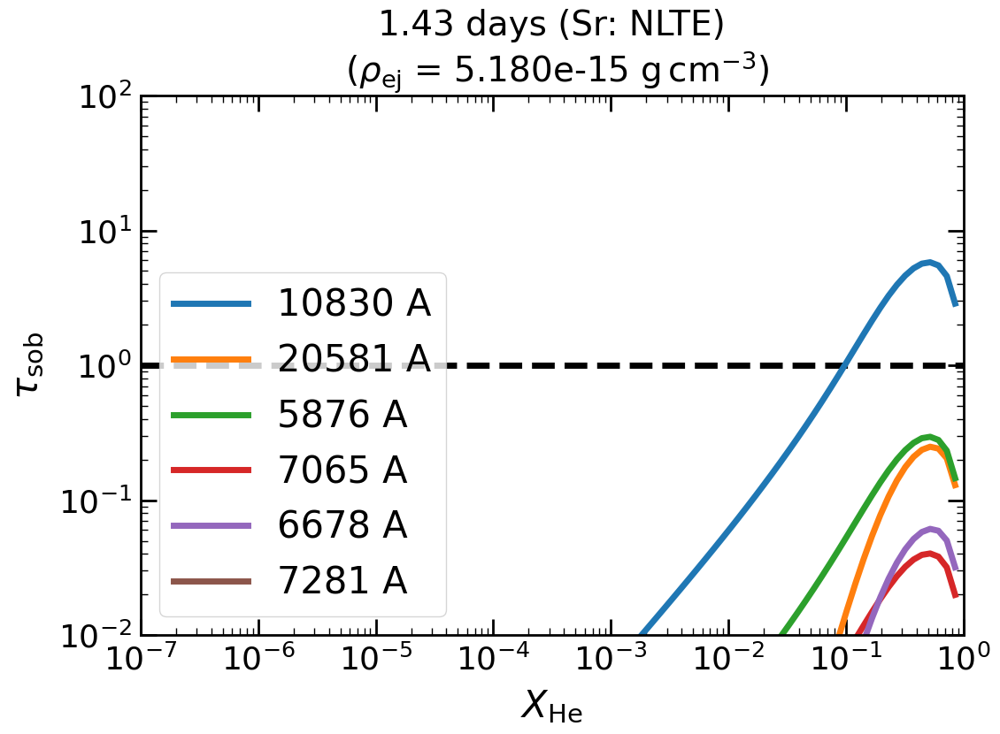

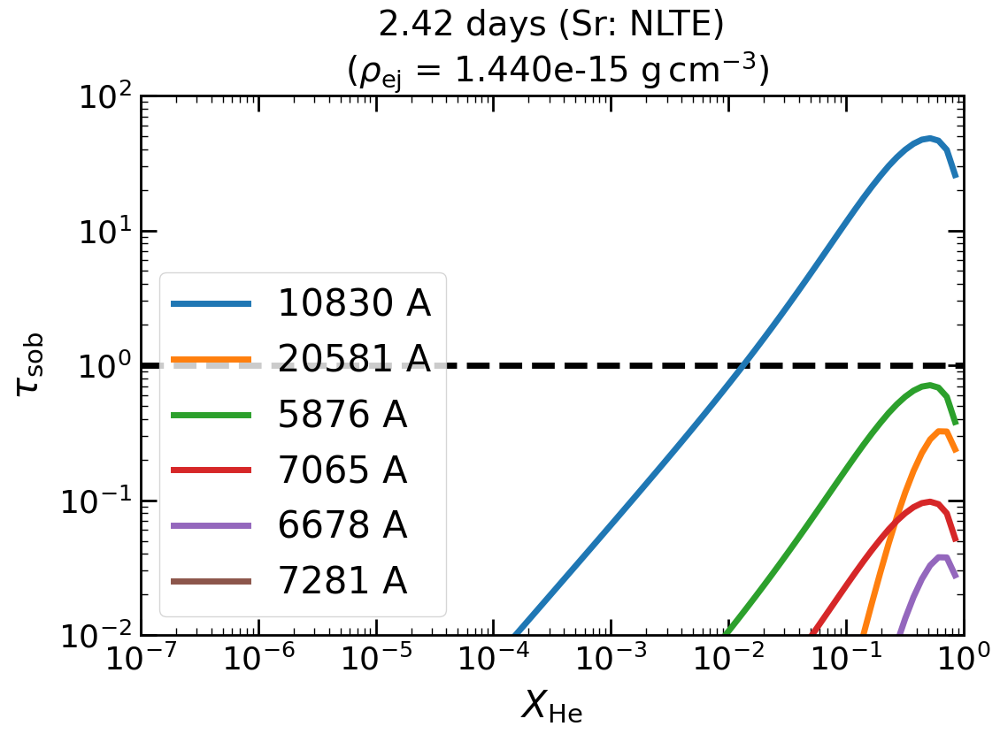

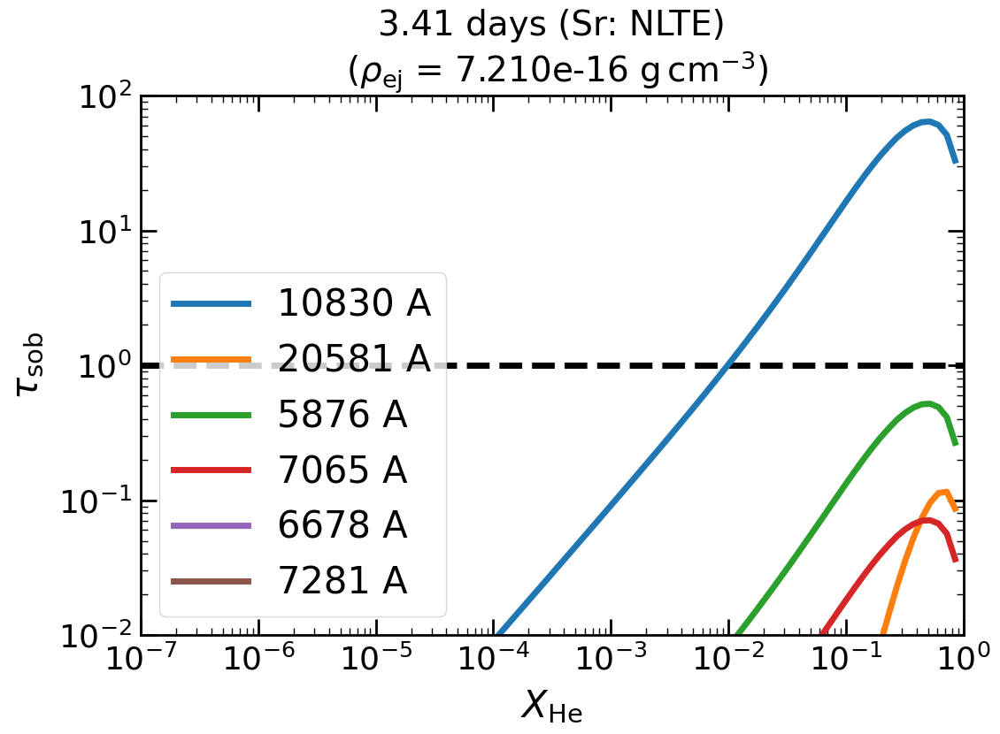

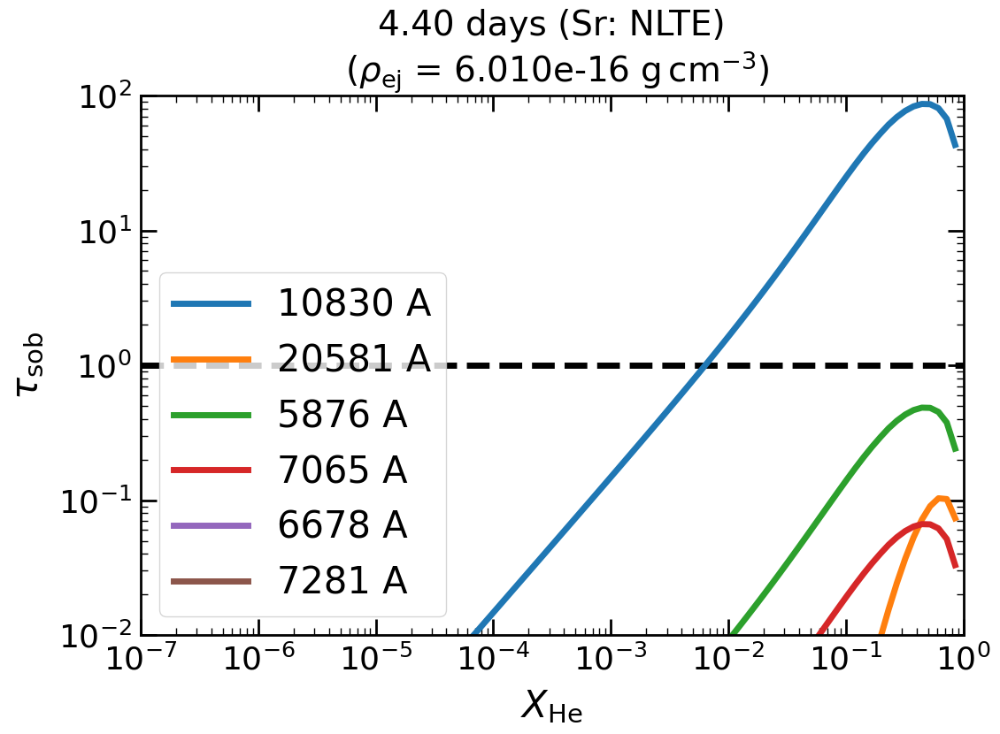

In [14]:
line_list_HeI = [
    ("23S", "23P", 1, 3, "10830"),
    ("21S", "21P", 2, 4, "20581"),
    ("23P", "33D", 3, 8, "5876"),
    ("23P", "33S", 3, 5, "7065"),
    ("21P", "31D", 4, 9, "6678"),
    ("21P", "31S", 4, 6, "7281")
    ]

for each_res in each_res_list_KC26_NLTE:    
    npz_dir = Path(res_dir_KC26, each_res)
    fpath_nd = Path(npz_dir, f"nd_{each_res}.npz")
    npz_nd = np.load(fpath_nd)

    X_He_seq: npt.NDArray[np.float64] = npz_nd["X_He_seq"]
    t_expl_str = each_res.split('_')[0][:-1]
    t_expl = float(t_expl_str)*DAY
    rho_ej = float(each_res.split('_')[3][:-4])
    tem_e = float(each_res.split('_')[1][:-1])

    nd_res_He_pop = ma.array(npz_nd["nd_res_He_pop"]["_data"], mask=npz_nd["nd_res_He_pop"]["_mask"])
    nd_e_array = nd_res_He_pop[0]
    nd_res_He_levels = nd_res_He_pop[1:]

    fig, ax = plt.subplots(figsize=(12,9))

    ax.axhline(1.0, ls='--', lw=5, c='k')

    for term_l, term_u, idx_nd_l, idx_nd_u, wl_str in line_list_HeI:
        tau_He_array = calc_tau_l_HeI(term_l, term_u, nd_res_He_levels[idx_nd_l], nd_res_He_levels[idx_nd_u], t_expl)
        tau_He_seq = tau_He_array.mean(axis=0)
        ax.plot(X_He_seq, tau_He_seq, lw=5, label=f"{wl_str} A")

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(X_He_seq[0], X_He_seq[-1])
    ax.set_ylim(1e-2, 1e2)
    ax.set_xlabel(r"$X_\mathrm{He}$")
    ax.set_ylabel(r"$\tau_\mathrm{sob}$")
    ax.set_title(f"{t_expl_str} days (Sr: NLTE)\n" + rf" ($\rho_\mathrm{{ej}}$ = {rho_ej:.3e} $\mathrm{{g\, cm^{{-3}}}}$)", fontsize=28)
    
    ax.legend(loc=3)

    fig.tight_layout()
    plt.show()


# Sr II lines

## Sr LTE

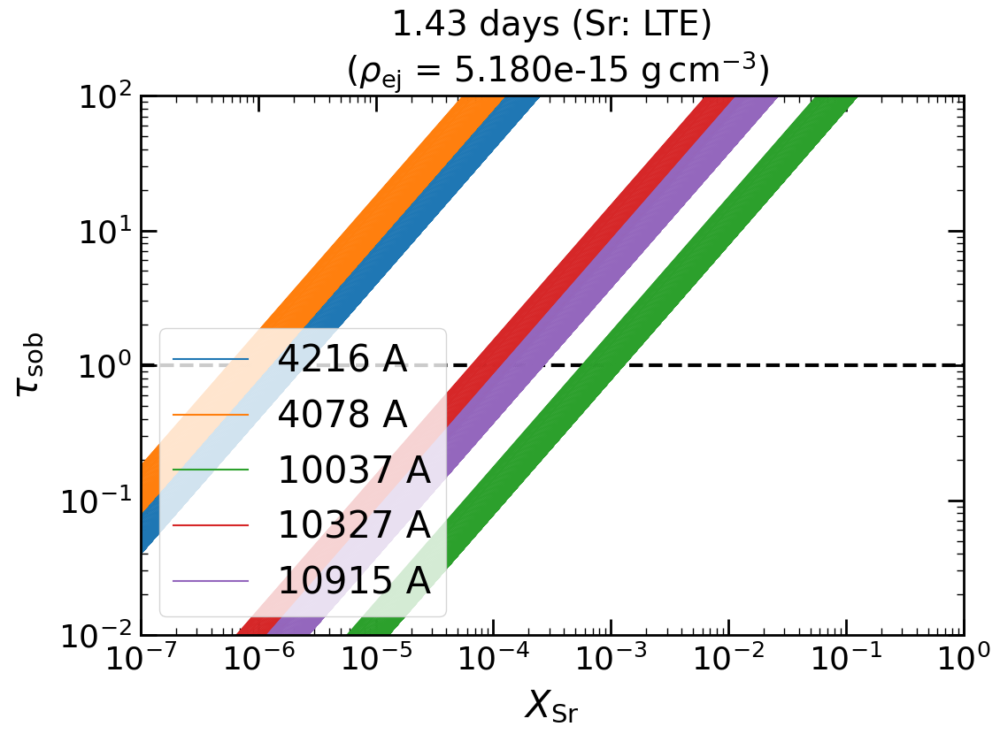

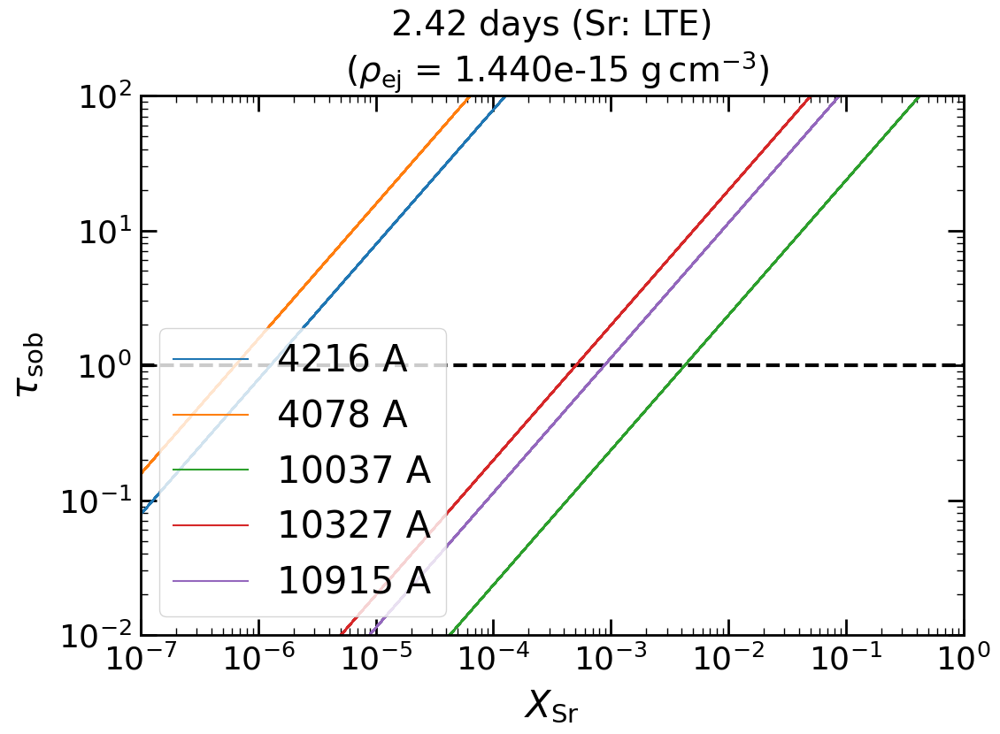

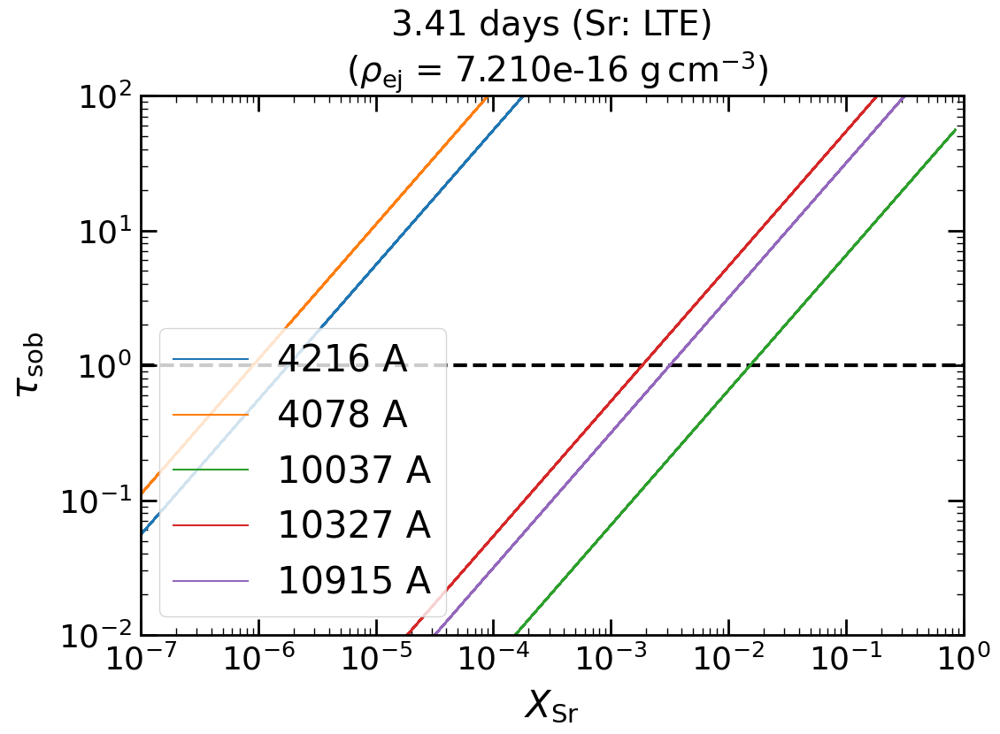

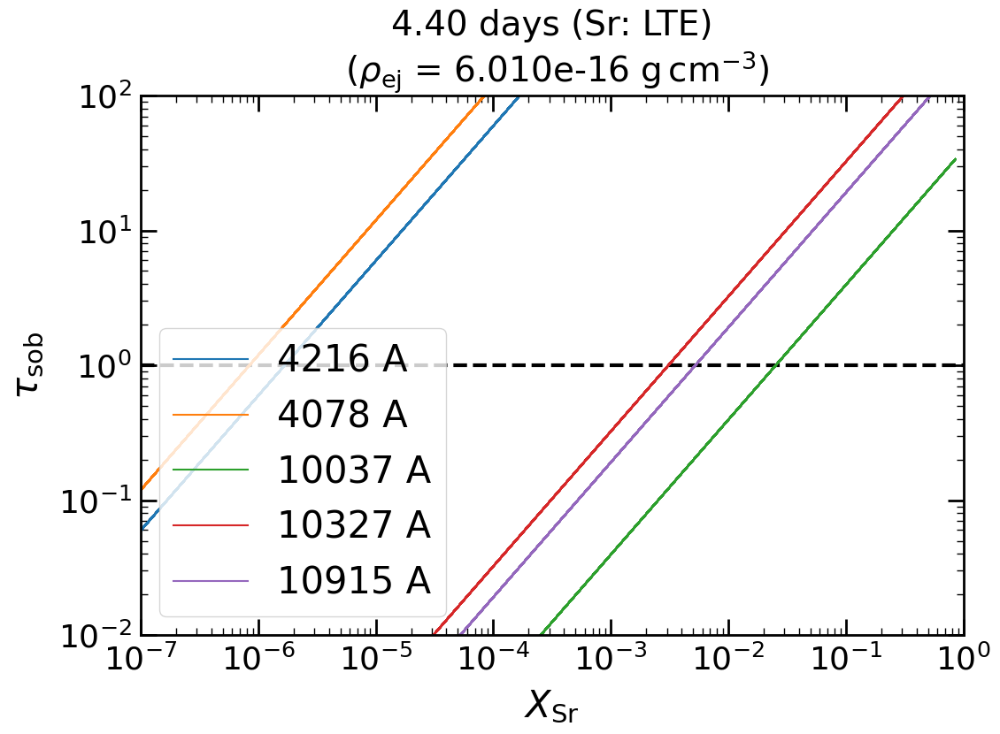

In [15]:
line_list_SrII = [
    ("5S1_2", "5P1_2", 1, 4, "4216"),
    ("5S1_2", "5P3_2", 1, 5, "4078"),
    ("4D3_2", "5P3_2", 2, 5, "10037"),
    ("4D5_2", "5P3_2", 3, 5, "10327"),
    ("4D3_2", "5P1_2", 2, 4, "10915")
    ]

for each_res in each_res_list_KC26_LTE:    
    npz_dir = Path(res_dir_KC26, each_res)
    fpath_nd = Path(npz_dir, f"nd_{each_res}.npz")
    npz_nd = np.load(fpath_nd)

    X_Sr_seq: npt.NDArray[np.float64] = npz_nd["X_Sr_seq"]
    t_expl_str = each_res.split('_')[0][:-1]
    t_expl = float(t_expl_str)*DAY
    rho_ej = float(each_res.split('_')[3][:-4])
    tem_e = float(each_res.split('_')[1][:-1])

    nd_res_Sr_pop = ma.array(npz_nd["nd_res_Sr_pop"]["_data"], mask=npz_nd["nd_res_Sr_pop"]["_mask"])

    fig, ax = plt.subplots(figsize=(12,9))

    ax.axhline(1.0, ls='--', lw=3, c='k')

    for idx_line, (term_l, term_u, idx_nd_l, idx_nd_u, wl_str) in enumerate(line_list_SrII):
        tau_Sr_array = calc_tau_l_SrII(idx_nd_l, idx_nd_u, nd_res_Sr_pop[1], t_expl, tem_e)
        ax.plot([], [], label=f"{wl_str} A")
        for tau_Sr_seq in tau_Sr_array.T:
            ax.plot(X_Sr_seq, tau_Sr_seq, c=f"C{idx_line}")

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(X_Sr_seq[0], X_Sr_seq[-1])
    ax.set_ylim(1e-2, 1e2)
    ax.set_xlabel(r"$X_\mathrm{Sr}$")
    ax.set_ylabel(r"$\tau_\mathrm{sob}$")
    ax.set_title(f"{t_expl_str} days (Sr: LTE)\n" + rf" ($\rho_\mathrm{{ej}}$ = {rho_ej:.3e} $\mathrm{{g\, cm^{{-3}}}}$)", fontsize=28)
    
    ax.legend(loc=3)

    fig.tight_layout()
    plt.show()


## Sr NLTE

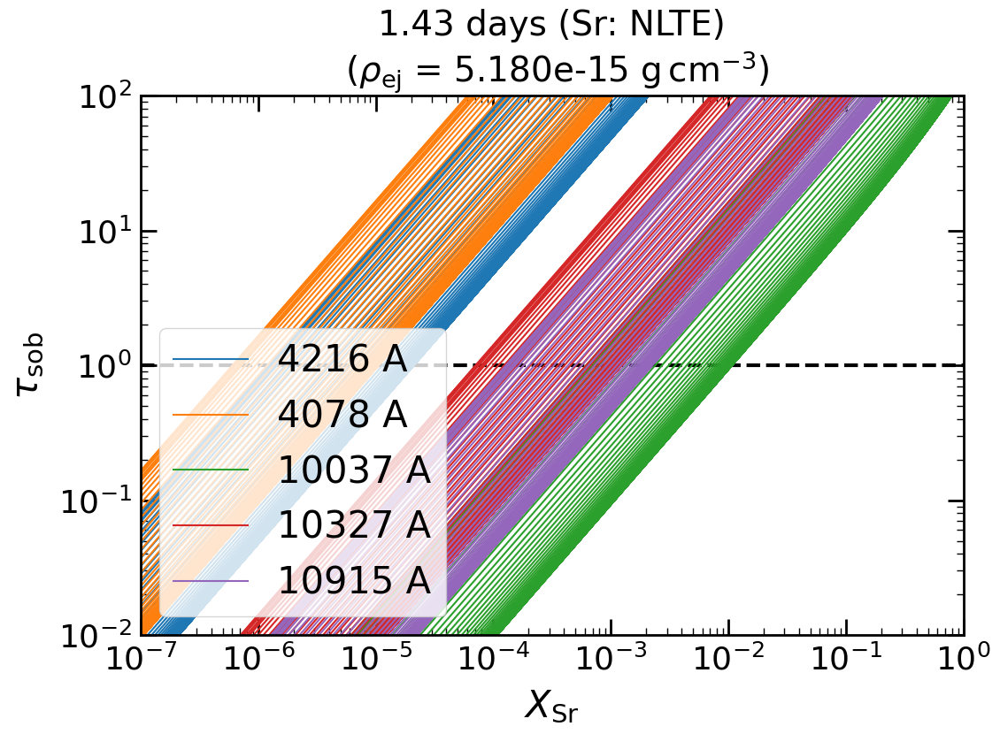

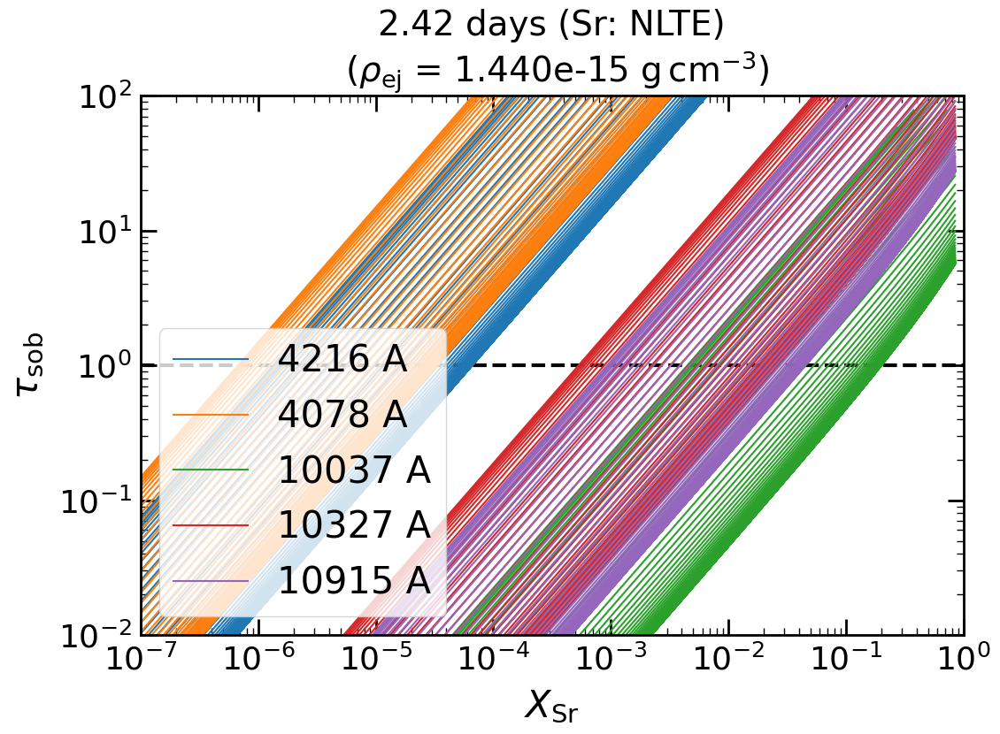

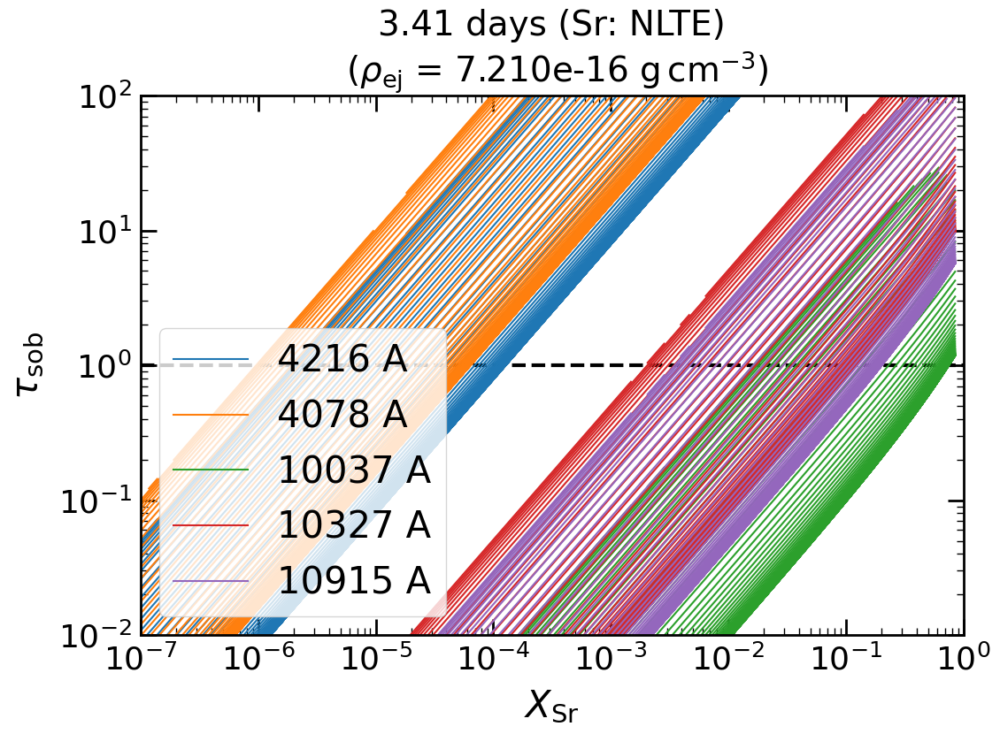

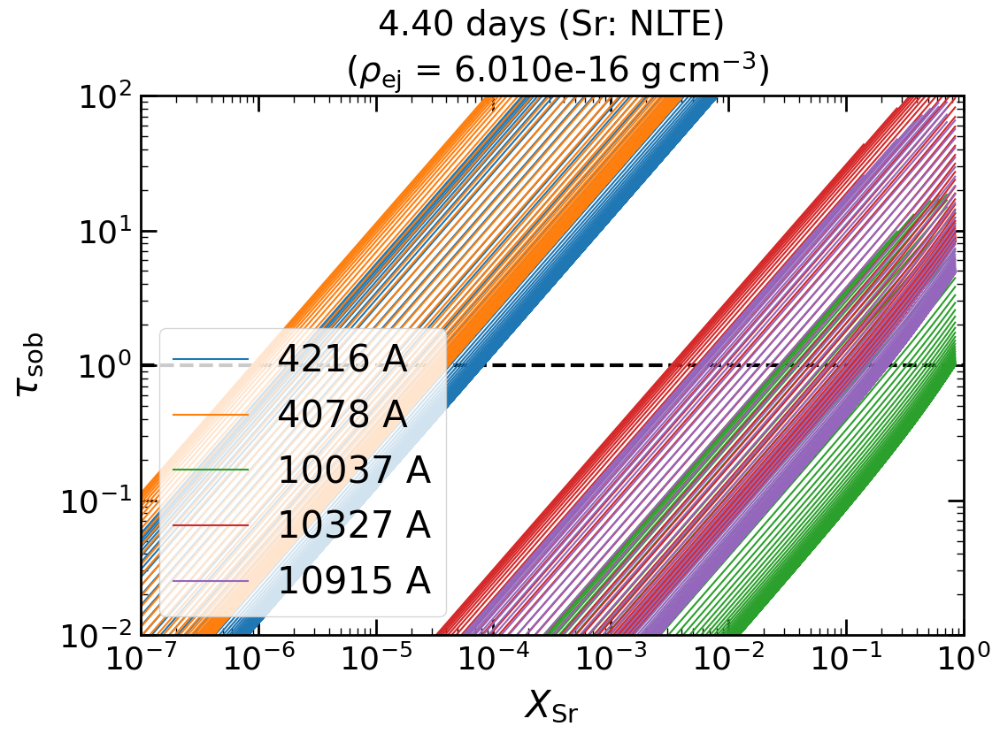

In [16]:
line_list_SrII = [
    ("5S1_2", "5P1_2", 1, 4, "4216"),
    ("5S1_2", "5P3_2", 1, 5, "4078"),
    ("4D3_2", "5P3_2", 2, 5, "10037"),
    ("4D5_2", "5P3_2", 3, 5, "10327"),
    ("4D3_2", "5P1_2", 2, 4, "10915")
    ]

for each_res in each_res_list_KC26_NLTE:    
    npz_dir = Path(res_dir_KC26, each_res)
    fpath_nd = Path(npz_dir, f"nd_{each_res}.npz")
    npz_nd = np.load(fpath_nd)

    X_Sr_seq: npt.NDArray[np.float64] = npz_nd["X_Sr_seq"]
    t_expl_str = each_res.split('_')[0][:-1]
    t_expl = float(t_expl_str)*DAY
    rho_ej = float(each_res.split('_')[3][:-4])
    tem_e = float(each_res.split('_')[1][:-1])

    nd_res_Sr_pop = ma.array(npz_nd["nd_res_Sr_pop"]["_data"], mask=npz_nd["nd_res_Sr_pop"]["_mask"])

    fig, ax = plt.subplots(figsize=(12,9))

    ax.axhline(1.0, ls='--', lw=3, c='k')

    for idx_line, (term_l, term_u, idx_nd_l, idx_nd_u, wl_str) in enumerate(line_list_SrII):
        tau_Sr_array = calc_tau_l_SrII(idx_nd_l, idx_nd_u, nd_res_Sr_pop[1], t_expl, tem_e)
        ax.plot([], [], label=f"{wl_str} A")
        for tau_Sr_seq in tau_Sr_array.T:
            ax.plot(X_Sr_seq, tau_Sr_seq, c=f"C{idx_line}")

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(X_Sr_seq[0], X_Sr_seq[-1])
    ax.set_ylim(1e-2, 1e2)
    ax.set_xlabel(r"$X_\mathrm{Sr}$")
    ax.set_ylabel(r"$\tau_\mathrm{sob}$")
    ax.set_title(f"{t_expl_str} days (Sr: NLTE)\n" + rf" ($\rho_\mathrm{{ej}}$ = {rho_ej:.3e} $\mathrm{{g\, cm^{{-3}}}}$)", fontsize=28)
    
    ax.legend(loc=3)

    fig.tight_layout()
    plt.show()


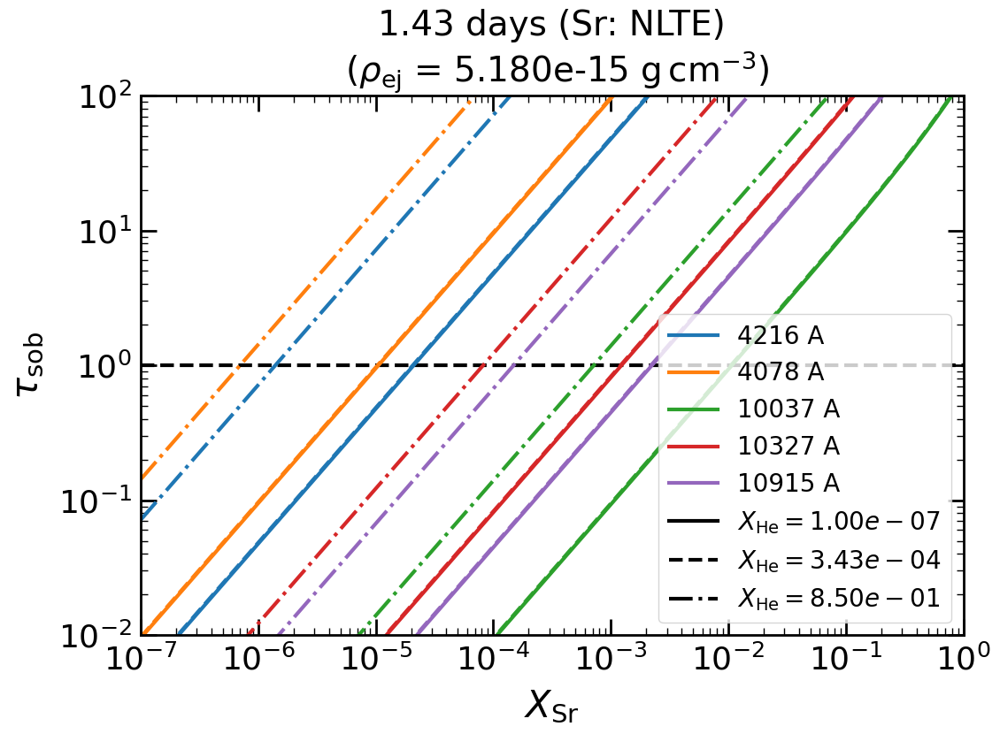

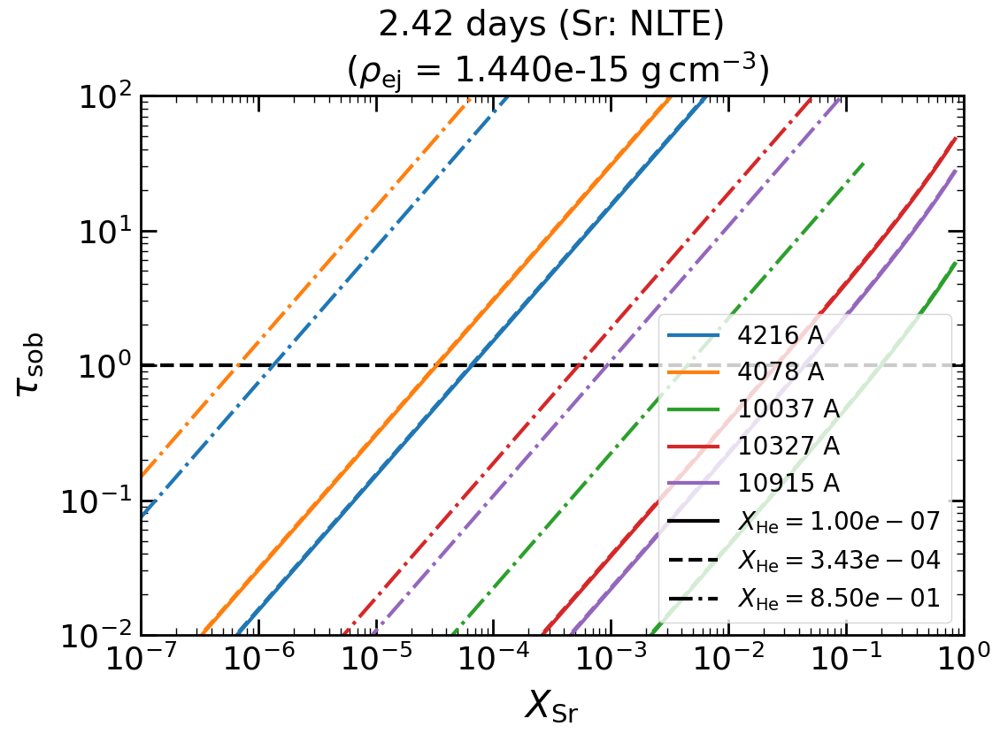

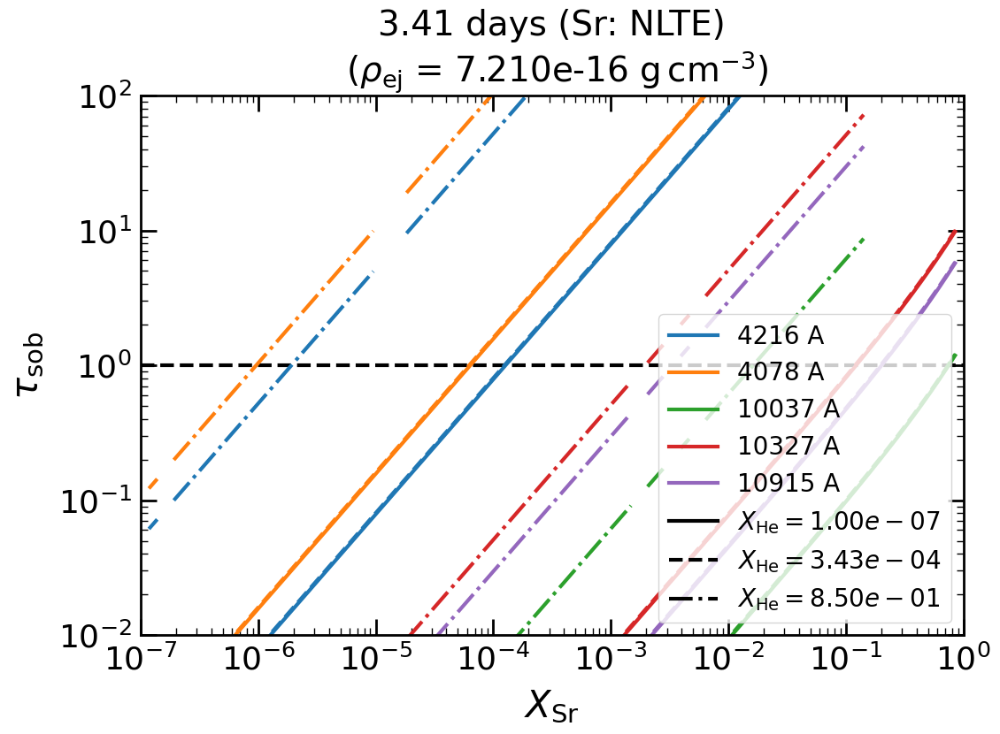

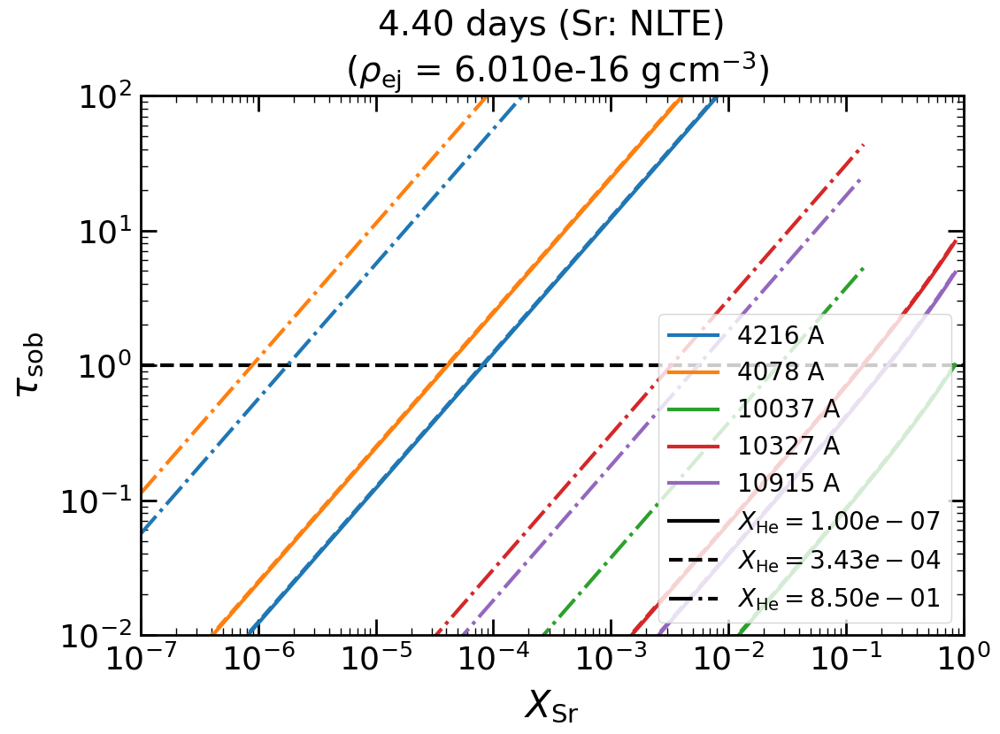

In [17]:
line_list_SrII = [
    ("5S1_2", "5P1_2", 1, 4, "4216"),
    ("5S1_2", "5P3_2", 1, 5, "4078"),
    ("4D3_2", "5P3_2", 2, 5, "10037"),
    ("4D5_2", "5P3_2", 3, 5, "10327"),
    ("4D3_2", "5P1_2", 2, 4, "10915")
    ]

for each_res in each_res_list_KC26_NLTE:    
    npz_dir = Path(res_dir_KC26, each_res)
    fpath_nd = Path(npz_dir, f"nd_{each_res}.npz")
    npz_nd = np.load(fpath_nd)

    X_Sr_seq: npt.NDArray[np.float64] = npz_nd["X_Sr_seq"]
    t_expl_str = each_res.split('_')[0][:-1]
    t_expl = float(t_expl_str)*DAY
    rho_ej = float(each_res.split('_')[3][:-4])
    tem_e = float(each_res.split('_')[1][:-1])

    nd_res_Sr_pop = ma.array(npz_nd["nd_res_Sr_pop"]["_data"], mask=npz_nd["nd_res_Sr_pop"]["_mask"])

    fig, ax = plt.subplots(figsize=(12,9))

    ax.axhline(1.0, ls='--', lw=3, c='k')

    # idx_X_He, ls
    plot_list = [
        (0, "-"),
        (X_He_seq.size//2, "--"),
        (-2, "-.")
    ]

    for idx_line, (term_l, term_u, idx_nd_l, idx_nd_u, wl_str) in enumerate(line_list_SrII):
        tau_Sr_array = calc_tau_l_SrII(idx_nd_l, idx_nd_u, nd_res_Sr_pop[1], t_expl, tem_e).T
        ax.plot([], [], lw=3, label=f"{wl_str} A")

        for idx_X_He, ls in plot_list:
            ax.plot(X_Sr_seq, tau_Sr_array[idx_X_He], ls=ls, lw=3, c=f"C{idx_line}")

    for idx_X_He, ls in plot_list:
        ax.plot([], [], ls=ls, c='k', lw=3, label=rf"$X_\mathrm{{He}} = {X_He_seq[idx_X_He]:.2e}$")


    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(X_Sr_seq[0], X_Sr_seq[-1])
    ax.set_ylim(1e-2, 1e2)
    ax.set_xlabel(r"$X_\mathrm{Sr}$")
    ax.set_ylabel(r"$\tau_\mathrm{sob}$")
    ax.set_title(f"{t_expl_str} days (Sr: NLTE)\n" + rf" ($\rho_\mathrm{{ej}}$ = {rho_ej:.3e} $\mathrm{{g\, cm^{{-3}}}}$)", fontsize=28)
    
    ax.legend(loc=4, fontsize=20)

    fig.tight_layout()
    plt.show()


# Free electron density

## Sr LTE

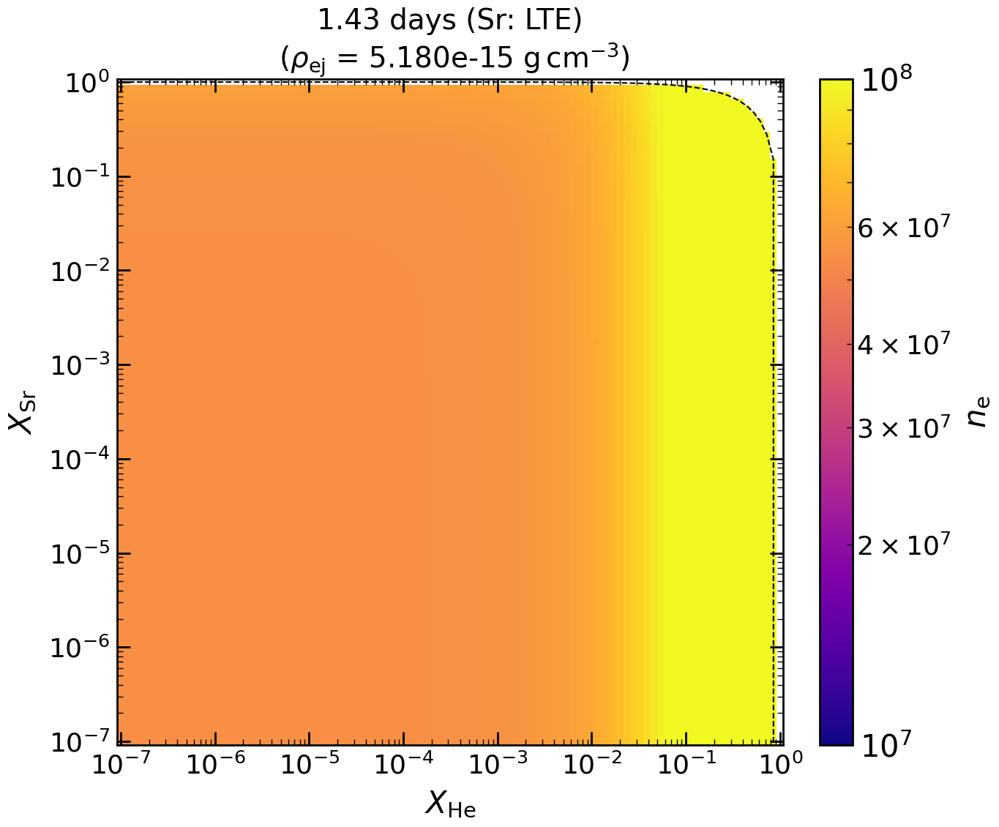

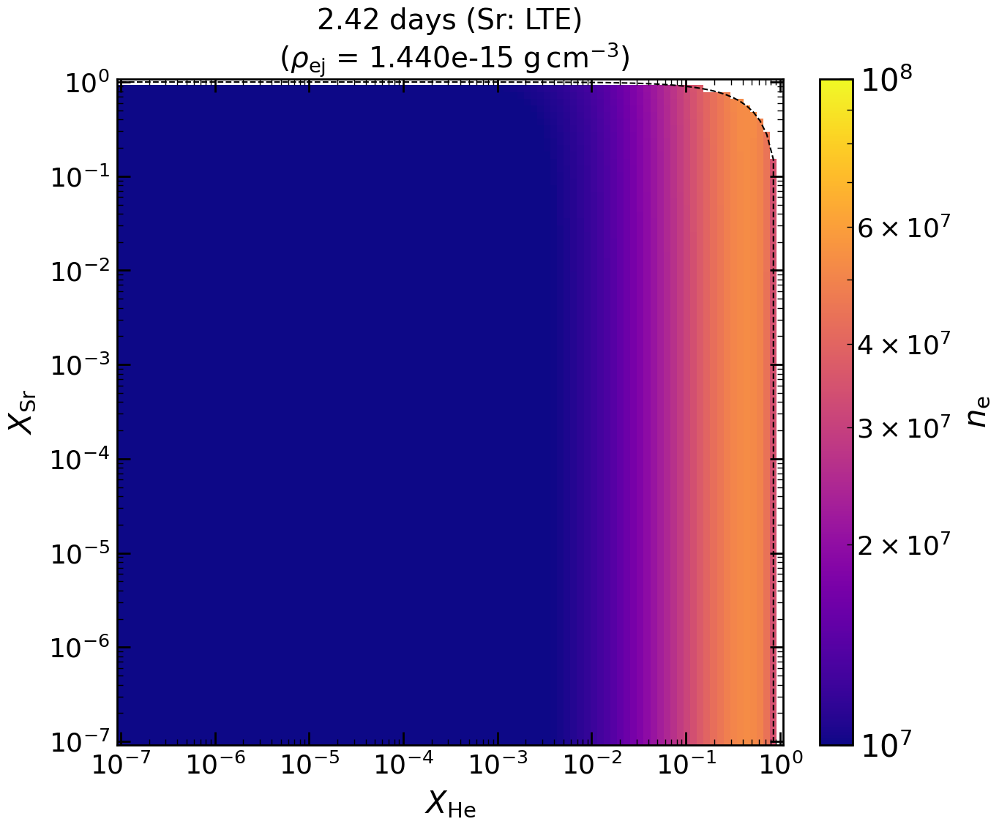

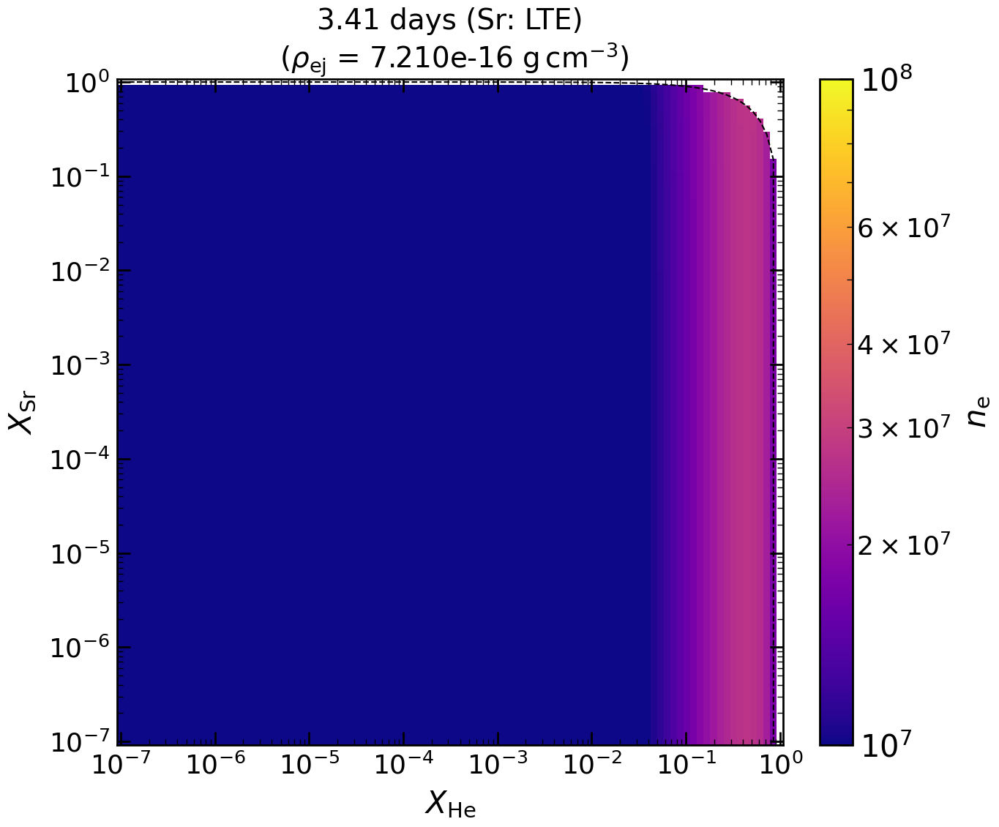

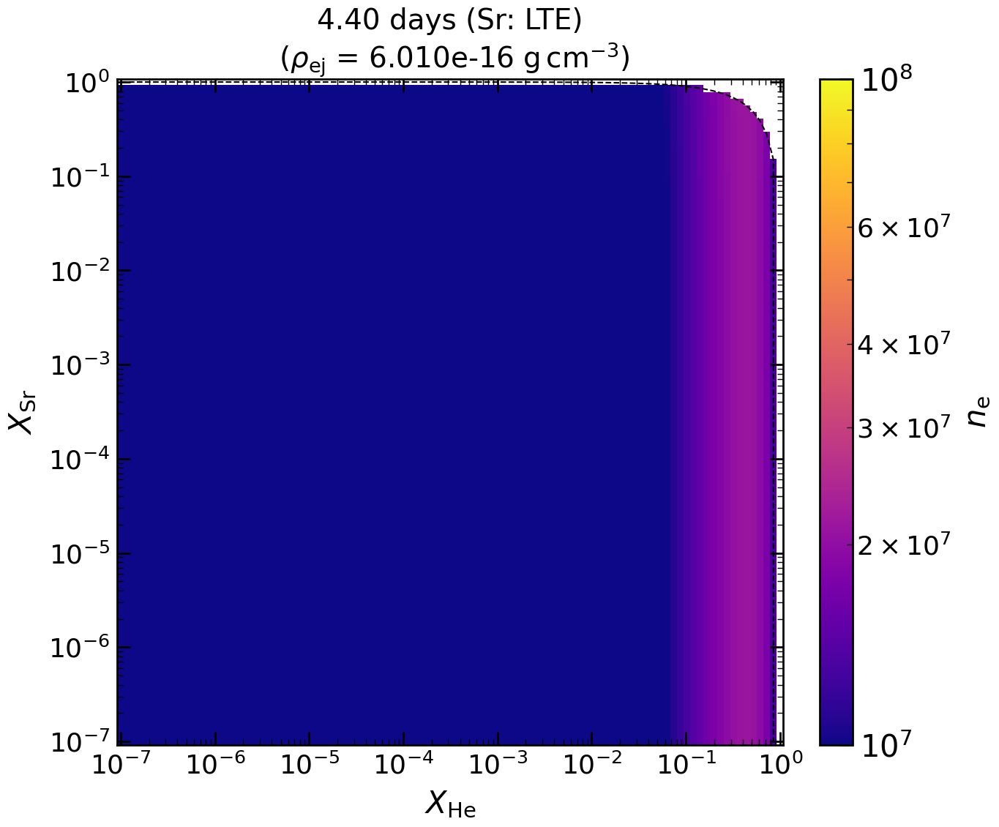

In [18]:
# energy of lower level, line wavelength, log gf
SrII_triplet_dict_v2 = {
    "4D3_2--5P3_2": (1.8047016, 10037.0, -1.22),
    "4D5_2--5P3_2": (1.8394593, 10327.0, -0.25),
    "4D3_2--5P1_2": (1.8047016, 10915.0, -0.574)
}

g_SrII_ground = 2
A_Sr = 88.0

for each_res in each_res_list_KC26_LTE:    
    npz_dir = Path(res_dir_KC26, each_res)
    fpath_nd = Path(npz_dir, f"nd_{each_res}.npz")
    npz_nd = np.load(fpath_nd)

    X_He_seq: npt.NDArray[np.float64] = npz_nd["X_He_seq"]
    X_Sr_seq: npt.NDArray[np.float64] = npz_nd["X_Sr_seq"]
    t_expl_str = each_res.split('_')[0][:-1]
    t_expl = float(t_expl_str)*DAY
    rho_ej = float(each_res.split('_')[3][:-4])
    tem_e = float(each_res.split('_')[1][:-1])

    nd_res_He_pop = ma.array(npz_nd["nd_res_He_pop"]["_data"], mask=npz_nd["nd_res_He_pop"]["_mask"])
    nd_e_array = nd_res_He_pop[0]

    fig, ax = plt.subplots(figsize=(14,12))

    ax.plot(X_He_seq, 1.0-X_He_seq, '--', c='k')

    mesh = ax.pcolormesh(X_He_seq, X_Sr_seq, nd_e_array, cmap='plasma', norm=LogNorm(1e7, 1e8), rasterized=True)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"$X_\mathrm{He}$")
    ax.set_ylabel(r"$X_\mathrm{Sr}$")
    ax.set_title(f"{t_expl_str} days (Sr: LTE)\n" + rf" ($\rho_\mathrm{{ej}}$ = {rho_ej:.3e} $\mathrm{{g\, cm^{{-3}}}}$)", fontsize=28)


    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.5)

    cbar = fig.colorbar(mesh, cax=cax)
    cbar.set_label(r"$n_\mathrm{e}$")
    cbar.ax.tick_params(labelsize="medium")

    ax.set_aspect("equal")    
    
    fig.tight_layout()
    plt.show()


## Sr NLTE

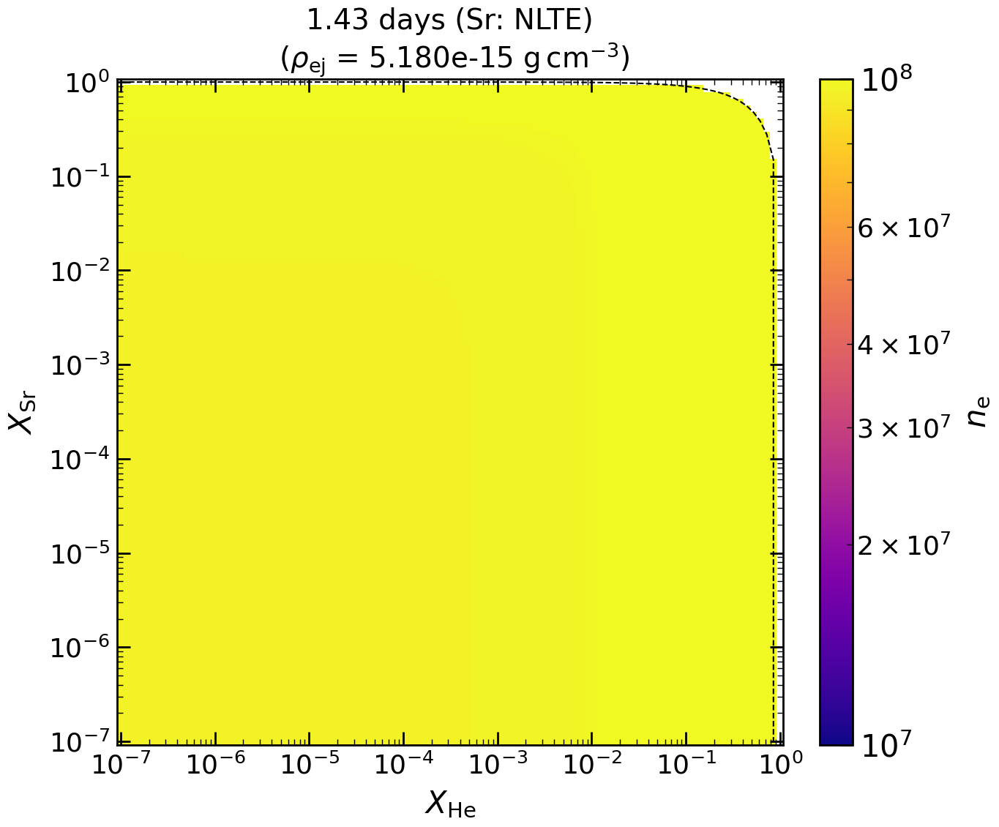

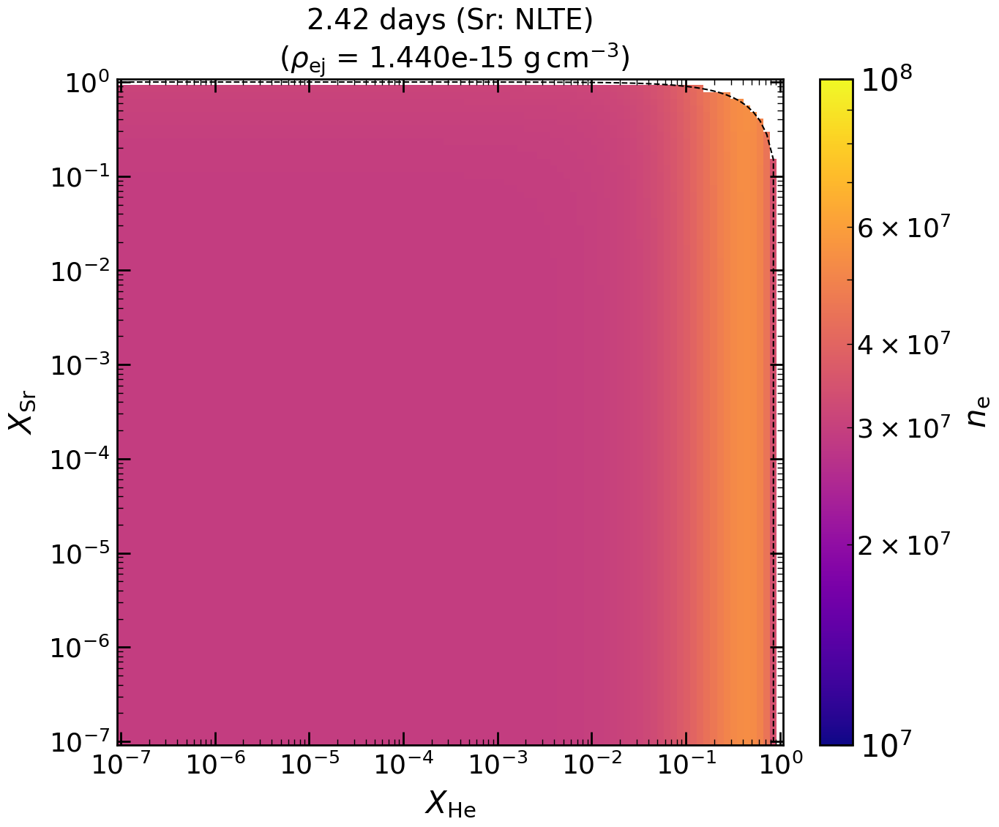

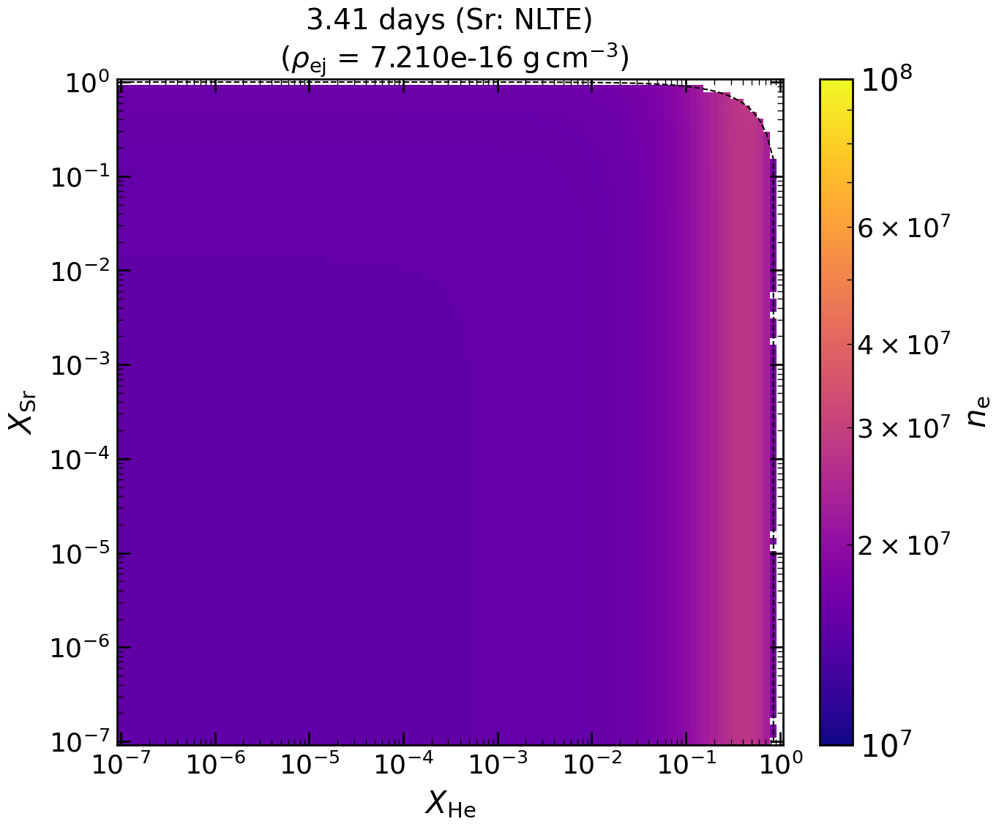

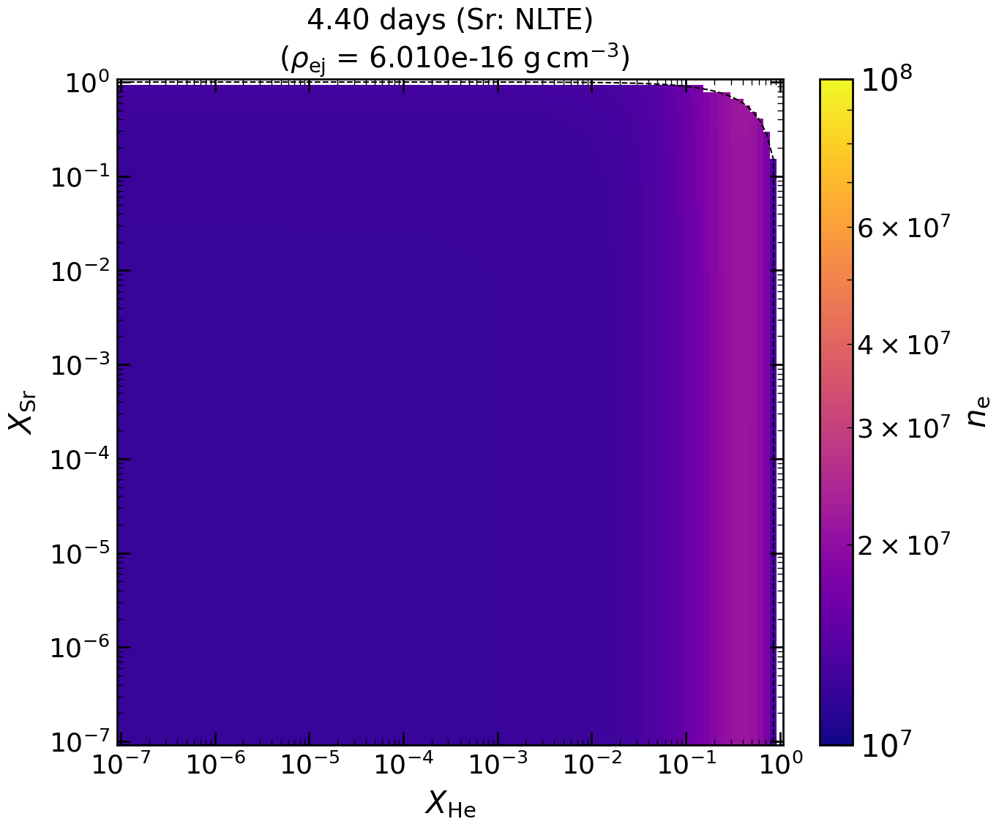

In [19]:
# energy of lower level, line wavelength, log gf
SrII_triplet_dict_v2 = {
    "4D3_2--5P3_2": (1.8047016, 10037.0, -1.22),
    "4D5_2--5P3_2": (1.8394593, 10327.0, -0.25),
    "4D3_2--5P1_2": (1.8047016, 10915.0, -0.574)
}

g_SrII_ground = 2
A_Sr = 88.0

for each_res in each_res_list_KC26_NLTE:    
    npz_dir = Path(res_dir_KC26, each_res)
    fpath_nd = Path(npz_dir, f"nd_{each_res}.npz")
    npz_nd = np.load(fpath_nd)

    X_He_seq: npt.NDArray[np.float64] = npz_nd["X_He_seq"]
    X_Sr_seq: npt.NDArray[np.float64] = npz_nd["X_Sr_seq"]
    t_expl_str = each_res.split('_')[0][:-1]
    t_expl = float(t_expl_str)*DAY
    rho_ej = float(each_res.split('_')[3][:-4])
    tem_e = float(each_res.split('_')[1][:-1])

    nd_res_He_pop = ma.array(npz_nd["nd_res_He_pop"]["_data"], mask=npz_nd["nd_res_He_pop"]["_mask"])
    nd_e_array = nd_res_He_pop[0]

    fig, ax = plt.subplots(figsize=(14,12))

    ax.plot(X_He_seq, 1.0-X_He_seq, '--', c='k')

    mesh = ax.pcolormesh(X_He_seq, X_Sr_seq, nd_e_array, cmap='plasma', norm=LogNorm(1e7, 1e8), rasterized=True)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"$X_\mathrm{He}$")
    ax.set_ylabel(r"$X_\mathrm{Sr}$")
    ax.set_title(f"{t_expl_str} days (Sr: NLTE)\n" + rf" ($\rho_\mathrm{{ej}}$ = {rho_ej:.3e} $\mathrm{{g\, cm^{{-3}}}}$)", fontsize=28)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.5)

    cbar = fig.colorbar(mesh, cax=cax)
    
    cbar.set_label(r"$n_\mathrm{e}$")    
    cbar.ax.tick_params(labelsize="medium")

    ax.set_aspect("equal")
    
    fig.tight_layout()
    plt.show()


# Ionization fraction of Sr II

## Sr LTE

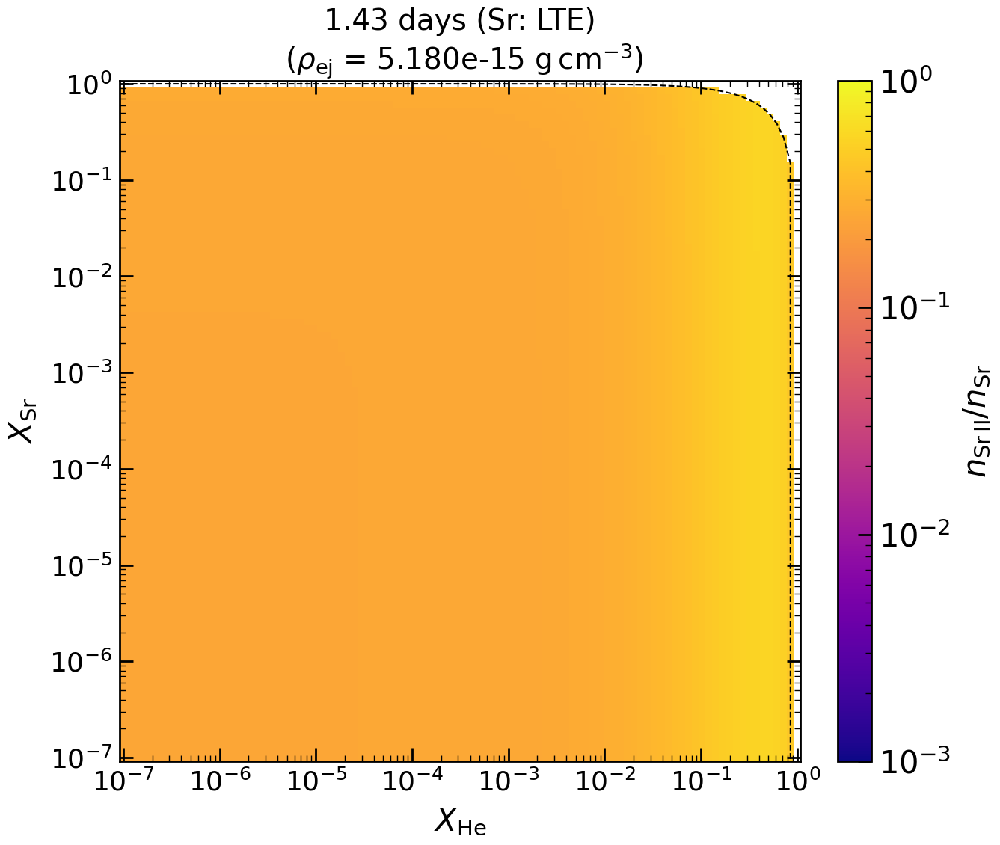

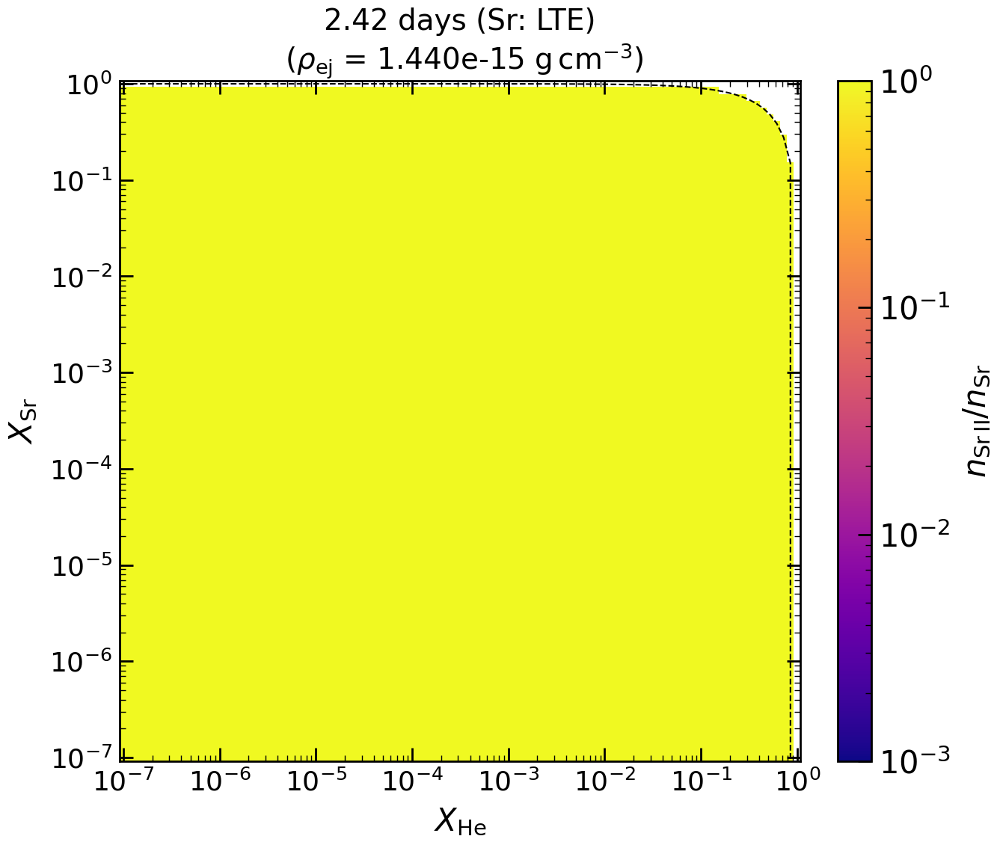

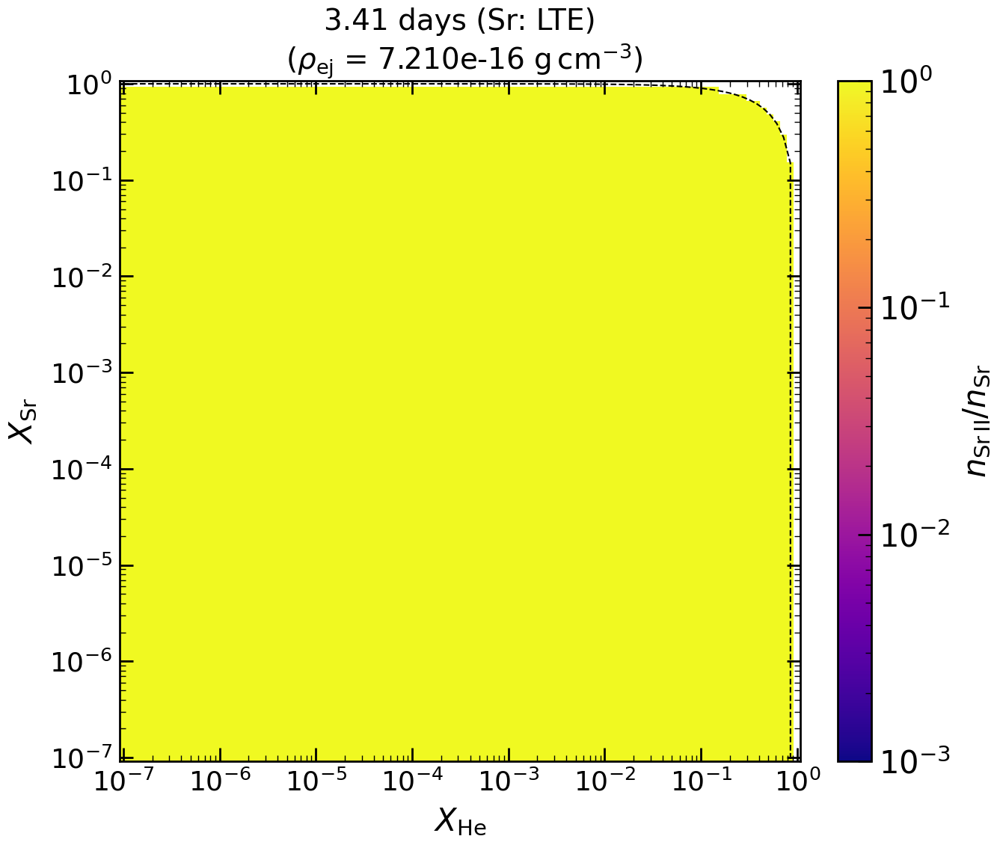

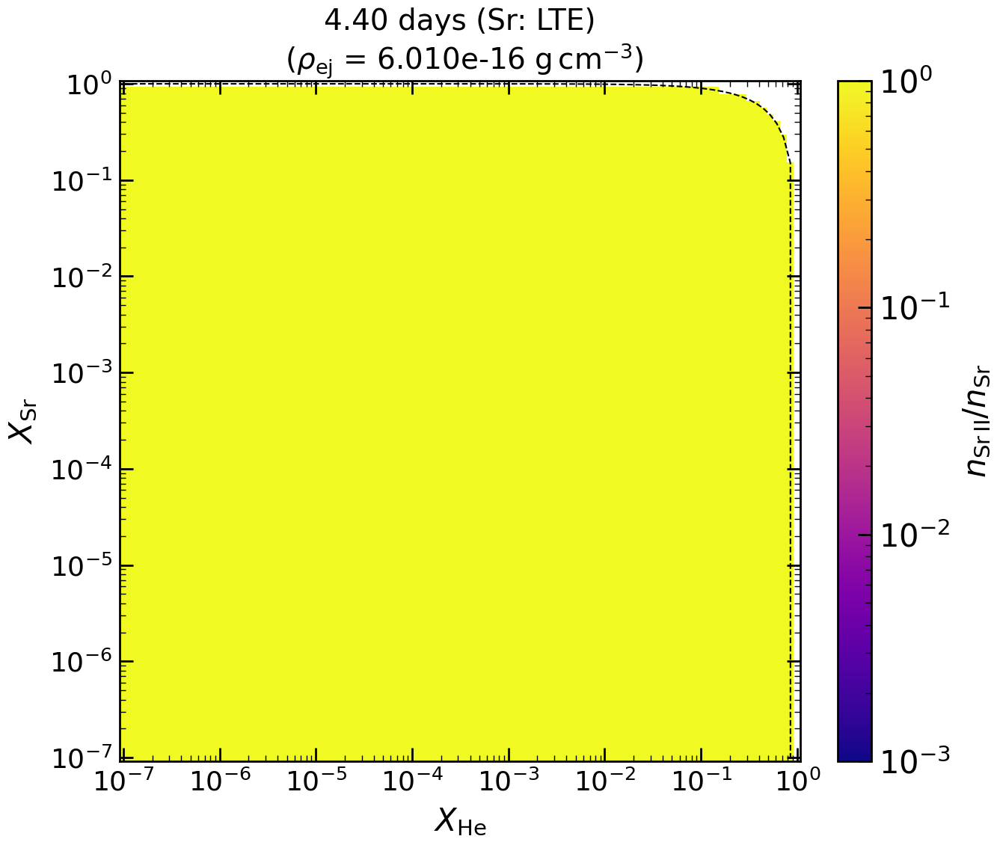

In [20]:
# energy of lower level, line wavelength, log gf
SrII_triplet_dict_v2 = {
    "4D3_2--5P3_2": (1.8047016, 10037.0, -1.22),
    "4D5_2--5P3_2": (1.8394593, 10327.0, -0.25),
    "4D3_2--5P1_2": (1.8047016, 10915.0, -0.574)
}

g_SrII_ground = 2
A_Sr = 88.0

for each_res in each_res_list_KC26_LTE:    
    npz_dir = Path(res_dir_KC26, each_res)
    fpath_nd = Path(npz_dir, f"nd_{each_res}.npz")
    npz_nd = np.load(fpath_nd)

    X_He_seq: npt.NDArray[np.float64] = npz_nd["X_He_seq"]
    X_Sr_seq: npt.NDArray[np.float64] = npz_nd["X_Sr_seq"]
    t_expl_str = each_res.split('_')[0][:-1]
    t_expl = float(t_expl_str)*DAY
    rho_ej = float(each_res.split('_')[3][:-4])
    tem_e = float(each_res.split('_')[1][:-1])

    # for Sr
    nd_res_Sr_pop = ma.array(npz_nd["nd_res_Sr_pop"]["_data"], mask=npz_nd["nd_res_Sr_pop"]["_mask"])
    nd_res_Sr_tot = nd_res_Sr_pop.sum(axis=0)
    frac_res_Sr_pop = nd_res_Sr_pop / nd_res_Sr_tot

    fig, ax = plt.subplots(figsize=(14,12))

    ax.plot(X_He_seq, 1.0-X_He_seq, '--', c='k')

    mesh = ax.pcolormesh(X_He_seq, X_Sr_seq, frac_res_Sr_pop[1], cmap='plasma', norm=LogNorm(vmin=1e-3, vmax=1), rasterized=True)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"$X_\mathrm{He}$")
    ax.set_ylabel(r"$X_\mathrm{Sr}$")
    ax.set_title(f"{t_expl_str} days (Sr: LTE)\n" + rf" ($\rho_\mathrm{{ej}}$ = {rho_ej:.3e} $\mathrm{{g\, cm^{{-3}}}}$)", fontsize=28)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.5)

    cbar = fig.colorbar(mesh, cax=cax)    
    cbar.set_label(r"$n_\mathrm{Sr\, II}/n_\mathrm{Sr}$")
    cbar.ax.tick_params(labelsize="medium")

    ax.set_aspect("equal")    
    
    fig.tight_layout()
    plt.show()

## Sr NLTE

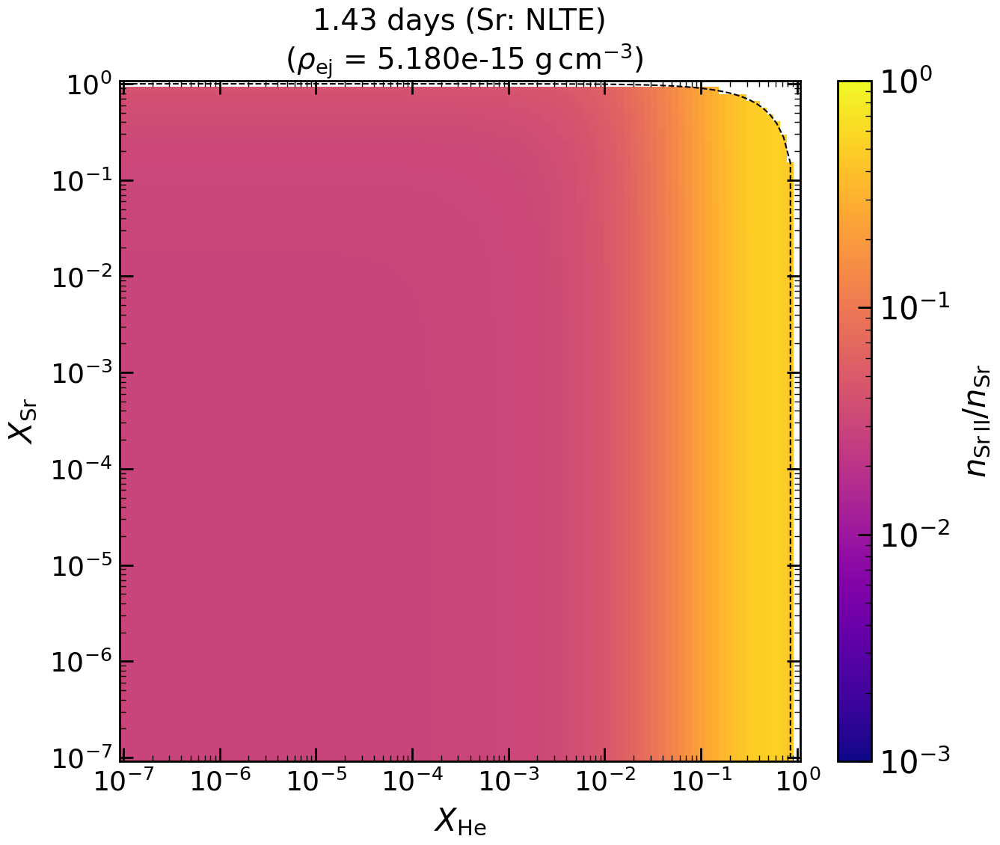

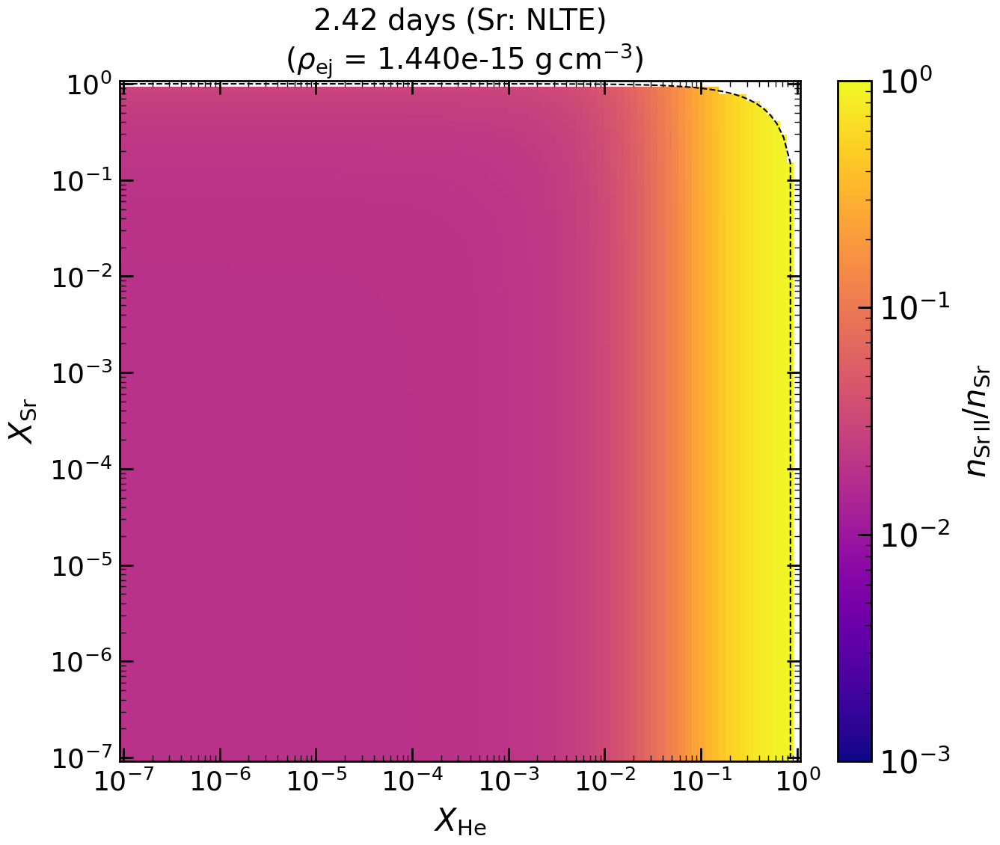

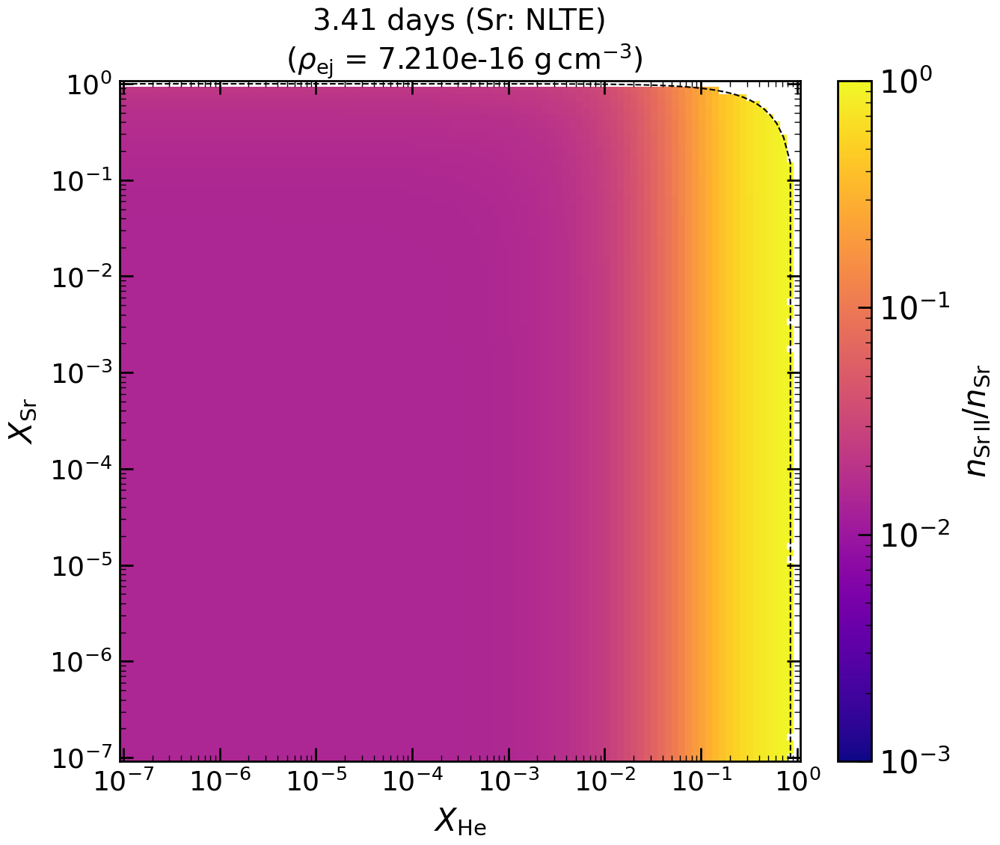

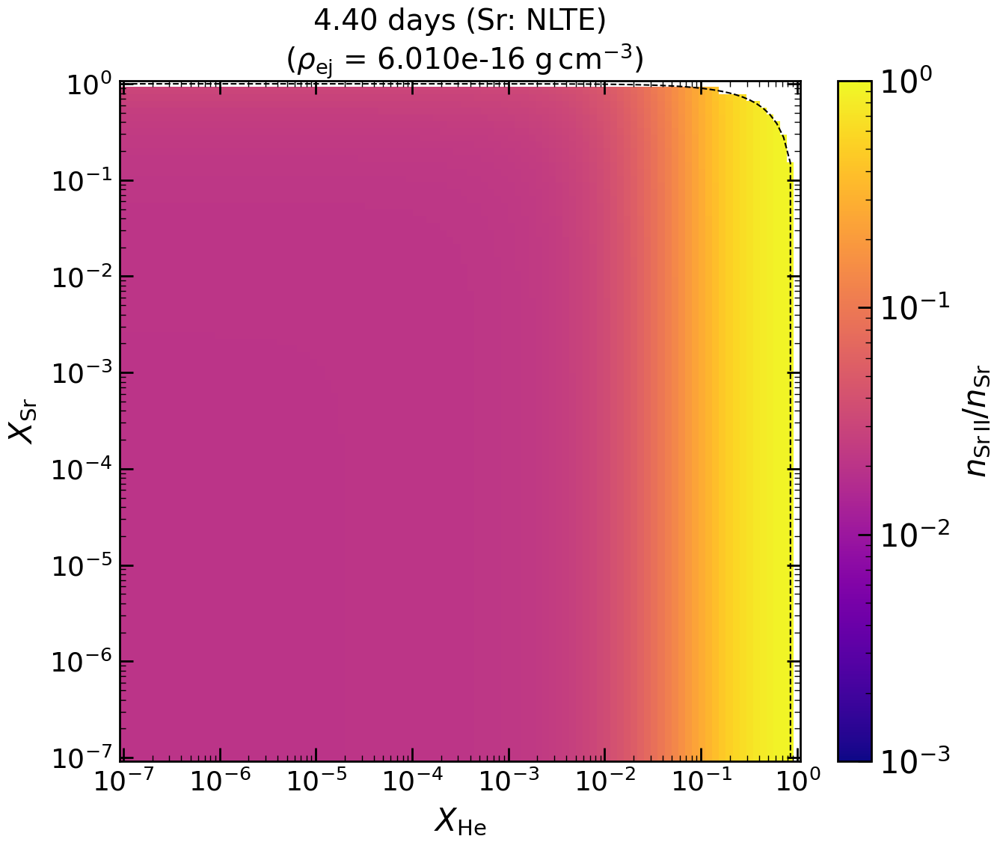

In [21]:
# energy of lower level, line wavelength, log gf
SrII_triplet_dict_v2 = {
    "4D3_2--5P3_2": (1.8047016, 10037.0, -1.22),
    "4D5_2--5P3_2": (1.8394593, 10327.0, -0.25),
    "4D3_2--5P1_2": (1.8047016, 10915.0, -0.574)
}

g_SrII_ground = 2
A_Sr = 88.0

for each_res in each_res_list_KC26_NLTE:    
    npz_dir = Path(res_dir_KC26, each_res)
    fpath_nd = Path(npz_dir, f"nd_{each_res}.npz")
    npz_nd = np.load(fpath_nd)

    X_He_seq: npt.NDArray[np.float64] = npz_nd["X_He_seq"]
    X_Sr_seq: npt.NDArray[np.float64] = npz_nd["X_Sr_seq"]
    t_expl_str = each_res.split('_')[0][:-1]
    t_expl = float(t_expl_str)*DAY
    rho_ej = float(each_res.split('_')[3][:-4])
    tem_e = float(each_res.split('_')[1][:-1])

    # for Sr
    nd_res_Sr_pop = ma.array(npz_nd["nd_res_Sr_pop"]["_data"], mask=npz_nd["nd_res_Sr_pop"]["_mask"])
    nd_res_Sr_tot = nd_res_Sr_pop.sum(axis=0)
    frac_res_Sr_pop = nd_res_Sr_pop / nd_res_Sr_tot

    fig, ax = plt.subplots(figsize=(14,12))

    ax.plot(X_He_seq, 1.0-X_He_seq, '--', c='k')

    mesh = ax.pcolormesh(X_He_seq, X_Sr_seq, frac_res_Sr_pop[1], cmap='plasma', norm=LogNorm(vmin=1e-3, vmax=1), rasterized=True)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"$X_\mathrm{He}$")
    ax.set_ylabel(r"$X_\mathrm{Sr}$")
    ax.set_title(f"{t_expl_str} days (Sr: NLTE)\n" + rf" ($\rho_\mathrm{{ej}}$ = {rho_ej:.3e} $\mathrm{{g\, cm^{{-3}}}}$)", fontsize=28)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.5)

    cbar = fig.colorbar(mesh, cax=cax)
    cbar.set_label(r"$n_\mathrm{Sr\, II}/n_\mathrm{Sr}$")
    cbar.ax.tick_params(labelsize="medium")

    ax.set_aspect("equal")
    
    fig.tight_layout()
    plt.show()

# Average ionization stage of Sr

## Sr LTE

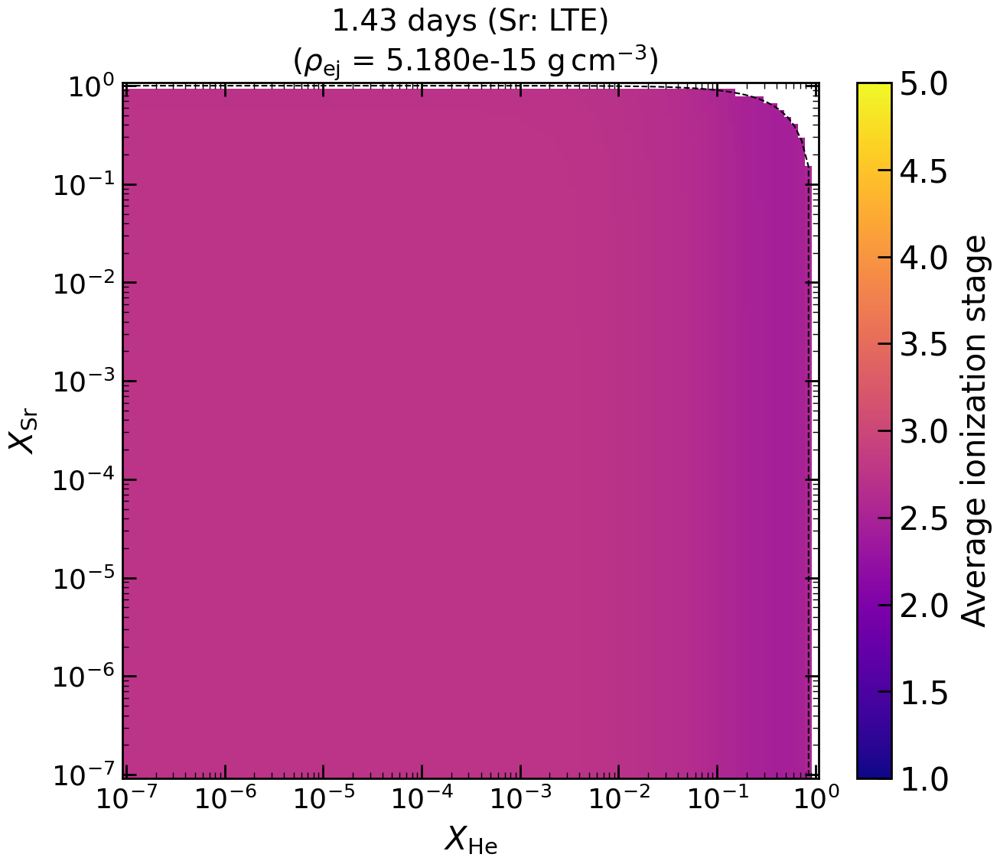

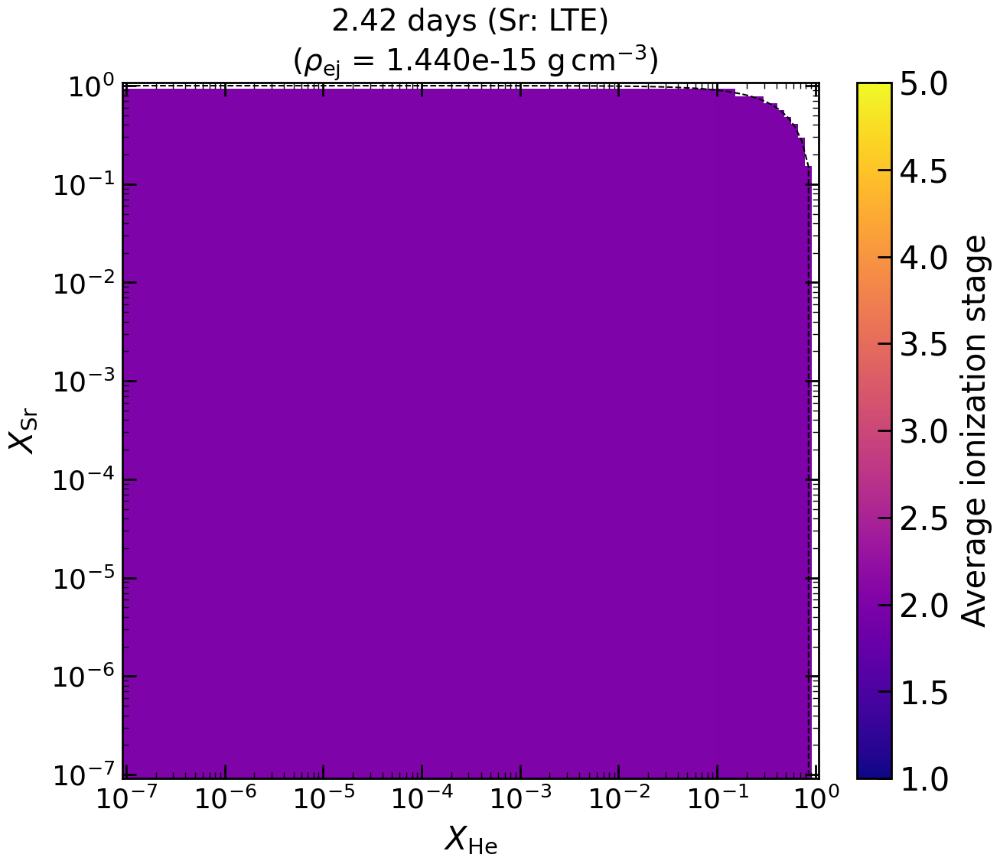

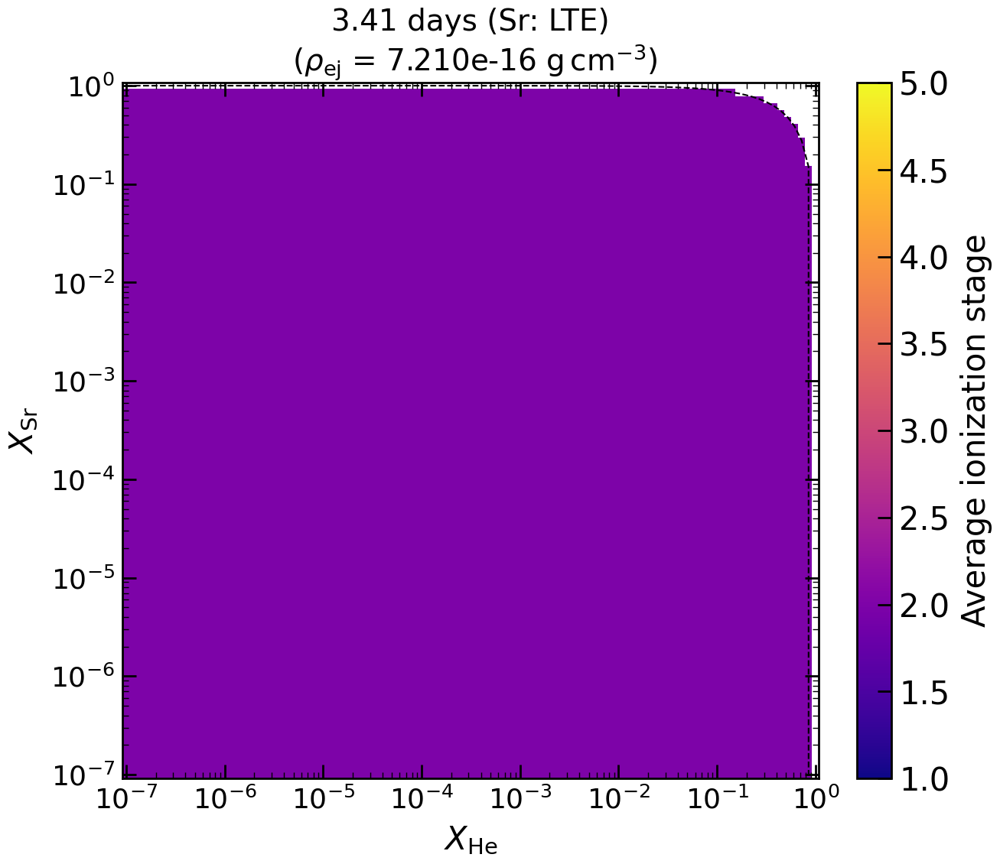

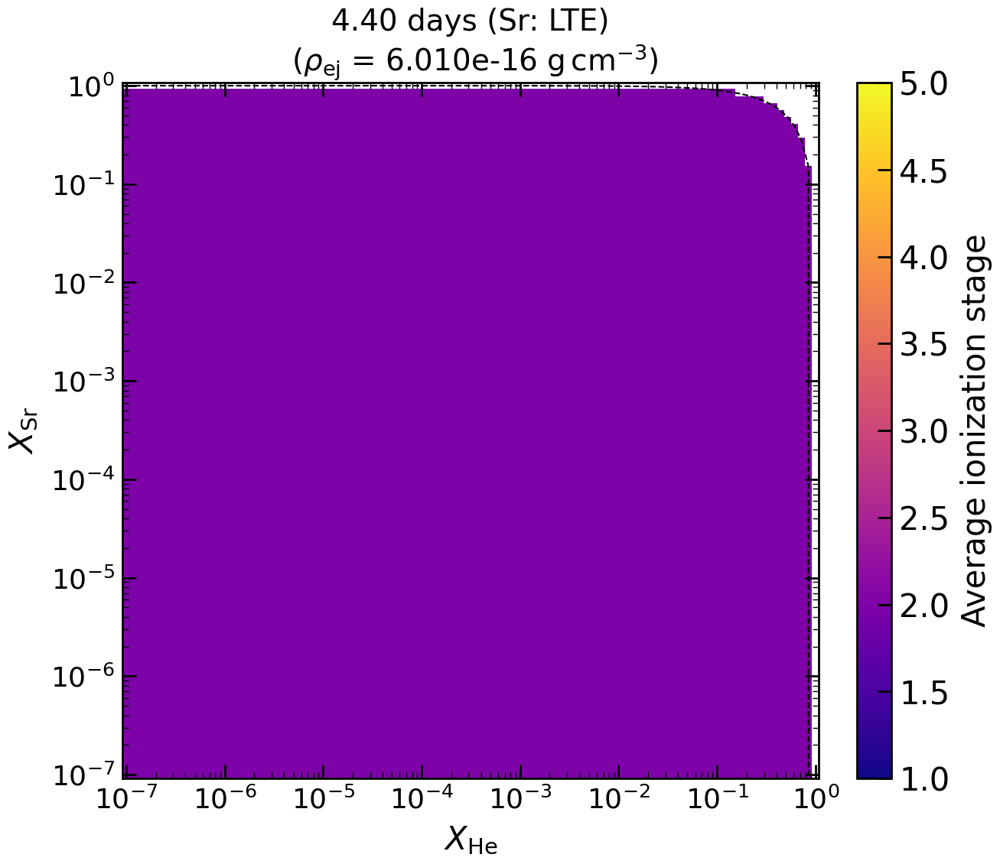

In [22]:
# energy of lower level, line wavelength, log gf
SrII_triplet_dict_v2 = {
    "4D3_2--5P3_2": (1.8047016, 10037.0, -1.22),
    "4D5_2--5P3_2": (1.8394593, 10327.0, -0.25),
    "4D3_2--5P1_2": (1.8047016, 10915.0, -0.574)
}

g_SrII_ground = 2
A_Sr = 88.0

for each_res in each_res_list_KC26_LTE:    
    npz_dir = Path(res_dir_KC26, each_res)
    fpath_nd = Path(npz_dir, f"nd_{each_res}.npz")
    npz_nd = np.load(fpath_nd)

    X_He_seq: npt.NDArray[np.float64] = npz_nd["X_He_seq"]
    X_Sr_seq: npt.NDArray[np.float64] = npz_nd["X_Sr_seq"]
    t_expl_str = each_res.split('_')[0][:-1]
    t_expl = float(t_expl_str)*DAY
    rho_ej = float(each_res.split('_')[3][:-4])
    tem_e = float(each_res.split('_')[1][:-1])

    # for Sr
    nd_res_Sr_pop = ma.array(npz_nd["nd_res_Sr_pop"]["_data"], mask=npz_nd["nd_res_Sr_pop"]["_mask"])
    nd_res_Sr_tot = nd_res_Sr_pop.sum(axis=0)
    frac_res_Sr_pop = nd_res_Sr_pop / nd_res_Sr_tot

    ion_stage_seq = np.arange(frac_res_Sr_pop.shape[0]) + 1
    ion_degree_array = (ion_stage_seq[:, np.newaxis, np.newaxis] * frac_res_Sr_pop).sum(axis=0)

    fig, ax = plt.subplots(figsize=(14,12))

    ax.plot(X_He_seq, 1.0-X_He_seq, '--', c='k')

    mesh = ax.pcolormesh(X_He_seq, X_Sr_seq, ion_degree_array, cmap='plasma', vmin=1, vmax=5, rasterized=True)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"$X_\mathrm{He}$")
    ax.set_ylabel(r"$X_\mathrm{Sr}$")
    ax.set_title(f"{t_expl_str} days (Sr: LTE)\n" + rf" ($\rho_\mathrm{{ej}}$ = {rho_ej:.3e} $\mathrm{{g\, cm^{{-3}}}}$)", fontsize=28)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.5)

    cbar = fig.colorbar(mesh, cax=cax)
    cbar.set_label("Average ionization stage")

    cbar.ax.tick_params(labelsize="medium")

    ax.set_aspect("equal")
    
    fig.tight_layout()
    plt.show()

## Sr NLTE

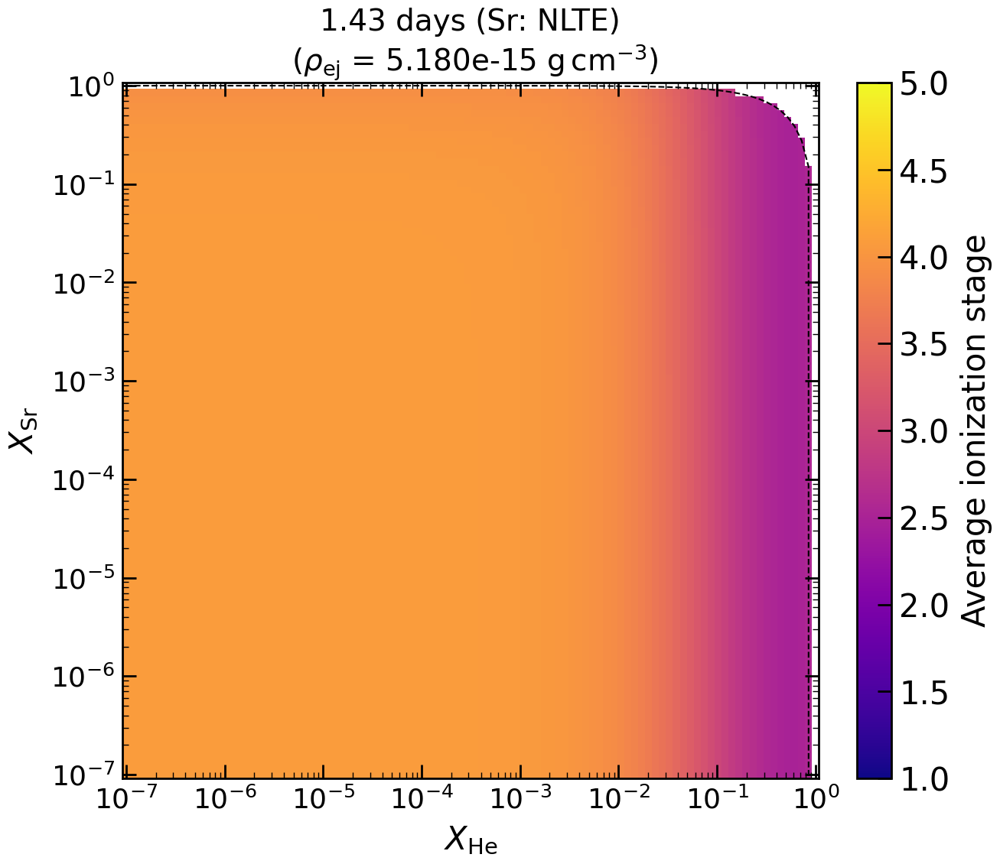

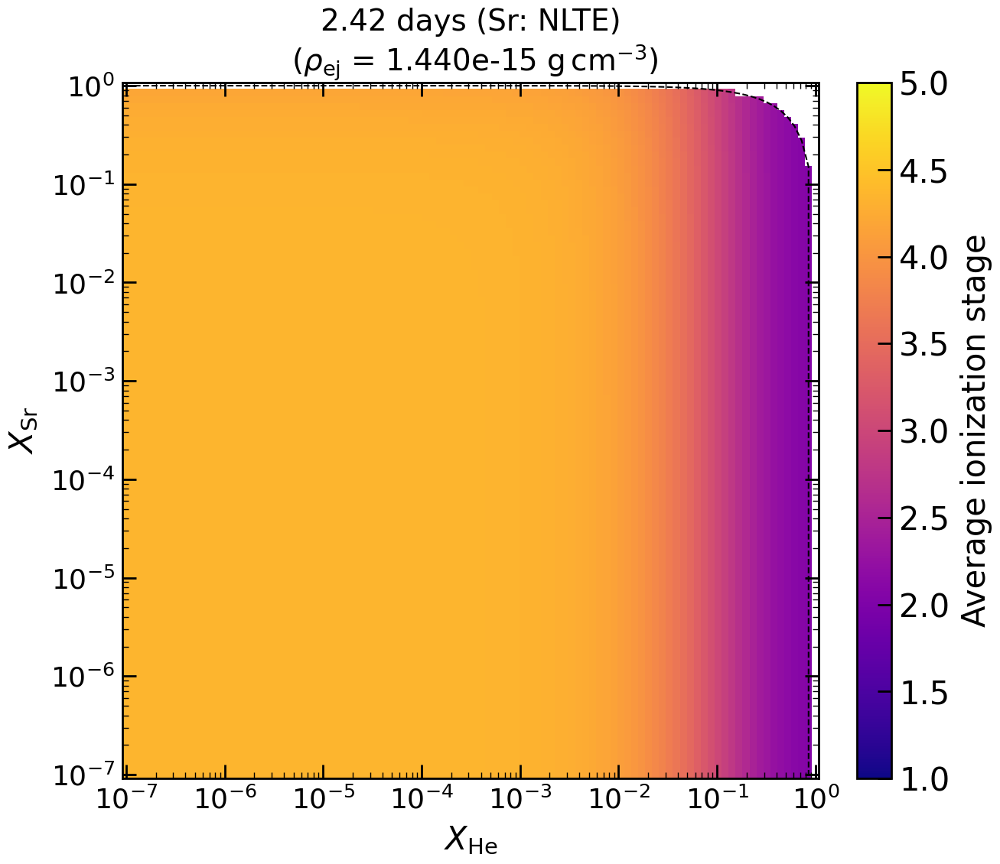

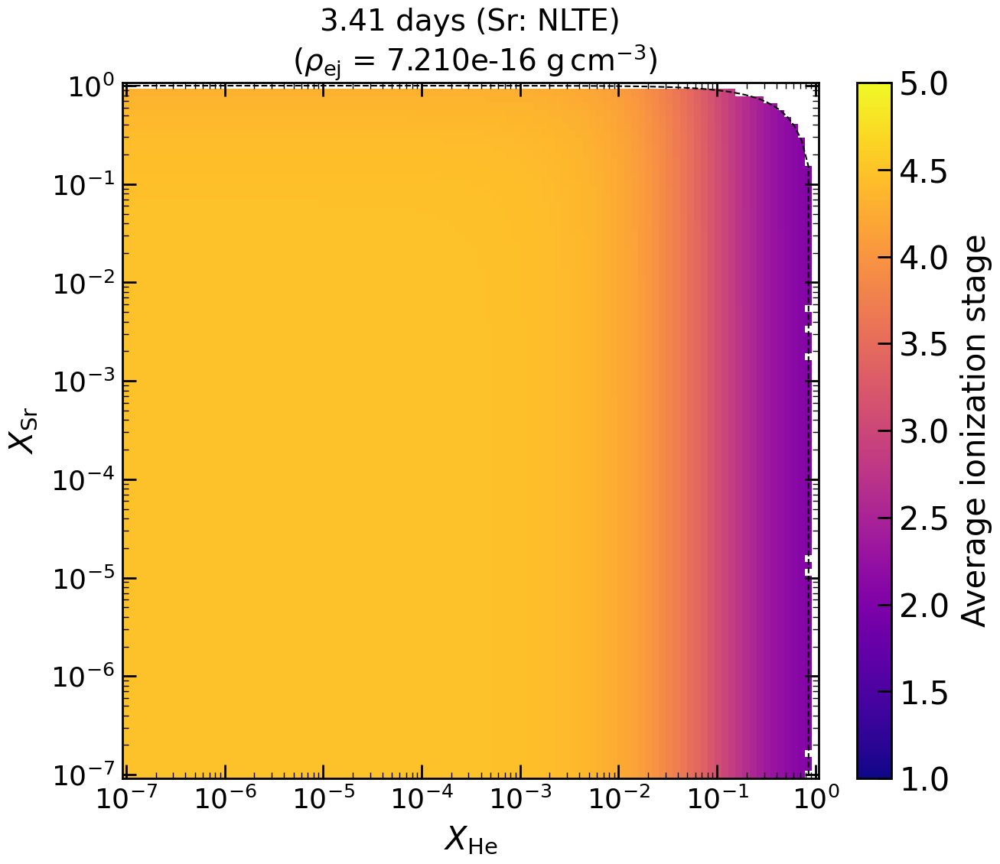

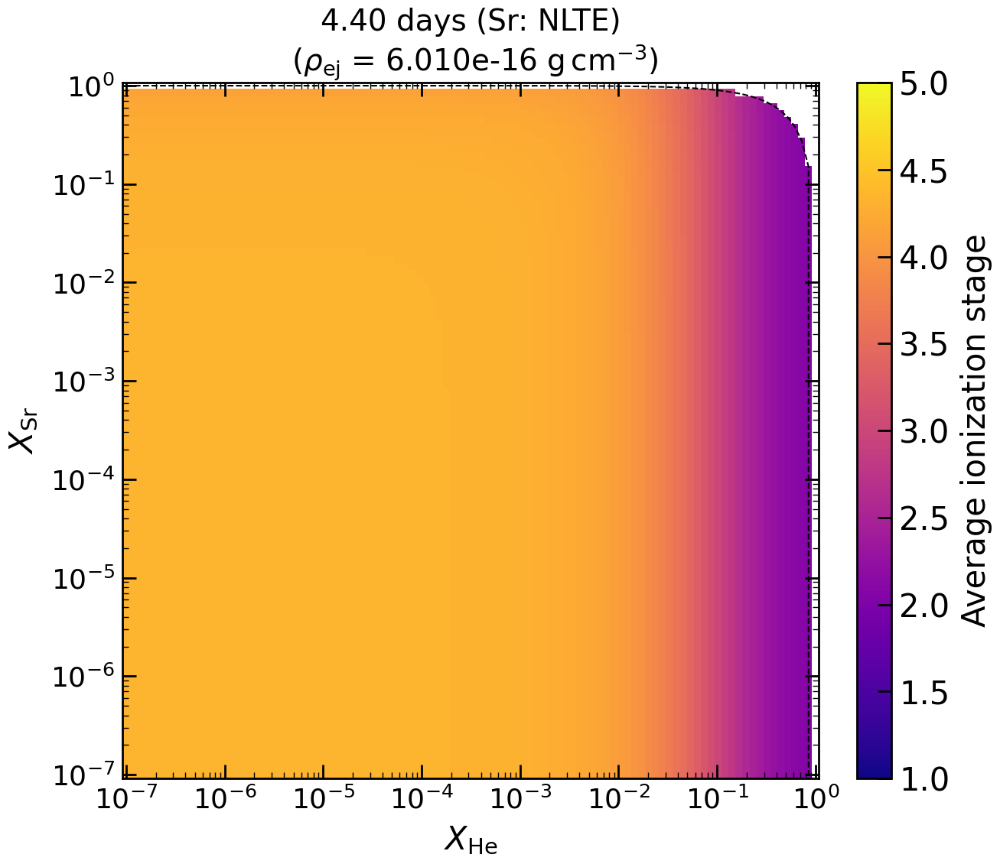

In [23]:
# energy of lower level, line wavelength, log gf
SrII_triplet_dict_v2 = {
    "4D3_2--5P3_2": (1.8047016, 10037.0, -1.22),
    "4D5_2--5P3_2": (1.8394593, 10327.0, -0.25),
    "4D3_2--5P1_2": (1.8047016, 10915.0, -0.574)
}

g_SrII_ground = 2
A_Sr = 88.0

for each_res in each_res_list_KC26_NLTE:    
    npz_dir = Path(res_dir_KC26, each_res)
    fpath_nd = Path(npz_dir, f"nd_{each_res}.npz")
    npz_nd = np.load(fpath_nd)

    X_He_seq: npt.NDArray[np.float64] = npz_nd["X_He_seq"]
    X_Sr_seq: npt.NDArray[np.float64] = npz_nd["X_Sr_seq"]
    t_expl_str = each_res.split('_')[0][:-1]
    t_expl = float(t_expl_str)*DAY
    rho_ej = float(each_res.split('_')[3][:-4])
    tem_e = float(each_res.split('_')[1][:-1])

    # for Sr
    nd_res_Sr_pop = ma.array(npz_nd["nd_res_Sr_pop"]["_data"], mask=npz_nd["nd_res_Sr_pop"]["_mask"])
    nd_res_Sr_tot = nd_res_Sr_pop.sum(axis=0)
    frac_res_Sr_pop = nd_res_Sr_pop / nd_res_Sr_tot

    ion_stage_seq = np.arange(frac_res_Sr_pop.shape[0]) + 1
    ion_degree = (ion_stage_seq[:, np.newaxis, np.newaxis] * frac_res_Sr_pop).sum(axis=0)

    fig, ax = plt.subplots(figsize=(14,12))

    ax.plot(X_He_seq, 1.0-X_He_seq, '--', c='k')

    mesh = ax.pcolormesh(X_He_seq, X_Sr_seq, ion_degree, cmap='plasma', vmin=1, vmax=5, rasterized=True)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"$X_\mathrm{He}$")
    ax.set_ylabel(r"$X_\mathrm{Sr}$")
    ax.set_title(f"{t_expl_str} days (Sr: NLTE)\n" + rf" ($\rho_\mathrm{{ej}}$ = {rho_ej:.3e} $\mathrm{{g\, cm^{{-3}}}}$)", fontsize=28)


    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.5)

    cbar = fig.colorbar(mesh, cax=cax)
    cbar.set_label("Average ionization stage")
    cbar.ax.tick_params(labelsize="medium")

    ax.set_aspect("equal")
    
    fig.tight_layout()
    plt.show()

# density profile

In [26]:
def get_rho(vel_c, t_expl_day, m_tot_msun, pf_idx = 3, vel_in_c = 0.05, vel_out_c = 0.35):
    r_out_in = vel_out_c/vel_in_c
    beta = pf_idx - 3

    term1 = 1/(4.0*np.pi*(vel_c*C*t_expl_day*DAY)**3)
    term2 = (vel_c/vel_in_c)**(-beta)

    if np.isclose(beta, 0.0):
        term3 = 1/np.log(r_out_in)
    else:
        term3 = beta/(1.0-(r_out_in)**(-beta))

    rho = term1 * term2 * term3 * m_tot_msun * M_SUN

    return rho

In [27]:
def plot_inferred_rho_t3(ax: plt.Axes, mode: str, var4get_rho: dict, exclude_first: bool = False):
    phase_seq = ["1.43", "2.42", "3.41", "4.40"]

    vel_ph_c_seq = []

    if (mode == "Sr_max-LTE"):
        rho_Sr_t3_center_seq = [] 
    else:
        rho_He_t3_lowest_seq = [] 
        rho_Sr_t3_lowest_seq = [] 
        rho_He_t3_lower_seq = [] 
        rho_Sr_t3_lower_seq = [] 
        rho_He_t3_upper_seq = [] 
        rho_Sr_t3_upper_seq = [] 

    for phase in phase_seq:
        _, _, vel_ph_c = fitting_info_KC26[phase]
        # ax.axvline(vel_ph_c, ls='-.', c=f'k', lw=3, alpha=0.6, zorder=1)

        rho_tot_t3 = get_rho(vel_ph_c, 1.0, **var4get_rho)


        fname = Path(f"coords-tau_tot-w_lu-clipped-{phase}d.npz")

        if (mode == "Sr_max-LTE"):
            # data loading ------------------------
            fpath = Path("coords-He_vs_Sr", "LTE", fname)
            npz = np.load(fpath)
            
            X_Sr_coords_center = npz["X_Sr_coords_center"]
            # -----------------------------

            # for tau=1
            X_Sr_center = X_Sr_coords_center.max()
            rho_Sr_t3_center = X_Sr_center * rho_tot_t3
            
            rho_Sr_t3_center_seq.append(rho_Sr_t3_center)

        else:
            # data loading ------------------------
            if mode == "LTE":
                fpath = Path("coords-He_vs_Sr", "LTE", fname)
            elif mode == "NLTE":
                fpath = Path("coords-He_vs_Sr", "NLTE", fname)

            npz = np.load(fpath)

            X_He_coords_lowest = npz["X_He_coords_lowest"]
            X_Sr_coords_lowest = npz["X_Sr_coords_lowest"]
            X_He_coords_lower = npz["X_He_coords_lower"]
            X_Sr_coords_lower = npz["X_Sr_coords_lower"]
            X_He_coords_upper = npz["X_He_coords_upper"]
            X_Sr_coords_upper = npz["X_Sr_coords_upper"]
            # -----------------------------

            # for tau=0.1
            X_He_lowest = X_He_coords_lowest.max()
            X_Sr_lowest = X_Sr_coords_lowest.max()
            rho_He_t3_lowest = X_He_lowest * rho_tot_t3
            rho_Sr_t3_lowest = X_Sr_lowest * rho_tot_t3
            
            # for tau=0.5
            X_He_lower = X_He_coords_lower.max()
            X_Sr_lower = X_Sr_coords_lower.max()
            rho_He_t3_lower = X_He_lower * rho_tot_t3
            rho_Sr_t3_lower = X_Sr_lower * rho_tot_t3

            # for tau=2
            X_He_upper = X_He_coords_upper.max()
            X_Sr_upper = X_Sr_coords_upper.max()
            rho_He_t3_upper = X_He_upper * rho_tot_t3
            rho_Sr_t3_upper = X_Sr_upper * rho_tot_t3
            
            rho_He_t3_lowest_seq.append(rho_He_t3_lowest)
            rho_Sr_t3_lowest_seq.append(rho_Sr_t3_lowest)
            rho_He_t3_lower_seq.append(rho_He_t3_lower)
            rho_Sr_t3_lower_seq.append(rho_Sr_t3_lower)
            rho_He_t3_upper_seq.append(rho_He_t3_upper)
            rho_Sr_t3_upper_seq.append(rho_Sr_t3_upper)

        vel_ph_c_seq.append(vel_ph_c)

    vel_ph_c_seq = np.array(vel_ph_c_seq)

    if (mode == "Sr_max-LTE"):
        rho_Sr_t3_center_seq = np.array(rho_Sr_t3_center_seq)
        line_Sr,  = ax.plot(vel_ph_c_seq, rho_Sr_t3_center_seq, c='b', lw=5)

        return line_Sr

    else:
        rho_He_t3_lowest_seq = np.array(rho_He_t3_lowest_seq)
        rho_Sr_t3_lowest_seq = np.array(rho_Sr_t3_lowest_seq)
        rho_He_t3_lower_seq = np.array(rho_He_t3_lower_seq)
        rho_Sr_t3_lower_seq = np.array(rho_Sr_t3_lower_seq)
        rho_He_t3_upper_seq = np.array(rho_He_t3_upper_seq)
        rho_Sr_t3_upper_seq = np.array(rho_Sr_t3_upper_seq)
       
        if exclude_first:
            line_He,  = ax.plot(vel_ph_c_seq, rho_He_t3_lowest_seq, '--', c='m', lw=5)            
            line_Sr,  = ax.plot(vel_ph_c_seq, rho_Sr_t3_lowest_seq, '--', c='c', lw=5)
            
            vel_ph_second_c = fitting_info_KC26[phase_seq[1]][2]
            area_He = ax.fill_between(vel_ph_c_seq, rho_He_t3_lower_seq, rho_He_t3_upper_seq,
                                      where=vel_ph_c_seq<=vel_ph_second_c, alpha=0.8, fc='m', ec='m')
            ax.fill_between(vel_ph_c_seq, rho_He_t3_lower_seq, rho_He_t3_upper_seq,
                            where=vel_ph_c_seq>=vel_ph_second_c, alpha=0.8, fc='none', ec='m', hatch='|')
            
            area_Sr = ax.fill_between(vel_ph_c_seq, rho_Sr_t3_lower_seq, rho_Sr_t3_upper_seq, 
                                      where=vel_ph_c_seq<=vel_ph_second_c, alpha=0.8, fc='c', ec='c', zorder=2)
            ax.fill_between(vel_ph_c_seq, rho_Sr_t3_lower_seq, rho_Sr_t3_upper_seq,
                            where=vel_ph_c_seq>=vel_ph_second_c, alpha=0.8, fc='none', ec='c', hatch='|', zorder=2)
        else:
            line_He,  = ax.plot(vel_ph_c_seq, rho_He_t3_lowest_seq, '--', c='m', lw=5)
            line_Sr,  = ax.plot(vel_ph_c_seq, rho_Sr_t3_lowest_seq, '--', c='c', lw=5, zorder=2)
            area_He = ax.fill_between(vel_ph_c_seq, rho_He_t3_lower_seq, rho_He_t3_upper_seq, alpha=0.8, fc='m')
            area_Sr = ax.fill_between(vel_ph_c_seq, rho_Sr_t3_lower_seq, rho_Sr_t3_upper_seq, alpha=0.8, fc='c', zorder=2)

        return line_He, line_Sr, area_He, area_Sr
    

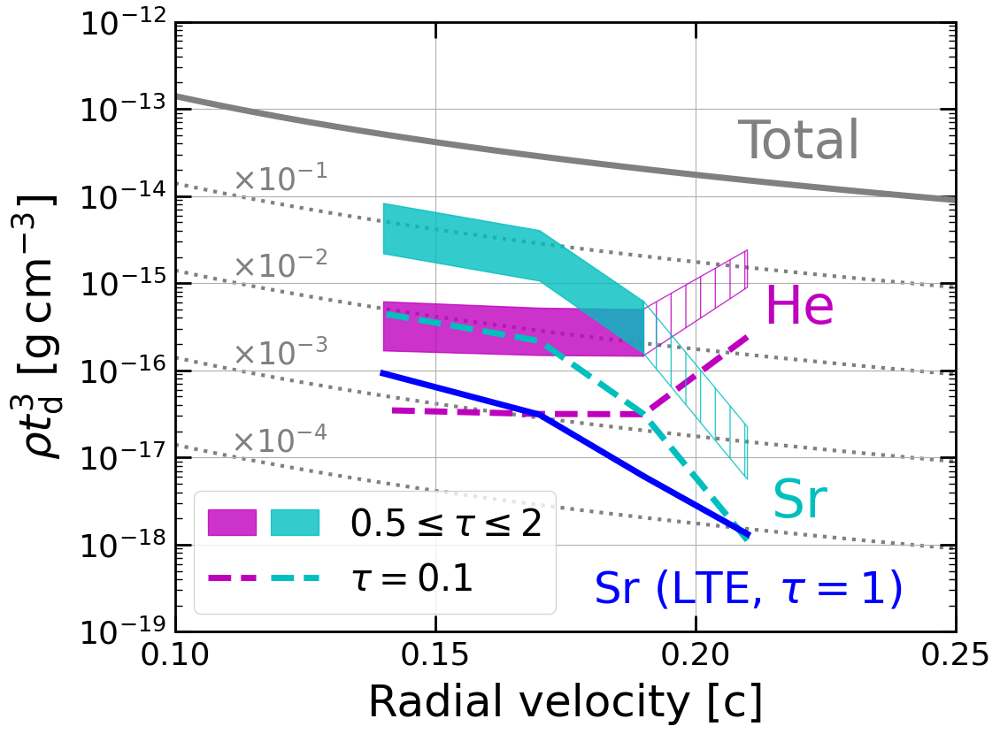

In [29]:
fig, ax = plt.subplots(figsize=(12, 9))

vrad_plot_seq = np.linspace(0.1, 0.35)
m_ej_tot = 0.03 # in Msun
var4get_rho = {"m_tot_msun":m_ej_tot}
rho_t3_tot = get_rho(vrad_plot_seq, 1.0, m_ej_tot)
ax.plot(vrad_plot_seq, rho_t3_tot, c='gray', lw=5)

for frac in [10**(-4+i) for i in range(4)]:
    ax.plot(vrad_plot_seq, frac*rho_t3_tot, ':', c='gray', lw=3, zorder=0)

mode = "NLTE"
line_He, line_Sr, area_He, area_Sr = plot_inferred_rho_t3(ax, mode, var4get_rho, True)
area_Sr_max_LTE = plot_inferred_rho_t3(ax, "Sr_max-LTE", var4get_rho)

ax.set_xticks([0.1, 0.15, 0.2, 0.25])

ax.set_yscale('log')
ax.set_xlim(0.1, 0.25)
ax.set_ylim(1e-19, 1e-12)
ax.set_xlabel("Radial velocity [c]", fontsize="large")
ax.set_ylabel(r"$\rho t_\mathrm{d}^3$ [$\mathrm{g\, cm^{-3}}$]", fontsize="large")
# ax.tick_params(labelsize="medium")

ax.annotate("Total", (0.22, 4e-14), ma='center', va='center', ha='center', c='gray', fontsize="x-large")
ax.annotate("He", (0.22, 5e-16), c='m', va='center', ha='center', fontsize="x-large")
ax.annotate("Sr", (0.22, 3e-18), c='c', va='center', ha='center', fontsize="x-large")
ax.annotate(r"Sr (LTE, $\tau=1$)", (0.21, 3e-19), c='b', va='center', ha='center', fontsize="large")

ax.annotate(r"$\times 10^{-1}$", (0.12, 1.5e-14), c='gray', va='center', ha='center', fontsize="small")
ax.annotate(r"$\times 10^{-2}$", (0.12, 1.5e-15), c='gray', va='center', ha='center', fontsize="small")
ax.annotate(r"$\times 10^{-3}$", (0.12, 1.5e-16), c='gray', va='center', ha='center', fontsize="small")
ax.annotate(r"$\times 10^{-4}$", (0.12, 1.5e-17), c='gray', va='center', ha='center', fontsize="small")

handles, labels = ax.get_legend_handles_labels()
handles.append((area_He, area_Sr))
handles.append((line_He, line_Sr))
labels.append(r"$0.5 \leq \tau \leq 2$")
labels.append(r"$\tau=0.1$")

ax.legend(handles, labels, handler_map={tuple: HandlerTuple(ndivide=None)}, loc=3, fontsize='medium', handlelength=3)

ax.grid()
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

# End